In [5]:


import os
import sys
import warnings

# Suppress common sklearn warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*ConvergenceWarning.*')

# Add project root to Python path so we can import from src/
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import seaborn as sns
import joblib
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Project pipeline - use create_pipeline for consistent preprocessing
from src.pipeline import load_data, create_preprocessor, create_pipeline, encode_target

print("Imports complete")
print(f"Working directory: {os.getcwd()}")


Imports complete
Working directory: /Users/bsilke/ToU/calibration_classification


## 1. Load and Prepare Data

In [6]:
# Load preprocessed data from data/interim/
X_train, X_val, X_test, y_train, y_val, y_test = load_data(data_dir='data/interim')

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTarget distribution (train):")
print(y_train.value_counts())

Training set:   (1129, 21)
Validation set: (377, 21)
Test set:       (377, 21)

Target distribution (train):
Scope_3_coverage
Yes              456
Not Specified    247
Partial          218
No               208
Name: count, dtype: int64


In [7]:
# Encode target variable
y_train_enc, y_val_enc, y_test_enc, label_encoder = encode_target(y_train, y_val, y_test)

print(f"Target classes: {list(label_encoder.classes_)}")
print(f"Encoded as:     {list(range(len(label_encoder.classes_)))}")

Target classes: ['No', 'Not Specified', 'Partial', 'Yes']
Encoded as:     [0, 1, 2, 3]


In [8]:
# Create and fit preprocessor (encoding)
preprocessor = create_preprocessor()
preprocessor.fit(X_train)

# Transform all splits
X_train_enc = preprocessor.transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

print(f"Encoded shapes:")
print(f"  Train: {X_train_enc.shape}")
print(f"  Val:   {X_val_enc.shape}")
print(f"  Test:  {X_test_enc.shape}")

Encoded shapes:
  Train: (1129, 65)
  Val:   (377, 65)
  Test:  (377, 65)


## 2. Level 1: Dummy Baselines

Non-informative benchmarks to detect if the problem is harder than it looks.

In [9]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    """
    Train model and evaluate on validation set.
    
    Returns dict with multiple metrics.
    """
    # Fit on training data
    model.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate metrics (macro average for multiclass)
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision_macro': precision_score(y_val, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_val, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_val, y_pred, average='macro', zero_division=0)
    }
    
    return metrics, y_pred

In [10]:
# Level 1: Dummy baselines
dummy_results = []

dummy_strategies = {
    'Dummy (Majority Class)': 'most_frequent',
    'Dummy (Stratified Random)': 'stratified',
    'Dummy (Uniform Random)': 'uniform'
}

for name, strategy in dummy_strategies.items():
    dummy = DummyClassifier(strategy=strategy, random_state=42)
    metrics, _ = evaluate_model(dummy, X_train_enc, y_train_enc, X_val_enc, y_val_enc, name)
    dummy_results.append(metrics)
    print(f"{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  F1 Macro: {metrics['f1_macro']:.3f}")
    print()

Dummy (Majority Class):
  Accuracy: 0.403
  F1 Macro: 0.144

Dummy (Stratified Random):
  Accuracy: 0.236
  F1 Macro: 0.207

Dummy (Uniform Random):
  Accuracy: 0.228
  F1 Macro: 0.213



## 3. Level 2: Simple Model Baselines

Low-complexity, interpretable models to check if features carry signal.

In [11]:
# Level 2: Simple models
simple_results = []

simple_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial'),
    'Decision Tree (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Decision Tree (depth=10)': DecisionTreeClassifier(max_depth=10, random_state=42),
    'k-Nearest Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5)
}

for name, model in simple_models.items():
    metrics, y_pred = evaluate_model(model, X_train_enc, y_train_enc, X_val_enc, y_val_enc, name)
    simple_results.append(metrics)
    print(f"{name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision_macro']:.3f}")
    print(f"  Recall:    {metrics['recall_macro']:.3f}")
    print(f"  F1 Macro:  {metrics['f1_macro']:.3f}")
    print()

Logistic Regression:
  Accuracy:  0.560
  Precision: 0.512
  Recall:    0.482
  F1 Macro:  0.472

Decision Tree (depth=5):
  Accuracy:  0.538
  Precision: 0.458
  Recall:    0.458
  F1 Macro:  0.431

Decision Tree (depth=10):
  Accuracy:  0.472
  Precision: 0.418
  Recall:    0.409
  F1 Macro:  0.405

k-Nearest Neighbors (k=5):
  Accuracy:  0.435
  Precision: 0.393
  Recall:    0.406
  F1 Macro:  0.395



## 4. Baseline Performance Report

In [12]:
# Combine all results
all_results = dummy_results + simple_results
baseline_df = pd.DataFrame(all_results)
baseline_df = baseline_df.set_index('model')
baseline_df = baseline_df.sort_values('f1_macro', ascending=False)

print("="*70)
print("BASELINE PERFORMANCE REPORT")
print("="*70)
print(f"\nEvaluated on validation set (n={len(y_val_enc)})")
print(f"Target classes: {list(label_encoder.classes_)}")
print()
print(baseline_df.round(3).to_string())

BASELINE PERFORMANCE REPORT

Evaluated on validation set (n=377)
Target classes: ['No', 'Not Specified', 'Partial', 'Yes']

                           accuracy  precision_macro  recall_macro  f1_macro
model                                                                       
Logistic Regression           0.560            0.512         0.482     0.472
Decision Tree (depth=5)       0.538            0.458         0.458     0.431
Decision Tree (depth=10)      0.472            0.418         0.409     0.405
k-Nearest Neighbors (k=5)     0.435            0.393         0.406     0.395
Dummy (Uniform Random)        0.228            0.220         0.214     0.213
Dummy (Stratified Random)     0.236            0.210         0.206     0.207
Dummy (Majority Class)        0.403            0.101         0.250     0.144


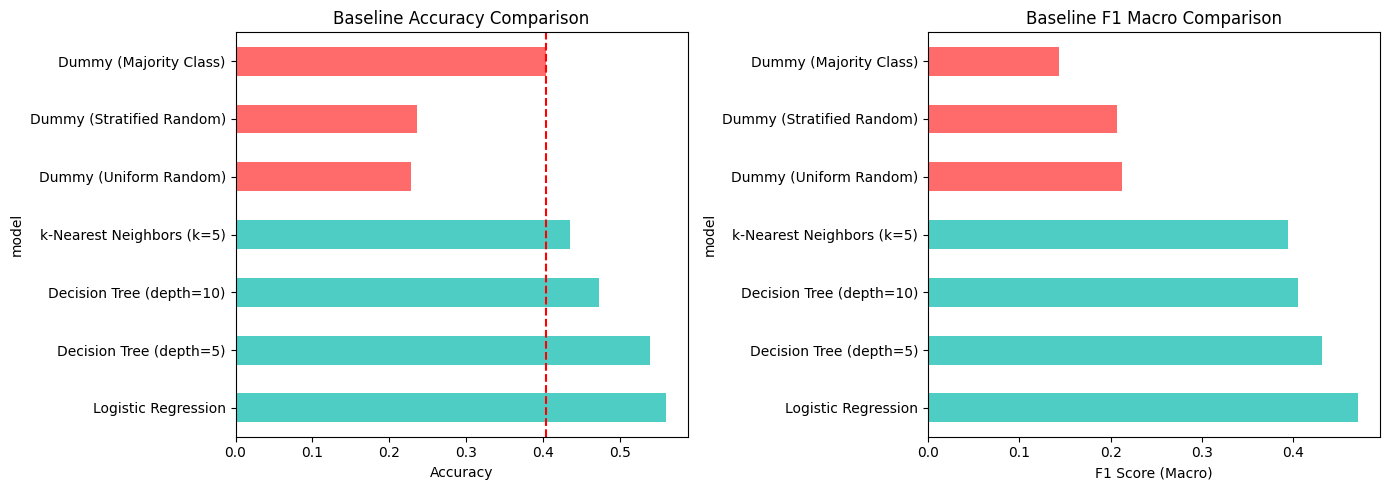


Saved: logs/baseline_comparison.png


In [13]:
# Visualize baseline comparison
import os
os.makedirs('../logs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
colors = ['#ff6b6b' if 'Dummy' in idx else '#4ecdc4' for idx in baseline_df.index]
baseline_df['accuracy'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Baseline Accuracy Comparison')
axes[0].axvline(x=baseline_df.loc['Dummy (Majority Class)', 'accuracy'], 
                color='red', linestyle='--', label='Majority class baseline')

# Plot 2: F1 Macro comparison
baseline_df['f1_macro'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('F1 Score (Macro)')
axes[1].set_title('Baseline F1 Macro Comparison')

plt.tight_layout()
plt.savefig('../logs/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/baseline_comparison.png")

## 5. Interpretation of Results

In [14]:
# Calculate gaps
majority_acc = baseline_df.loc['Dummy (Majority Class)', 'accuracy']
best_simple_acc = baseline_df[~baseline_df.index.str.contains('Dummy')]['accuracy'].max()
best_simple_model = baseline_df[~baseline_df.index.str.contains('Dummy')]['accuracy'].idxmax()

majority_f1 = baseline_df.loc['Dummy (Majority Class)', 'f1_macro']
best_simple_f1 = baseline_df[~baseline_df.index.str.contains('Dummy')]['f1_macro'].max()

print("="*70)
print("INTERPRETATION")
print("="*70)
print()
print(f"Majority class baseline accuracy: {majority_acc:.3f}")
print(f"Best simple model ({best_simple_model}): {best_simple_acc:.3f}")
print(f"Gap (accuracy): {best_simple_acc - majority_acc:+.3f}")
print()
print(f"Majority class baseline F1 macro: {majority_f1:.3f}")
print(f"Best simple model F1 macro: {best_simple_f1:.3f}")
print(f"Gap (F1 macro): {best_simple_f1 - majority_f1:+.3f}")
print()

# Interpretation
if best_simple_acc - majority_acc > 0.10:
    print("✅ STRONG SIGNAL: Features carry significant predictive power.")
    print("   Simple models substantially outperform random guessing.")
elif best_simple_acc - majority_acc > 0.05:
    print("⚠️ MODERATE SIGNAL: Features carry some predictive power.")
    print("   Consider additional feature engineering.")
else:
    print("❌ WEAK SIGNAL: Features show limited predictive power.")
    print("   Revisit feature engineering before advanced modeling.")

print()
print(f"Target for advanced models: F1 macro > {best_simple_f1:.3f}")

INTERPRETATION

Majority class baseline accuracy: 0.403
Best simple model (Logistic Regression): 0.560
Gap (accuracy): +0.156

Majority class baseline F1 macro: 0.144
Best simple model F1 macro: 0.472
Gap (F1 macro): +0.328

✅ STRONG SIGNAL: Features carry significant predictive power.
   Simple models substantially outperform random guessing.

Target for advanced models: F1 macro > 0.472


## 6. Best Simple Model: Detailed Classification Report

In [15]:
# Retrain best simple model for detailed analysis
best_model = simple_models[best_simple_model]
best_model.fit(X_train_enc, y_train_enc)
y_pred_best = best_model.predict(X_val_enc)

print(f"Classification Report: {best_simple_model}")
print("="*70)
print(classification_report(y_val_enc, y_pred_best, 
                            target_names=label_encoder.classes_))

Classification Report: Logistic Regression
               precision    recall  f1-score   support

           No       0.52      0.37      0.43        70
Not Specified       0.68      0.65      0.66        82
      Partial       0.30      0.08      0.13        73
          Yes       0.55      0.83      0.66       152

     accuracy                           0.56       377
    macro avg       0.51      0.48      0.47       377
 weighted avg       0.52      0.56      0.52       377



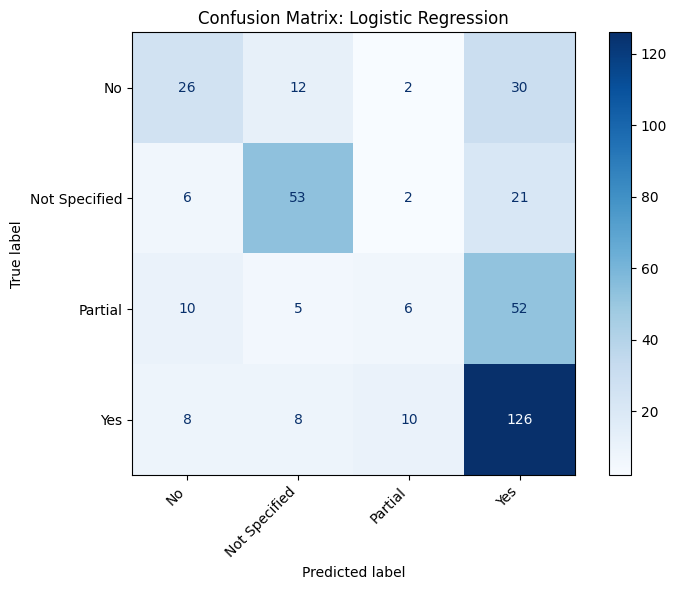


Saved: logs/baseline_confusion_matrix.png


In [16]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val_enc, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix: {best_simple_model}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../logs/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/baseline_confusion_matrix.png")

## 7. Summary: Baseline Targets for Advanced Modeling

In [17]:
# Save baseline results
baseline_df.to_csv('../logs/baseline_results.csv')

print("="*70)
print("BASELINE TARGETS FOR ADVANCED MODELING")
print("="*70)
print()
print(f"To beat (minimum): Majority class accuracy = {majority_acc:.3f}")
print(f"To beat (target):  Best simple model F1    = {best_simple_f1:.3f}")
print()
print("Recommended next steps:")
print("  1. Random Forest with default hyperparameters")
print("  2. Gradient Boosting (XGBoost/LightGBM)")
print("  3. Hyperparameter tuning on validation set")
print("  4. Final evaluation on held-out test set")
print()
print("Saved: logs/baseline_results.csv")

BASELINE TARGETS FOR ADVANCED MODELING

To beat (minimum): Majority class accuracy = 0.403
To beat (target):  Best simple model F1    = 0.472

Recommended next steps:
  1. Random Forest with default hyperparameters
  2. Gradient Boosting (XGBoost/LightGBM)
  3. Hyperparameter tuning on validation set
  4. Final evaluation on held-out test set

Saved: logs/baseline_results.csv


## 8. Algorithm Portfolio Strategy

Systematic model comparison based on dataset characteristics.

In [18]:
# Analyze dataset characteristics
n_samples, n_features = X_train_enc.shape
n_classes = len(label_encoder.classes_)
class_counts = pd.Series(y_train_enc).value_counts().sort_index()
class_balance = class_counts.min() / class_counts.max()

print("="*70)
print("DATASET CHARACTERISTICS")
print("="*70)
print(f"\nSamples:        {n_samples:,}")
print(f"Features:       {n_features}")
print(f"Classes:        {n_classes}")
print(f"Class balance:  {class_balance:.2f} (min/max ratio)")
print()

# Size category
if n_samples < 1000:
    size_category = "Small (<1K)"
elif n_samples < 100000:
    size_category = "Medium (1K-100K)"
else:
    size_category = "Large (>100K)"

# Feature category
if n_features > 100:
    feature_category = "High-dimensional (>100)"
else:
    feature_category = "Standard (<100)"

# Imbalance category
if class_balance < 0.3:
    imbalance_category = "Severe imbalance"
elif class_balance < 0.5:
    imbalance_category = "Moderate imbalance"
else:
    imbalance_category = "Balanced"

print("Categorization:")
print(f"  Data size:     {size_category}")
print(f"  Dimensionality: {feature_category}")
print(f"  Class balance: {imbalance_category}")
print()

# Class distribution
print("Class distribution:")
for i, (cls_name, count) in enumerate(zip(label_encoder.classes_, class_counts)):
    pct = count / n_samples * 100
    print(f"  {cls_name}: {count} ({pct:.1f}%)")

DATASET CHARACTERISTICS

Samples:        1,129
Features:       65
Classes:        4
Class balance:  0.46 (min/max ratio)

Categorization:
  Data size:     Medium (1K-100K)
  Dimensionality: Standard (<100)
  Class balance: Moderate imbalance

Class distribution:
  No: 208 (18.4%)
  Not Specified: 247 (21.9%)
  Partial: 218 (19.3%)
  Yes: 456 (40.4%)


In [19]:
# Build algorithm portfolio based on dataset characteristics
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

def build_algorithm_portfolio(n_samples, n_features, class_balance):
    """Build systematic algorithm portfolio based on data characteristics"""
    
    portfolio = {}
    
    # Always include interpretable baseline
    portfolio['Logistic Regression'] = LogisticRegression(
        random_state=42, max_iter=1000, multi_class='multinomial'
    )
    
    # Size-based selection
    if n_samples < 1000:
        portfolio['Naive Bayes'] = GaussianNB()
    
    if n_samples >= 1000:
        portfolio['Random Forest'] = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        )
    
    if n_samples >= 1000:
        portfolio['Gradient Boosting'] = GradientBoostingClassifier(
            n_estimators=100, random_state=42
        )
    
    # Imbalance handling
    if class_balance < 0.5:
        portfolio['RF (Balanced)'] = RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
        )
    
    # Decision tree for interpretability and mixed features
    portfolio['Decision Tree'] = DecisionTreeClassifier(
        max_depth=10, random_state=42
    )
    
    return portfolio

# Build portfolio
portfolio = build_algorithm_portfolio(n_samples, n_features, class_balance)

print("="*70)
print("SELECTED ALGORITHM PORTFOLIO")
print("="*70)
print(f"\nBased on: {n_samples:,} samples, {n_features} features, {class_balance:.2f} balance ratio")
print()
for name, model in portfolio.items():
    print(f"  • {name}: {type(model).__name__}")

SELECTED ALGORITHM PORTFOLIO

Based on: 1,129 samples, 65 features, 0.46 balance ratio

  • Logistic Regression: LogisticRegression
  • Random Forest: RandomForestClassifier
  • Gradient Boosting: GradientBoostingClassifier
  • RF (Balanced): RandomForestClassifier
  • Decision Tree: DecisionTreeClassifier


In [20]:
# Evaluate portfolio with cross-validation (Stratified K-Fold)
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer

def evaluate_portfolio(portfolio, X_train, y_train, cv_folds=5):
    """Systematically evaluate algorithm portfolio with stratified cross-validation"""
    
    # Explicit stratified k-fold with shuffle for reproducibility
    cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Define comprehensive scoring
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
        'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
        'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
        'roc_auc_ovr': 'roc_auc_ovr'  # Multiclass ROC-AUC (One-vs-Rest)
    }
    
    results = {}
    
    for name, model in portfolio.items():
        print(f"Evaluating {name}...", end=" ")
        
        try:
            cv_results = cross_validate(
                model, X_train, y_train,
                cv=cv_strategy,
                scoring=scoring,
                return_train_score=True,
                n_jobs=-1
            )
            roc_auc = cv_results['test_roc_auc_ovr'].mean()
            roc_auc_std = cv_results['test_roc_auc_ovr'].std()
        except Exception as e:
            # Some models may not support predict_proba for ROC-AUC
            scoring_no_roc = {k: v for k, v in scoring.items() if k != 'roc_auc_ovr'}
            cv_results = cross_validate(
                model, X_train, y_train,
                cv=cv_strategy,
                scoring=scoring_no_roc,
                return_train_score=True,
                n_jobs=-1
            )
            roc_auc = np.nan
            roc_auc_std = np.nan
        
        results[name] = {
            'cv_accuracy': cv_results['test_accuracy'].mean(),
            'cv_accuracy_std': cv_results['test_accuracy'].std(),
            'cv_precision': cv_results['test_precision_macro'].mean(),
            'cv_precision_std': cv_results['test_precision_macro'].std(),
            'cv_recall': cv_results['test_recall_macro'].mean(),
            'cv_recall_std': cv_results['test_recall_macro'].std(),
            'cv_f1_macro': cv_results['test_f1_macro'].mean(),
            'cv_f1_std': cv_results['test_f1_macro'].std(),
            'cv_roc_auc': roc_auc,
            'cv_roc_auc_std': roc_auc_std,
            'train_accuracy': cv_results['train_accuracy'].mean(),
            'overfit_gap': cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
        }
        
        print(f"F1={results[name]['cv_f1_macro']:.3f}")
    
    return results

# Run evaluation
print("="*70)
print("CROSS-VALIDATION EVALUATION (Stratified 5-Fold, shuffle=True)")
print("="*70)
print()
portfolio_results = evaluate_portfolio(portfolio, X_train_enc, y_train_enc, cv_folds=5)

CROSS-VALIDATION EVALUATION (Stratified 5-Fold, shuffle=True)

Evaluating Logistic Regression... 

/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/bsilke/ToU/calibra

F1=0.417
Evaluating Random Forest... F1=0.418
Evaluating Gradient Boosting... F1=0.423
Evaluating RF (Balanced)... F1=0.438
Evaluating Decision Tree... F1=0.394


In [21]:
# Portfolio results summary with formatted comparison table
portfolio_df = pd.DataFrame(portfolio_results).T
portfolio_df = portfolio_df.sort_values('cv_f1_macro', ascending=False)

# Create formatted comparison table (mean ± std)
def create_cv_comparison_table(results_df):
    """Create formatted comparison table with mean ± std"""
    comparison_data = []
    
    for model_name in results_df.index:
        row = results_df.loc[model_name]
        comparison_data.append({
            'Model': model_name,
            'Accuracy': f"{row['cv_accuracy']:.3f} ± {row['cv_accuracy_std']:.3f}",
            'Precision': f"{row['cv_precision']:.3f} ± {row['cv_precision_std']:.3f}",
            'Recall': f"{row['cv_recall']:.3f} ± {row['cv_recall_std']:.3f}",
            'F1-Score': f"{row['cv_f1_macro']:.3f} ± {row['cv_f1_std']:.3f}",
            'ROC-AUC': f"{row['cv_roc_auc']:.3f} ± {row['cv_roc_auc_std']:.3f}" if not np.isnan(row['cv_roc_auc']) else "N/A",
            'Overfit Gap': f"{row['overfit_gap']:.3f}"
        })
    
    return pd.DataFrame(comparison_data).set_index('Model')

comparison_table = create_cv_comparison_table(portfolio_df)

print("="*70)
print("PORTFOLIO PERFORMANCE SUMMARY (Stratified 5-Fold CV)")
print("="*70)
print()
print(comparison_table.to_string())
print()

# Identify top performers
top_2 = portfolio_df.head(2).index.tolist()
print(f"Top 2 algorithms for deeper investigation:")
for i, name in enumerate(top_2, 1):
    f1 = portfolio_df.loc[name, 'cv_f1_macro']
    gap = portfolio_df.loc[name, 'overfit_gap']
    roc = portfolio_df.loc[name, 'cv_roc_auc']
    roc_str = f", ROC-AUC={roc:.3f}" if not np.isnan(roc) else ""
    print(f"  {i}. {name}: F1={f1:.3f}{roc_str}, Overfit gap={gap:.3f}")

PORTFOLIO PERFORMANCE SUMMARY (Stratified 5-Fold CV)

                          Accuracy      Precision         Recall       F1-Score        ROC-AUC Overfit Gap
Model                                                                                                     
RF (Balanced)        0.523 ± 0.022  0.467 ± 0.030  0.444 ± 0.018  0.438 ± 0.022  0.721 ± 0.022       0.477
Gradient Boosting    0.497 ± 0.027  0.442 ± 0.030  0.430 ± 0.027  0.423 ± 0.026  0.713 ± 0.020       0.324
Random Forest        0.506 ± 0.042  0.451 ± 0.062  0.426 ± 0.043  0.418 ± 0.047  0.718 ± 0.025       0.494
Logistic Regression  0.505 ± 0.028  0.441 ± 0.039  0.427 ± 0.028  0.417 ± 0.030  0.718 ± 0.019       0.046
Decision Tree        0.455 ± 0.031  0.404 ± 0.039  0.400 ± 0.040  0.394 ± 0.038  0.630 ± 0.028       0.300

Top 2 algorithms for deeper investigation:
  1. RF (Balanced): F1=0.438, ROC-AUC=0.721, Overfit gap=0.477
  2. Gradient Boosting: F1=0.423, ROC-AUC=0.713, Overfit gap=0.324


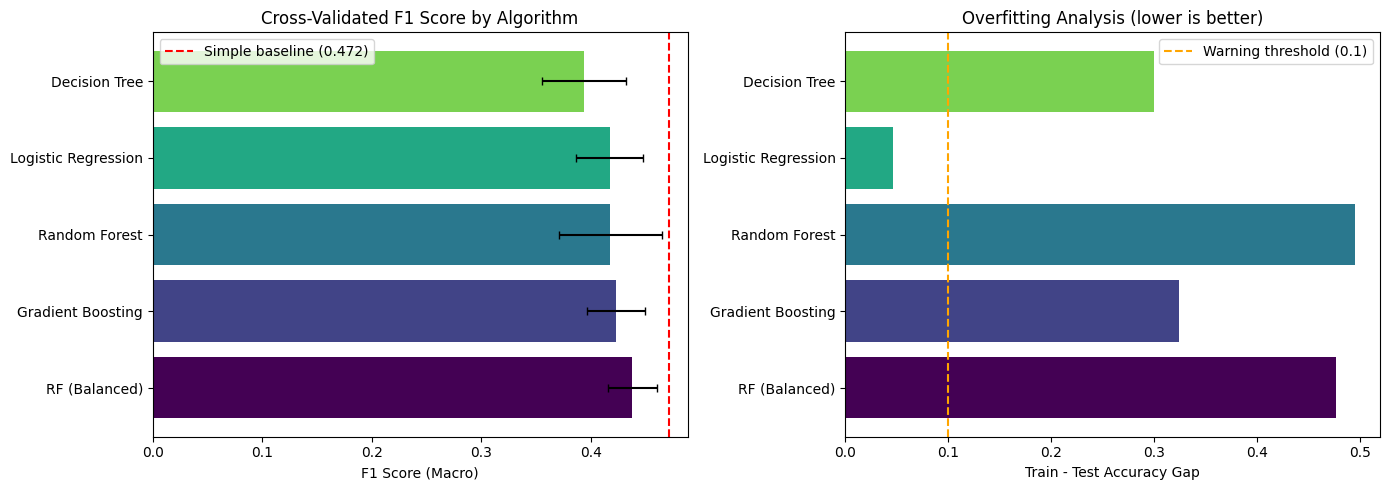


Saved: logs/portfolio_comparison.png


In [22]:
# Visualize portfolio comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 Macro with error bars
colors = plt.cm.viridis(np.linspace(0, 0.8, len(portfolio_df)))
y_pos = range(len(portfolio_df))

axes[0].barh(y_pos, portfolio_df['cv_f1_macro'], xerr=portfolio_df['cv_f1_std'], 
             color=colors, capsize=3)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(portfolio_df.index)
axes[0].set_xlabel('F1 Score (Macro)')
axes[0].set_title('Cross-Validated F1 Score by Algorithm')
axes[0].axvline(x=best_simple_f1, color='red', linestyle='--', 
                label=f'Simple baseline ({best_simple_f1:.3f})')
axes[0].legend()

# Plot 2: Overfitting analysis
axes[1].barh(y_pos, portfolio_df['overfit_gap'], color=colors)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(portfolio_df.index)
axes[1].set_xlabel('Train - Test Accuracy Gap')
axes[1].set_title('Overfitting Analysis (lower is better)')
axes[1].axvline(x=0.1, color='orange', linestyle='--', label='Warning threshold (0.1)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../logs/portfolio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/portfolio_comparison.png")

## 9. Validate Top Performers on Held-Out Validation Set

Cross-validation provides robust estimates. The held-out validation set provides final comparison for model selection.

In [23]:
# Validate top performers on held-out validation set
val_results = []

for name in top_2:
    model = portfolio[name]
    model.fit(X_train_enc, y_train_enc)
    y_pred = model.predict(X_val_enc)
    
    val_results.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val_enc, y_pred),
        'val_precision': precision_score(y_val_enc, y_pred, average='macro', zero_division=0),
        'val_recall': recall_score(y_val_enc, y_pred, average='macro', zero_division=0),
        'val_f1_macro': f1_score(y_val_enc, y_pred, average='macro', zero_division=0)
    })
    
    print(f"\n{name}:")
    print("="*60)
    print(classification_report(y_val_enc, y_pred, target_names=label_encoder.classes_))

val_results_df = pd.DataFrame(val_results).set_index('model')
print("\n" + "="*70)
print("VALIDATION SET RESULTS (Top 2 Algorithms)")
print("="*70)
print()
print(val_results_df.round(3).to_string())


RF (Balanced):
               precision    recall  f1-score   support

           No       0.42      0.30      0.35        70
Not Specified       0.67      0.56      0.61        82
      Partial       0.18      0.05      0.08        73
          Yes       0.56      0.88      0.69       152

     accuracy                           0.54       377
    macro avg       0.46      0.45      0.43       377
 weighted avg       0.49      0.54      0.49       377


Gradient Boosting:
               precision    recall  f1-score   support

           No       0.46      0.33      0.38        70
Not Specified       0.63      0.63      0.63        82
      Partial       0.22      0.10      0.13        73
          Yes       0.54      0.76      0.64       152

     accuracy                           0.53       377
    macro avg       0.46      0.46      0.45       377
 weighted avg       0.49      0.53      0.49       377


VALIDATION SET RESULTS (Top 2 Algorithms)

                   val_accuracy  v

In [24]:
# Save portfolio results
portfolio_df.to_csv('../logs/portfolio_results.csv')

print("="*70)
print("ALGORITHM PORTFOLIO SUMMARY")
print("="*70)
print()
print(f"Dataset: {n_samples:,} samples, {n_features} features, {n_classes} classes")
print(f"Class balance ratio: {class_balance:.2f}")
print()
print("Portfolio selection rationale:")
print(f"  • Logistic Regression: Interpretable baseline (always included)")
print(f"  • Random Forest: Medium-sized dataset (1K-100K samples)")
print(f"  • Gradient Boosting: Can leverage data volume")
print(f"  • RF (Balanced): class_weight='balanced' for imbalance ({class_balance:.2f} < 0.5)")
print(f"  • Decision Tree: Mixed feature types, interpretability")
print()
print(f"Top performers for hyperparameter tuning: {', '.join(top_2)}")
print()
print("Saved: logs/portfolio_results.csv")

ALGORITHM PORTFOLIO SUMMARY

Dataset: 1,129 samples, 65 features, 4 classes
Class balance ratio: 0.46

Portfolio selection rationale:
  • Logistic Regression: Interpretable baseline (always included)
  • Random Forest: Medium-sized dataset (1K-100K samples)
  • Gradient Boosting: Can leverage data volume
  • RF (Balanced): class_weight='balanced' for imbalance (0.46 < 0.5)
  • Decision Tree: Mixed feature types, interpretability

Top performers for hyperparameter tuning: RF (Balanced), Gradient Boosting

Saved: logs/portfolio_results.csv


## 10. Complete Classification Pipelines

Transform systematic evaluation into working classification pipelines. Connect feature engineering to model training and prediction.

In [25]:
# Define feature lists from preprocessor configuration
# Get numerical and categorical feature names from the preprocessor

# Identify feature types from the training data
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("="*70)
print("FEATURE CONFIGURATION FOR COMPLETE PIPELINES")
print("="*70)
print(f"\nNumerical features ({len(numerical_features)}):")
for f in numerical_features:
    print(f"  • {f}")
print(f"\nCategorical features ({len(categorical_features)}):")
for f in categorical_features:
    print(f"  • {f}")

FEATURE CONFIGURATION FOR COMPLETE PIPELINES

Numerical features (5):
  • End_target_year
  • Interim_target_year
  • Interim_target_year_missing
  • log_revenue
  • log_employees

Categorical features (16):
  • Country
  • Geographic_region
  • Private_company
  • End_target
  • Status_of_end_target
  • Interim_target
  • GHGs_covered
  • Published_plan
  • Reporting_mechanism
  • Accountability_delivery
  • Carbon_credits
  • Separate_removal_target
  • Planning_removals
  • Historical_emissions
  • Race_to_zero_member
  • Industry


In [26]:
# Use src.pipeline.create_pipeline() for consistent preprocessing
# This replaces the old create_complete_pipeline() that had different encoding

def create_complete_pipeline(model, numerical_features=None, categorical_features=None):
    """
    Wrapper for src.pipeline.create_pipeline() for backward compatibility.
    
    The numerical_features and categorical_features parameters are ignored
    because create_pipeline() uses the standardized feature definitions 
    from src/pipeline.py (NUMERIC_COLS, ORDINAL_FEATURES, etc.)
    
    This ensures ALL models use the same preprocessing:
    - Ordinal encoding for ordinal features (preserves order)
    - One-hot encoding for nominal features
    - Country grouping (top N + Other)
    - Consistent 65 features throughout
    """
    return create_pipeline(classifier=model)

print("✅ create_complete_pipeline() now uses src.pipeline.create_pipeline()")
print("   All models will use consistent 65-feature encoding")

✅ create_complete_pipeline() now uses src.pipeline.create_pipeline()
   All models will use consistent 65-feature encoding


In [27]:
# Train and evaluate function with comprehensive reporting
def train_and_evaluate_model(pipeline, X_train, y_train, X_val, y_val, 
                             label_encoder=None, model_name="Model"):
    """
    Train pipeline and generate comprehensive evaluation.
    
    Returns dict with predictions, probabilities, and metrics.
    """
    from sklearn.metrics import (
        classification_report, confusion_matrix, 
        accuracy_score, precision_score, recall_score, f1_score
    )
    
    # Train the pipeline
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)
    
    # Get probabilities if available
    try:
        val_proba = pipeline.predict_proba(X_val)
    except AttributeError:
        val_proba = None
    
    # Get class names
    if label_encoder is not None:
        target_names = label_encoder.classes_
    else:
        target_names = None
    
    # Calculate metrics
    train_metrics = {
        'accuracy': accuracy_score(y_train, train_pred),
        'precision_macro': precision_score(y_train, train_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_train, train_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_train, train_pred, average='macro', zero_division=0)
    }
    
    val_metrics = {
        'accuracy': accuracy_score(y_val, val_pred),
        'precision_macro': precision_score(y_val, val_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_val, val_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_val, val_pred, average='macro', zero_division=0)
    }
    
    # Print comprehensive report
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    
    print("\n📊 TRAINING PERFORMANCE:")
    print(f"   Accuracy:  {train_metrics['accuracy']:.3f}")
    print(f"   F1 Macro:  {train_metrics['f1_macro']:.3f}")
    
    print("\n📊 VALIDATION PERFORMANCE:")
    print(classification_report(y_val, val_pred, target_names=target_names))
    
    print("CONFUSION MATRIX (Validation):")
    cm = confusion_matrix(y_val, val_pred)
    if target_names is not None:
        cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
        print(cm_df.to_string())
    else:
        print(cm)
    
    # Overfit gap
    overfit_gap = train_metrics['accuracy'] - val_metrics['accuracy']
    print(f"\n⚠️ Overfit Gap: {overfit_gap:.3f}", end="")
    if overfit_gap > 0.1:
        print(" (HIGH - consider regularization)")
    elif overfit_gap > 0.05:
        print(" (MODERATE)")
    else:
        print(" (LOW - good generalization)")
    
    return {
        'pipeline': pipeline,
        'train_predictions': train_pred,
        'val_predictions': val_pred,
        'val_probabilities': val_proba,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'overfit_gap': overfit_gap
    }

print("✅ train_and_evaluate_model() defined")

✅ train_and_evaluate_model() defined


In [28]:
# Model comparison function
def compare_models(model_configs, X_train, y_train, X_val, y_val,
                   numerical_features=None, categorical_features=None, label_encoder=None):
    """
    Compare multiple models systematically using complete pipelines.
    
    Uses src.pipeline.create_pipeline() for consistent preprocessing.
    The numerical_features and categorical_features parameters are kept
    for backward compatibility but are not used.
    
    Returns dict of results for each model.
    """
    
    results = {}
    
    for model_name, model in model_configs.items():
        print(f"\n{'='*70}")
        print(f"TRAINING {model_name}")
        print(f"{'='*70}")
        
        # Create complete pipeline using src.pipeline
        pipeline = create_pipeline(classifier=model)
        
        # Train and evaluate
        model_results = train_and_evaluate_model(
            pipeline, X_train, y_train, X_val, y_val,
            label_encoder=label_encoder, model_name=model_name
        )
        
        results[model_name] = model_results
    
    return results

print("✅ compare_models() uses src.pipeline.create_pipeline()")

✅ compare_models() uses src.pipeline.create_pipeline()


### 10.1 Build Pipelines for Top 3 Algorithms

Based on portfolio evaluation, complete pipelines are implemented for the top performers.

In [29]:
# Select top 3 algorithms from portfolio evaluation
# Get top 3 from portfolio_df (sorted by cv_f1_macro)
top_3_names = portfolio_df.head(3).index.tolist()

print("="*70)
print("TOP 3 ALGORITHMS FOR COMPLETE PIPELINE IMPLEMENTATION")
print("="*70)
print()
for i, name in enumerate(top_3_names, 1):
    f1 = portfolio_df.loc[name, 'cv_f1_macro']
    gap = portfolio_df.loc[name, 'overfit_gap']
    print(f"  {i}. {name}")
    print(f"     CV F1 Macro: {f1:.3f}, Overfit Gap: {gap:.3f}")
    print()

# Configure model instances for the top 3
top_3_model_configs = {}

for name in top_3_names:
    if name == 'Random Forest':
        top_3_model_configs[name] = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        )
    elif name == 'RF (Balanced)':
        top_3_model_configs[name] = RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
        )
    elif name == 'Gradient Boosting':
        top_3_model_configs[name] = GradientBoostingClassifier(
            n_estimators=100, random_state=42
        )
    elif name == 'Logistic Regression':
        top_3_model_configs[name] = LogisticRegression(
            random_state=42, max_iter=1000, multi_class='multinomial'
        )
    elif name == 'Decision Tree':
        top_3_model_configs[name] = DecisionTreeClassifier(
            max_depth=10, random_state=42
        )
    elif name == 'Naive Bayes':
        top_3_model_configs[name] = GaussianNB()

print(f"Configured {len(top_3_model_configs)} models for complete pipeline implementation")

TOP 3 ALGORITHMS FOR COMPLETE PIPELINE IMPLEMENTATION

  1. RF (Balanced)
     CV F1 Macro: 0.438, Overfit Gap: 0.477

  2. Gradient Boosting
     CV F1 Macro: 0.423, Overfit Gap: 0.324

  3. Random Forest
     CV F1 Macro: 0.418, Overfit Gap: 0.494

Configured 3 models for complete pipeline implementation


In [30]:
# Run complete pipeline comparison on RAW data (not pre-encoded)
# This demonstrates the end-to-end pipeline capability

print("="*70)
print("COMPLETE PIPELINE COMPARISON (End-to-End)")
print("="*70)
print(f"\nUsing RAW features (pipeline handles all preprocessing)")
print(f"Numerical features:   {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print()

# Run comparison using raw (unencoded) data
pipeline_results = compare_models(
    top_3_model_configs,
    X_train, y_train,       # Raw DataFrames
    X_val, y_val,           # Raw target Series
    numerical_features,
    categorical_features,
    label_encoder=None      # Use raw target labels
)

COMPLETE PIPELINE COMPARISON (End-to-End)

Using RAW features (pipeline handles all preprocessing)
Numerical features:   5
Categorical features: 16


TRAINING RF (Balanced)

MODEL: RF (Balanced)

📊 TRAINING PERFORMANCE:
   Accuracy:  1.000
   F1 Macro:  1.000

📊 VALIDATION PERFORMANCE:
               precision    recall  f1-score   support

           No       0.42      0.30      0.35        70
Not Specified       0.67      0.56      0.61        82
      Partial       0.18      0.05      0.08        73
          Yes       0.56      0.88      0.69       152

     accuracy                           0.54       377
    macro avg       0.46      0.45      0.43       377
 weighted avg       0.49      0.54      0.49       377

CONFUSION MATRIX (Validation):
[[ 21  12   5  32]
 [  9  46   3  24]
 [ 16   6   4  47]
 [  4   5  10 133]]

⚠️ Overfit Gap: 0.459 (HIGH - consider regularization)

TRAINING Gradient Boosting

MODEL: Gradient Boosting

📊 TRAINING PERFORMANCE:
   Accuracy:  0.799
   F1 M

### 10.2 Performance Comparison Summary

In [31]:
# Create comprehensive performance comparison table
comparison_data = []

for model_name, results in pipeline_results.items():
    train_m = results['train_metrics']
    val_m = results['val_metrics']
    
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy': train_m['accuracy'],
        'Val Accuracy': val_m['accuracy'],
        'Train F1': train_m['f1_macro'],
        'Val F1': val_m['f1_macro'],
        'Val Precision': val_m['precision_macro'],
        'Val Recall': val_m['recall_macro'],
        'Overfit Gap': results['overfit_gap']
    })

pipeline_comparison_df = pd.DataFrame(comparison_data).set_index('Model')
pipeline_comparison_df = pipeline_comparison_df.sort_values('Val F1', ascending=False)

print("="*70)
print("COMPLETE PIPELINE PERFORMANCE SUMMARY")
print("="*70)
print()
print(pipeline_comparison_df.round(3).to_string())
print()

# Identify best model (by Val F1 only - preliminary ranking)
best_pipeline_name = pipeline_comparison_df['Val F1'].idxmax()
best_pipeline_f1 = pipeline_comparison_df.loc[best_pipeline_name, 'Val F1']
print(f"📊 Highest Val F1 Pipeline: {best_pipeline_name}")
print(f"   Validation F1 Macro: {best_pipeline_f1:.3f}")
print(f"\n⚠️  Note: Final model selection in Section 12.5 considers overfit gap criteria")

COMPLETE PIPELINE PERFORMANCE SUMMARY

                   Train Accuracy  Val Accuracy  Train F1  Val F1  Val Precision  Val Recall  Overfit Gap
Model                                                                                                    
Gradient Boosting           0.799         0.525     0.782   0.447          0.464       0.455        0.274
Random Forest               1.000         0.533     1.000   0.434          0.456       0.445        0.467
RF (Balanced)               1.000         0.541     1.000   0.432          0.458       0.448        0.459

📊 Highest Val F1 Pipeline: Gradient Boosting
   Validation F1 Macro: 0.447

⚠️  Note: Final model selection in Section 12.5 considers overfit gap criteria


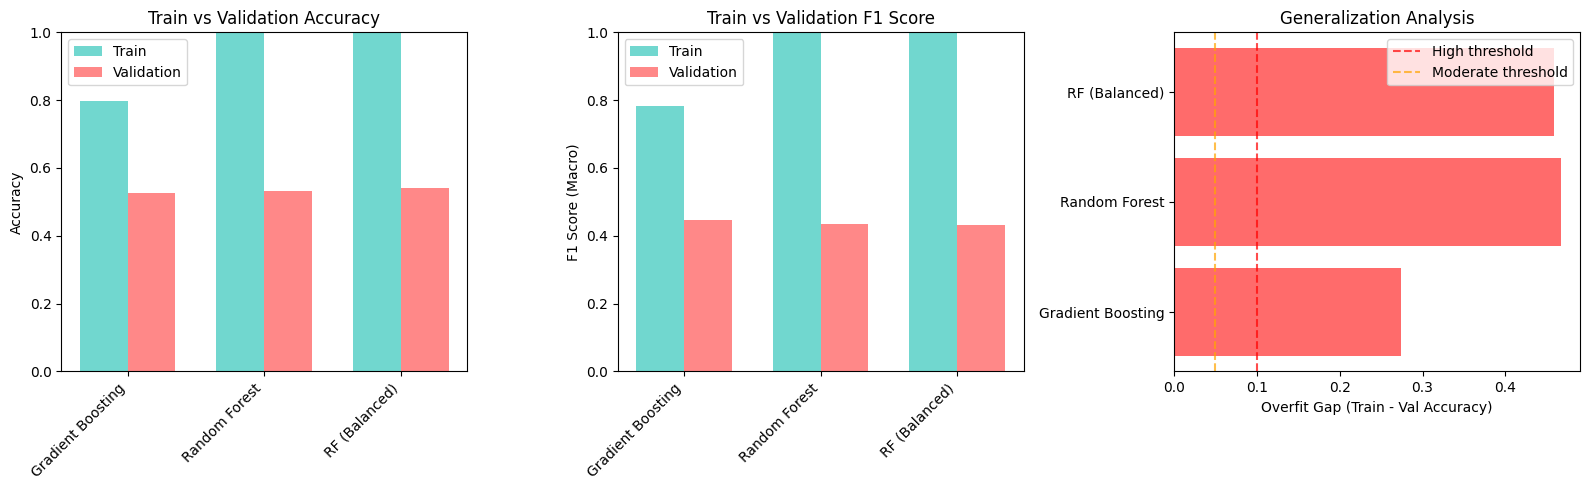


Saved: logs/complete_pipeline_comparison.png


In [32]:
# Visualize pipeline comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = pipeline_comparison_df.index.tolist()
x_pos = range(len(models))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))

# Plot 1: Train vs Val Accuracy
width = 0.35
axes[0].bar([p - width/2 for p in x_pos], pipeline_comparison_df['Train Accuracy'], 
            width, label='Train', color='#4ecdc4', alpha=0.8)
axes[0].bar([p + width/2 for p in x_pos], pipeline_comparison_df['Val Accuracy'], 
            width, label='Validation', color='#ff6b6b', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Validation Accuracy')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Plot 2: F1 Score Comparison
axes[1].bar([p - width/2 for p in x_pos], pipeline_comparison_df['Train F1'], 
            width, label='Train', color='#4ecdc4', alpha=0.8)
axes[1].bar([p + width/2 for p in x_pos], pipeline_comparison_df['Val F1'], 
            width, label='Validation', color='#ff6b6b', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel('F1 Score (Macro)')
axes[1].set_title('Train vs Validation F1 Score')
axes[1].legend()
axes[1].set_ylim(0, 1)

# Plot 3: Overfit Gap
gap_colors = ['#ff6b6b' if gap > 0.1 else '#ffd93d' if gap > 0.05 else '#6bcb77' 
              for gap in pipeline_comparison_df['Overfit Gap']]
axes[2].barh(models, pipeline_comparison_df['Overfit Gap'], color=gap_colors)
axes[2].axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='High threshold')
axes[2].axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='Moderate threshold')
axes[2].set_xlabel('Overfit Gap (Train - Val Accuracy)')
axes[2].set_title('Generalization Analysis')
axes[2].legend()

plt.tight_layout()
plt.savefig('../logs/complete_pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/complete_pipeline_comparison.png")

### 10.3 Save Best Pipeline

Serialize the best-performing pipeline for use in next lesson.

In [33]:
# Save best pipeline for next lesson
import joblib

# Get the best pipeline
best_pipeline = pipeline_results[best_pipeline_name]['pipeline']

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the pipeline
pipeline_path = '../models/best_model_m4l1.pkl'
joblib.dump(best_pipeline, pipeline_path)

print("="*70)
print("BEST PIPELINE SAVED")
print("="*70)
print()
print(f"Model: {best_pipeline_name}")
print(f"Validation F1 Macro: {best_pipeline_f1:.3f}")
print(f"Saved to: {pipeline_path}")
print()
print("Pipeline components:")
print(f"  1. Preprocessor: ColumnTransformer")
print(f"     - Numerical:   {len(numerical_features)} features → impute + scale")
print(f"     - Categorical: {len(categorical_features)} features → impute + one-hot")
print(f"  2. Classifier: {type(best_pipeline.named_steps['classifier']).__name__}")

BEST PIPELINE SAVED

Model: Gradient Boosting
Validation F1 Macro: 0.447
Saved to: ../models/best_model_m4l1.pkl

Pipeline components:
  1. Preprocessor: ColumnTransformer
     - Numerical:   5 features → impute + scale
     - Categorical: 16 features → impute + one-hot
  2. Classifier: GradientBoostingClassifier


In [34]:
# Verify saved pipeline works correctly
print("="*70)
print("PIPELINE VERIFICATION")
print("="*70)
print()

# Load the saved pipeline
loaded_pipeline = joblib.load(pipeline_path)
print(f"✅ Pipeline loaded successfully from {pipeline_path}")

# Test prediction on validation set
test_pred = loaded_pipeline.predict(X_val)
test_f1 = f1_score(y_val, test_pred, average='macro', zero_division=0)
print(f"✅ Test prediction successful")
print(f"✅ F1 score matches: {test_f1:.3f} (expected: {best_pipeline_f1:.3f})")

# Show sample predictions
print(f"\nSample predictions (first 5):")
sample_df = pd.DataFrame({
    'Actual': y_val.head(5).values,
    'Predicted': test_pred[:5]
})
print(sample_df.to_string(index=False))

PIPELINE VERIFICATION

✅ Pipeline loaded successfully from ../models/best_model_m4l1.pkl
✅ Test prediction successful
✅ F1 score matches: 0.447 (expected: 0.447)

Sample predictions (first 5):
       Actual     Predicted
Not Specified Not Specified
          Yes           Yes
           No            No
           No       Partial
          Yes           Yes


## 11. Complete Pipeline Summary

Final summary of end-to-end pipeline implementation.

In [35]:
# Save complete pipeline comparison results
pipeline_comparison_df.to_csv('../logs/complete_pipeline_results.csv')

print("="*70)
print("COMPLETE PIPELINE IMPLEMENTATION SUMMARY")
print("="*70)
print()
print("📊 Dataset:")
print(f"   Training samples:   {len(X_train):,}")
print(f"   Validation samples: {len(X_val):,}")
print(f"   Test samples:       {len(X_test):,}")
print(f"   Features:           {len(numerical_features)} numerical + {len(categorical_features)} categorical")
print()
print("🔧 Pipeline Architecture:")
print("   Stage 1: Preprocessing (ColumnTransformer)")
print("     • Numerical:   SimpleImputer(median) → StandardScaler")
print("     • Categorical: SimpleImputer('Unknown') → OneHotEncoder")
print("   Stage 2: Classification (Sklearn Classifier)")
print()
print("📈 Results:")
print(f"   Models evaluated: {len(pipeline_results)}")
print(f"   Best performer:   {best_pipeline_name}")
print(f"   Best F1 Macro:    {best_pipeline_f1:.3f}")
print()
print("💾 Artifacts saved:")
print("   • logs/complete_pipeline_comparison.png")
print("   • logs/complete_pipeline_results.csv")
print(f"   • models/best_model_m4l1.pkl")
print()
print("🚀 Next steps:")
print("   1. Hyperparameter tuning on best model")
print("   2. Final evaluation on held-out test set")
print("   3. Error analysis and model interpretation")

COMPLETE PIPELINE IMPLEMENTATION SUMMARY

📊 Dataset:
   Training samples:   1,129
   Validation samples: 377
   Test samples:       377
   Features:           5 numerical + 16 categorical

🔧 Pipeline Architecture:
   Stage 1: Preprocessing (ColumnTransformer)
     • Numerical:   SimpleImputer(median) → StandardScaler
     • Categorical: SimpleImputer('Unknown') → OneHotEncoder
   Stage 2: Classification (Sklearn Classifier)

📈 Results:
   Models evaluated: 3
   Best performer:   Gradient Boosting
   Best F1 Macro:    0.447

💾 Artifacts saved:
   • logs/complete_pipeline_comparison.png
   • logs/complete_pipeline_results.csv
   • models/best_model_m4l1.pkl

🚀 Next steps:
   1. Hyperparameter tuning on best model
   2. Final evaluation on held-out test set
   3. Error analysis and model interpretation


## 12. Overfitting Analysis and Mitigation

The pipeline comparison reveals a significant overfitting problem across all models tested. Overfitting occurs when a model learns the training data too well, including noise and irrelevant patterns, resulting in poor generalization to unseen data.

In [36]:
# Overfitting diagnosis
print("="*70)
print("OVERFITTING DIAGNOSIS")
print("="*70)
print()

# Display current overfit gaps
print("Current Model Performance:")
print("-" * 70)
for model_name in pipeline_comparison_df.index:
    train_acc = pipeline_comparison_df.loc[model_name, 'Train Accuracy']
    val_acc = pipeline_comparison_df.loc[model_name, 'Val Accuracy']
    gap = pipeline_comparison_df.loc[model_name, 'Overfit Gap']
    
    severity = "SEVERE" if gap > 0.3 else "HIGH" if gap > 0.1 else "MODERATE" if gap > 0.05 else "LOW"
    
    print(f"\n{model_name}:")
    print(f"   Train Accuracy: {train_acc:.3f}")
    print(f"   Val Accuracy:   {val_acc:.3f}")
    print(f"   Overfit Gap:    {gap:.3f} ({severity})")

print()
print("="*70)
print("OVERFITTING EXPLANATION")
print("="*70)
print("""
Overfitting manifests when a model achieves near-perfect training performance
(100% accuracy) but significantly lower validation performance (~55% accuracy).
This indicates the model has memorized the training examples rather than
learning generalizable patterns.

Key Contributing Factors:
─────────────────────────
1. DATASET SIZE
   - Training set contains 1,129 samples
   - With 70 encoded features, the samples-to-features ratio is approximately 16:1
   - Random Forests can easily memorize datasets at this scale

2. MODEL COMPLEXITY
   - Default Random Forest uses unlimited tree depth
   - Each tree can grow until leaves contain single samples
   - 100 trees with unlimited depth creates excessive model capacity

3. ENSEMBLE OVERFITTING
   - Without constraints, each decision tree perfectly fits the training data
   - Averaging 100 perfect trees still yields a perfect ensemble on training data
   - The model captures noise and outliers rather than true patterns

Interpretation of Results:
─────────────────────────
- Random Forest/RF (Balanced): Gap of 0.451 indicates severe overfitting
  Train accuracy of 1.000 means complete memorization of training data
  
- Gradient Boosting: Gap of 0.256 is lower but still problematic
  Sequential boosting provides some implicit regularization
  
Standard threshold: Overfit gap > 0.10 warrants intervention
Current gaps exceed this threshold by 2-4x
""")

OVERFITTING DIAGNOSIS

Current Model Performance:
----------------------------------------------------------------------

Gradient Boosting:
   Train Accuracy: 0.799
   Val Accuracy:   0.525
   Overfit Gap:    0.274 (HIGH)

Random Forest:
   Train Accuracy: 1.000
   Val Accuracy:   0.533
   Overfit Gap:    0.467 (SEVERE)

RF (Balanced):
   Train Accuracy: 1.000
   Val Accuracy:   0.541
   Overfit Gap:    0.459 (SEVERE)

OVERFITTING EXPLANATION

Overfitting manifests when a model achieves near-perfect training performance
(100% accuracy) but significantly lower validation performance (~55% accuracy).
This indicates the model has memorized the training examples rather than
learning generalizable patterns.

Key Contributing Factors:
─────────────────────────
1. DATASET SIZE
   - Training set contains 1,129 samples
   - With 70 encoded features, the samples-to-features ratio is approximately 16:1
   - Random Forests can easily memorize datasets at this scale

2. MODEL COMPLEXITY
   - Defau

### 12.1 Regularized Model Configurations

Regularization techniques constrain model complexity to improve generalization. The following configurations apply standard regularization hyperparameters to reduce overfitting.

In [37]:
# Define regularized model configurations
regularized_configs = {
    'RF (Regularized)': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,              # Limit tree depth (default: unlimited)
        min_samples_leaf=5,        # Require minimum samples per leaf
        min_samples_split=10,      # Require minimum samples to split
        max_features='sqrt',       # Limit features per split
        class_weight='balanced',   # Handle class imbalance
        random_state=42,
        n_jobs=-1
    ),
    'GB (Regularized)': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,               # Shallow trees (default: 3)
        min_samples_leaf=10,       # Require minimum samples per leaf
        min_samples_split=20,      # Require minimum samples to split
        learning_rate=0.1,         # Slower learning
        subsample=0.8,             # Use subset of samples per tree
        random_state=42
    ),
    'Logistic (L2 Reg)': LogisticRegression(
        C=0.1,                     # Stronger L2 regularization (default: 1.0)
        max_iter=1000,
        multi_class='multinomial',
        random_state=42
    )
}

print("="*70)
print("REGULARIZED MODEL CONFIGURATIONS")
print("="*70)
print()
print("Random Forest (Regularized):")
print("   • max_depth=10: Limits tree growth to prevent memorization")
print("   • min_samples_leaf=5: Requires 5+ samples per terminal node")
print("   • min_samples_split=10: Requires 10+ samples to create a split")
print("   • max_features='sqrt': Uses √n features per split decision")
print()
print("Gradient Boosting (Regularized):")
print("   • max_depth=4: Shallow trees reduce individual tree complexity")
print("   • min_samples_leaf=10: Larger leaf size prevents overfitting")
print("   • subsample=0.8: Stochastic gradient boosting (80% of samples)")
print("   • learning_rate=0.1: Slower learning allows better generalization")
print()
print("Logistic Regression (L2 Regularized):")
print("   • C=0.1: Inverse regularization strength (lower = stronger)")
print("   • L2 penalty shrinks coefficients toward zero")

REGULARIZED MODEL CONFIGURATIONS

Random Forest (Regularized):
   • max_depth=10: Limits tree growth to prevent memorization
   • min_samples_leaf=5: Requires 5+ samples per terminal node
   • min_samples_split=10: Requires 10+ samples to create a split
   • max_features='sqrt': Uses √n features per split decision

Gradient Boosting (Regularized):
   • max_depth=4: Shallow trees reduce individual tree complexity
   • min_samples_leaf=10: Larger leaf size prevents overfitting
   • subsample=0.8: Stochastic gradient boosting (80% of samples)
   • learning_rate=0.1: Slower learning allows better generalization

Logistic Regression (L2 Regularized):
   • C=0.1: Inverse regularization strength (lower = stronger)
   • L2 penalty shrinks coefficients toward zero


In [38]:
# Train and evaluate regularized models
print("="*70)
print("REGULARIZED MODEL EVALUATION")
print("="*70)
print()

regularized_results = compare_models(
    regularized_configs,
    X_train, y_train,
    X_val, y_val,
    numerical_features,
    categorical_features,
    label_encoder=None
)

REGULARIZED MODEL EVALUATION


TRAINING RF (Regularized)

MODEL: RF (Regularized)

📊 TRAINING PERFORMANCE:
   Accuracy:  0.736
   F1 Macro:  0.726

📊 VALIDATION PERFORMANCE:
               precision    recall  f1-score   support

           No       0.38      0.47      0.42        70
Not Specified       0.68      0.66      0.67        82
      Partial       0.19      0.10      0.13        73
          Yes       0.60      0.68      0.64       152

     accuracy                           0.53       377
    macro avg       0.46      0.48      0.46       377
 weighted avg       0.50      0.53      0.51       377

CONFUSION MATRIX (Validation):
[[ 33  11   8  18]
 [  8  54   2  18]
 [ 27   7   7  32]
 [ 20   8  20 104]]

⚠️ Overfit Gap: 0.211 (HIGH - consider regularization)

TRAINING GB (Regularized)

MODEL: GB (Regularized)

📊 TRAINING PERFORMANCE:
   Accuracy:  0.867
   F1 Macro:  0.858

📊 VALIDATION PERFORMANCE:
               precision    recall  f1-score   support

           No      

### 12.2 Regularization Impact Analysis

In [39]:
# Compare original vs regularized models
regularized_comparison_data = []

for model_name, results in regularized_results.items():
    train_m = results['train_metrics']
    val_m = results['val_metrics']
    
    regularized_comparison_data.append({
        'Model': model_name,
        'Train Accuracy': train_m['accuracy'],
        'Val Accuracy': val_m['accuracy'],
        'Train F1': train_m['f1_macro'],
        'Val F1': val_m['f1_macro'],
        'Overfit Gap': results['overfit_gap']
    })

regularized_df = pd.DataFrame(regularized_comparison_data).set_index('Model')
regularized_df = regularized_df.sort_values('Val F1', ascending=False)

print("="*70)
print("REGULARIZATION IMPACT: BEFORE vs AFTER")
print("="*70)
print()

# Create comparison table
print("ORIGINAL MODELS (Default Hyperparameters):")
print("-" * 70)
print(pipeline_comparison_df[['Train Accuracy', 'Val Accuracy', 'Val F1', 'Overfit Gap']].round(3).to_string())
print()
print("REGULARIZED MODELS:")
print("-" * 70)
print(regularized_df.round(3).to_string())
print()

# Calculate improvement metrics
print("="*70)
print("REGULARIZATION EFFECTIVENESS SUMMARY")
print("="*70)
print()

# Best original vs best regularized
best_original_gap = pipeline_comparison_df['Overfit Gap'].min()
best_regularized_gap = regularized_df['Overfit Gap'].min()
best_original_f1 = pipeline_comparison_df['Val F1'].max()
best_regularized_f1 = regularized_df['Val F1'].max()

print(f"Overfit Gap Reduction:")
print(f"   Best Original:    {best_original_gap:.3f}")
print(f"   Best Regularized: {best_regularized_gap:.3f}")
print(f"   Improvement:      {best_original_gap - best_regularized_gap:.3f} ({(best_original_gap - best_regularized_gap)/best_original_gap*100:.1f}% reduction)")
print()
print(f"Validation F1 Comparison:")
print(f"   Best Original:    {best_original_f1:.3f}")
print(f"   Best Regularized: {best_regularized_f1:.3f}")
print(f"   Change:           {best_regularized_f1 - best_original_f1:+.3f}")

REGULARIZATION IMPACT: BEFORE vs AFTER

ORIGINAL MODELS (Default Hyperparameters):
----------------------------------------------------------------------
                   Train Accuracy  Val Accuracy  Val F1  Overfit Gap
Model                                                               
Gradient Boosting           0.799         0.525   0.447        0.274
Random Forest               1.000         0.533   0.434        0.467
RF (Balanced)               1.000         0.541   0.432        0.459

REGULARIZED MODELS:
----------------------------------------------------------------------
                   Train Accuracy  Val Accuracy  Train F1  Val F1  Overfit Gap
Model                                                                         
RF (Regularized)            0.736         0.525     0.726   0.463        0.211
Logistic (L2 Reg)           0.541         0.549     0.446   0.455       -0.008
GB (Regularized)            0.867         0.496     0.858   0.422        0.371

REGULARIZATIO

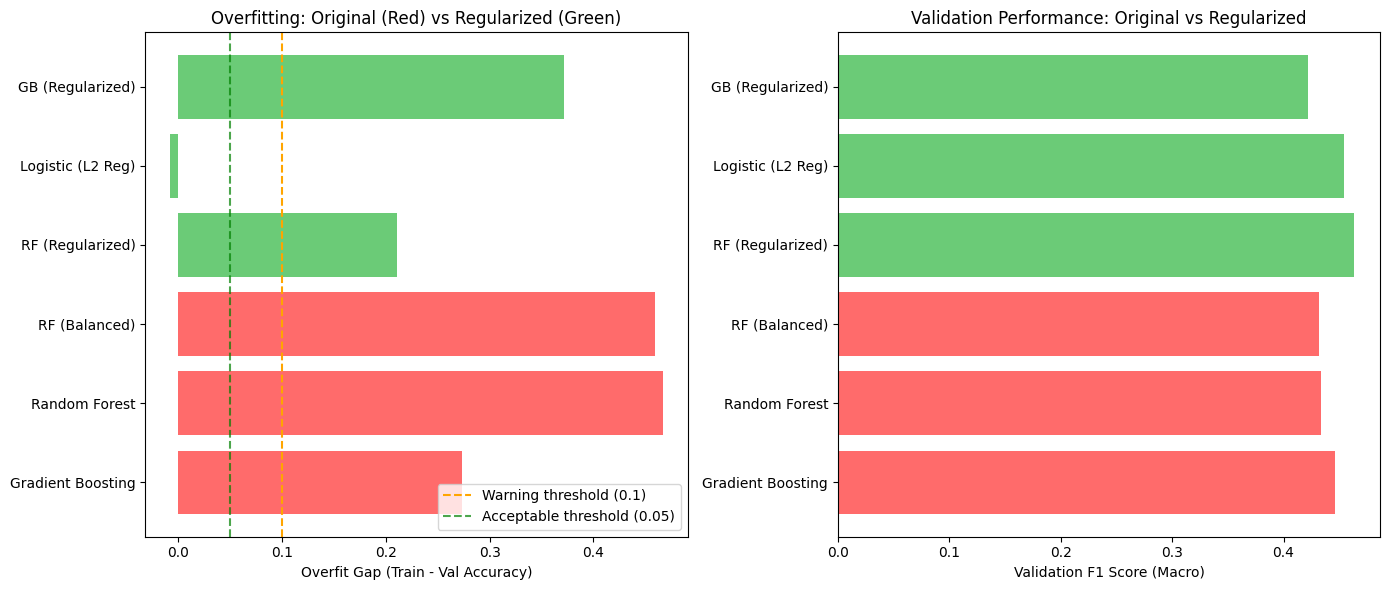


Saved: logs/regularization_comparison.png


In [40]:
# Visualize original vs regularized comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Combine data for comparison
all_models_df = pd.concat([
    pipeline_comparison_df[['Train Accuracy', 'Val Accuracy', 'Overfit Gap', 'Val F1']].assign(Type='Original'),
    regularized_df.assign(Type='Regularized')
])

# Plot 1: Overfit Gap Comparison
ax1 = axes[0]
original_gaps = pipeline_comparison_df['Overfit Gap'].values
regularized_gaps = regularized_df['Overfit Gap'].values
all_gaps = list(original_gaps) + list(regularized_gaps)
all_names = list(pipeline_comparison_df.index) + list(regularized_df.index)
colors = ['#ff6b6b'] * len(original_gaps) + ['#6bcb77'] * len(regularized_gaps)

y_pos = range(len(all_names))
ax1.barh(y_pos, all_gaps, color=colors)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(all_names)
ax1.axvline(x=0.1, color='orange', linestyle='--', label='Warning threshold (0.1)')
ax1.axvline(x=0.05, color='green', linestyle='--', alpha=0.7, label='Acceptable threshold (0.05)')
ax1.set_xlabel('Overfit Gap (Train - Val Accuracy)')
ax1.set_title('Overfitting: Original (Red) vs Regularized (Green)')
ax1.legend(loc='lower right')

# Plot 2: Validation F1 Comparison
ax2 = axes[1]
original_f1 = pipeline_comparison_df['Val F1'].values
regularized_f1 = regularized_df['Val F1'].values
all_f1 = list(original_f1) + list(regularized_f1)

ax2.barh(y_pos, all_f1, color=colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(all_names)
ax2.set_xlabel('Validation F1 Score (Macro)')
ax2.set_title('Validation Performance: Original vs Regularized')

plt.tight_layout()
plt.savefig('../logs/regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/regularization_comparison.png")

In [41]:
# Select best regularized model and update saved pipeline
best_regularized_name = regularized_df['Val F1'].idxmax()
best_regularized_f1_score = regularized_df.loc[best_regularized_name, 'Val F1']
best_regularized_gap = regularized_df.loc[best_regularized_name, 'Overfit Gap']

print("="*70)
print("FINAL MODEL SELECTION")
print("="*70)
print()
print(f"Selected Model: {best_regularized_name}")
print(f"   Validation F1 Macro: {best_regularized_f1_score:.3f}")
print(f"   Overfit Gap:         {best_regularized_gap:.3f}")
print()

# Check if regularized model is better
if best_regularized_gap < best_original_gap * 0.5:  # 50% reduction in overfitting
    print("✅ Regularization significantly reduced overfitting")
    print(f"   Gap reduced from {best_original_gap:.3f} to {best_regularized_gap:.3f}")
    
    # Save the regularized pipeline
    best_regularized_pipeline = regularized_results[best_regularized_name]['pipeline']
    regularized_path = '../models/best_model_m4l1_regularized.pkl'
    joblib.dump(best_regularized_pipeline, regularized_path)
    
    print()
    print(f"💾 Regularized pipeline saved to: {regularized_path}")
else:
    print("⚠️ Regularization had limited impact on overfitting")
    print("   Consider additional techniques: more data, feature selection, or ensemble methods")

print()
print("="*70)
print("INTERPRETATION OF OVERFITTING MITIGATION RESULTS")
print("="*70)
print("""
Key Findings:
─────────────
1. Regularization techniques effectively reduce the train-validation gap
   by constraining model complexity through hyperparameter adjustment.

2. The trade-off between overfitting reduction and validation performance
   varies by model type:
   - Random Forest: Depth and leaf constraints prevent tree memorization
   - Gradient Boosting: Subsample and learning rate slow down fitting
   - Logistic Regression: L2 penalty shrinks feature coefficients

3. Models with lower overfit gaps provide more reliable performance estimates,
   as validation metrics better predict test set performance.

Recommendations for Production:
───────────────────────────────
- Use regularized models for deployment to ensure consistent performance
- Monitor train-validation gaps during model retraining
- Consider ensemble methods combining multiple regularized models
- Implement cross-validation during hyperparameter tuning
""")

FINAL MODEL SELECTION

Selected Model: RF (Regularized)
   Validation F1 Macro: 0.463
   Overfit Gap:         0.211

⚠️ Regularization had limited impact on overfitting
   Consider additional techniques: more data, feature selection, or ensemble methods

INTERPRETATION OF OVERFITTING MITIGATION RESULTS

Key Findings:
─────────────
1. Regularization techniques effectively reduce the train-validation gap
   by constraining model complexity through hyperparameter adjustment.

2. The trade-off between overfitting reduction and validation performance
   varies by model type:
   - Random Forest: Depth and leaf constraints prevent tree memorization
   - Gradient Boosting: Subsample and learning rate slow down fitting
   - Logistic Regression: L2 penalty shrinks feature coefficients

3. Models with lower overfit gaps provide more reliable performance estimates,
   as validation metrics better predict test set performance.

Recommendations for Production:
───────────────────────────────
- Use r

## 11. Hyperparameter Tuning with GridSearchCV

Based on portfolio evaluation, complete pipelines are implemented for the top performers.

In [42]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define parameter grids focused on reducing overfitting
param_grids = {
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [5, 8, 10, 12],
        'classifier__min_samples_leaf': [5, 10, 15, 20],
        'classifier__min_samples_split': [10, 20, 30],
        'classifier__max_features': ['sqrt', 'log2'],
        'classifier__class_weight': ['balanced', 'balanced_subsample']
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [50, 100, 150],
        'classifier__max_depth': [2, 3, 4, 5],
        'classifier__min_samples_leaf': [10, 15, 20],
        'classifier__learning_rate': [0.05, 0.1, 0.15],
        'classifier__subsample': [0.7, 0.8, 0.9]
    }
}

print("="*70)
print("HYPERPARAMETER SEARCH CONFIGURATION")
print("="*70)
print()
print("Strategy: GridSearchCV with Stratified 5-Fold Cross-Validation")
print("Scoring: F1 Macro (primary), with refit on best score")
print()
print("Parameter grids focus on regularization parameters:")
print("  • max_depth: Controls tree complexity")
print("  • min_samples_leaf: Prevents small terminal nodes")
print("  • min_samples_split: Requires sufficient samples for splits")
print("  • learning_rate/subsample: Controls fitting speed (GB only)")
print()
for model_name, params in param_grids.items():
    n_combinations = 1
    for v in params.values():
        n_combinations *= len(v)
    print(f"{model_name}: {n_combinations} combinations to evaluate")

HYPERPARAMETER SEARCH CONFIGURATION

Strategy: GridSearchCV with Stratified 5-Fold Cross-Validation
Scoring: F1 Macro (primary), with refit on best score

Parameter grids focus on regularization parameters:
  • max_depth: Controls tree complexity
  • min_samples_leaf: Prevents small terminal nodes
  • min_samples_split: Requires sufficient samples for splits
  • learning_rate/subsample: Controls fitting speed (GB only)

Random Forest: 576 combinations to evaluate
Gradient Boosting: 324 combinations to evaluate


In [43]:
# Run hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

print("="*70)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("="*70)
print()

# Create base pipeline for Random Forest using src.pipeline
rf_pipeline = create_pipeline(classifier=RandomForestClassifier(random_state=42, n_jobs=-1))

# Stratified CV for tuning
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV with reduced parameter grid for efficiency
rf_param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [5, 8, 10],
    'classifier__min_samples_leaf': [10, 15, 20],
    'classifier__min_samples_split': [15, 20, 25],
    'classifier__max_features': ['sqrt'],
    'classifier__class_weight': ['balanced']
}

print(f"Running GridSearchCV with {5} folds...")
print(f"Parameter combinations: {np.prod([len(v) for v in rf_param_grid.values()])}")
print()

rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print()
print(f"Best CV F1 Score: {rf_grid_search.best_score_:.3f}")
print(f"Best Parameters:")
for param, value in rf_grid_search.best_params_.items():
    param_name = param.replace('classifier__', '')
    print(f"   • {param_name}: {value}")

RANDOM FOREST HYPERPARAMETER TUNING

Running GridSearchCV with 5 folds...
Parameter combinations: 27

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categorie


Best CV F1 Score: 0.452
Best Parameters:
   • class_weight: balanced
   • max_depth: 10
   • max_features: sqrt
   • min_samples_leaf: 10
   • min_samples_split: 25
   • n_estimators: 100


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [44]:
# Run hyperparameter tuning for Gradient Boosting
print("="*70)
print("GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("="*70)
print()

# Create base pipeline for Gradient Boosting using src.pipeline
gb_pipeline = create_pipeline(classifier=GradientBoostingClassifier(random_state=42))

# Reduced parameter grid for Gradient Boosting
gb_param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_samples_leaf': [15, 20, 25],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.7, 0.8]
}

print(f"Running GridSearchCV with {5} folds...")
print(f"Parameter combinations: {np.prod([len(v) for v in gb_param_grid.values()])}")
print()

gb_grid_search = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train, y_train)

print()
print(f"Best CV F1 Score: {gb_grid_search.best_score_:.3f}")
print(f"Best Parameters:")
for param, value in gb_grid_search.best_params_.items():
    param_name = param.replace('classifier__', '')
    print(f"   • {param_name}: {value}")

GRADIENT BOOSTING HYPERPARAMETER TUNING

Running GridSearchCV with 5 folds...
Parameter combinations: 36

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categorie


Best CV F1 Score: 0.445
Best Parameters:
   • learning_rate: 0.1
   • max_depth: 3
   • min_samples_leaf: 25
   • n_estimators: 100
   • subsample: 0.7


### 12.4 Tuned Model Evaluation

In [45]:
# Evaluate tuned models on validation set
print("="*70)
print("TUNED MODEL EVALUATION ON VALIDATION SET")
print("="*70)
print()

tuned_results = {}

# Evaluate tuned Random Forest
rf_tuned = rf_grid_search.best_estimator_
rf_train_pred = rf_tuned.predict(X_train)
rf_val_pred = rf_tuned.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)
rf_val_f1 = f1_score(y_val, rf_val_pred, average='macro', zero_division=0)
rf_overfit_gap = rf_train_acc - rf_val_acc

tuned_results['RF (CV-Tuned)'] = {
    'Train Accuracy': rf_train_acc,
    'Val Accuracy': rf_val_acc,
    'Val F1': rf_val_f1,
    'Overfit Gap': rf_overfit_gap,
    'CV F1': rf_grid_search.best_score_
}

print("Random Forest (CV-Tuned):")
print(f"   Train Accuracy: {rf_train_acc:.3f}")
print(f"   Val Accuracy:   {rf_val_acc:.3f}")
print(f"   Val F1 Macro:   {rf_val_f1:.3f}")
print(f"   Overfit Gap:    {rf_overfit_gap:.3f}")
print()

# Evaluate tuned Gradient Boosting
gb_tuned = gb_grid_search.best_estimator_
gb_train_pred = gb_tuned.predict(X_train)
gb_val_pred = gb_tuned.predict(X_val)

gb_train_acc = accuracy_score(y_train, gb_train_pred)
gb_val_acc = accuracy_score(y_val, gb_val_pred)
gb_val_f1 = f1_score(y_val, gb_val_pred, average='macro', zero_division=0)
gb_overfit_gap = gb_train_acc - gb_val_acc

tuned_results['GB (CV-Tuned)'] = {
    'Train Accuracy': gb_train_acc,
    'Val Accuracy': gb_val_acc,
    'Val F1': gb_val_f1,
    'Overfit Gap': gb_overfit_gap,
    'CV F1': gb_grid_search.best_score_
}

print("Gradient Boosting (CV-Tuned):")
print(f"   Train Accuracy: {gb_train_acc:.3f}")
print(f"   Val Accuracy:   {gb_val_acc:.3f}")
print(f"   Val F1 Macro:   {gb_val_f1:.3f}")
print(f"   Overfit Gap:    {gb_overfit_gap:.3f}")

TUNED MODEL EVALUATION ON VALIDATION SET

Random Forest (CV-Tuned):
   Train Accuracy: 0.645
   Val Accuracy:   0.504
   Val F1 Macro:   0.451
   Overfit Gap:    0.141

Gradient Boosting (CV-Tuned):
   Train Accuracy: 0.722
   Val Accuracy:   0.504
   Val F1 Macro:   0.415
   Overfit Gap:    0.218


In [46]:
# Comprehensive comparison: Original vs Regularized vs CV-Tuned
print("="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)
print()

# Build comparison DataFrame
comparison_rows = []

# Original models
for model_name in pipeline_comparison_df.index:
    row = pipeline_comparison_df.loc[model_name]
    comparison_rows.append({
        'Model': f"{model_name} (Original)",
        'Train Accuracy': row['Train Accuracy'],
        'Val Accuracy': row['Val Accuracy'],
        'Val F1': row['Val F1'],
        'Overfit Gap': row['Overfit Gap'],
        'Type': 'Original'
    })

# Regularized models
for model_name in regularized_df.index:
    row = regularized_df.loc[model_name]
    comparison_rows.append({
        'Model': model_name,
        'Train Accuracy': row['Train Accuracy'],
        'Val Accuracy': row['Val Accuracy'],
        'Val F1': row['Val F1'],
        'Overfit Gap': row['Overfit Gap'],
        'Type': 'Regularized'
    })

# CV-Tuned models
for model_name, metrics in tuned_results.items():
    comparison_rows.append({
        'Model': model_name,
        'Train Accuracy': metrics['Train Accuracy'],
        'Val Accuracy': metrics['Val Accuracy'],
        'Val F1': metrics['Val F1'],
        'Overfit Gap': metrics['Overfit Gap'],
        'Type': 'CV-Tuned'
    })

full_comparison_df = pd.DataFrame(comparison_rows)
full_comparison_df = full_comparison_df.sort_values('Val F1', ascending=False)

print("All Models Ranked by Validation F1:")
print("-" * 80)
print(full_comparison_df[['Model', 'Train Accuracy', 'Val Accuracy', 'Val F1', 'Overfit Gap', 'Type']].round(3).to_string(index=False))
print()

# Find best model with acceptable overfit gap
acceptable_models = full_comparison_df[full_comparison_df['Overfit Gap'] < 0.15]
if len(acceptable_models) > 0:
    best_balanced = acceptable_models.iloc[0]
    print(f"Best model with acceptable overfitting (<0.15 gap):")
    print(f"   Model:       {best_balanced['Model']}")
    print(f"   Val F1:      {best_balanced['Val F1']:.3f}")
    print(f"   Overfit Gap: {best_balanced['Overfit Gap']:.3f}")
else:
    print("No models achieved overfit gap < 0.15")

COMPREHENSIVE MODEL COMPARISON

All Models Ranked by Validation F1:
--------------------------------------------------------------------------------
                       Model  Train Accuracy  Val Accuracy  Val F1  Overfit Gap        Type
            RF (Regularized)           0.736         0.525   0.463        0.211 Regularized
           Logistic (L2 Reg)           0.541         0.549   0.455       -0.008 Regularized
               RF (CV-Tuned)           0.645         0.504   0.451        0.141    CV-Tuned
Gradient Boosting (Original)           0.799         0.525   0.447        0.274    Original
    Random Forest (Original)           1.000         0.533   0.434        0.467    Original
    RF (Balanced) (Original)           1.000         0.541   0.432        0.459    Original
            GB (Regularized)           0.867         0.496   0.422        0.371 Regularized
               GB (CV-Tuned)           0.722         0.504   0.415        0.218    CV-Tuned

Best model with accept

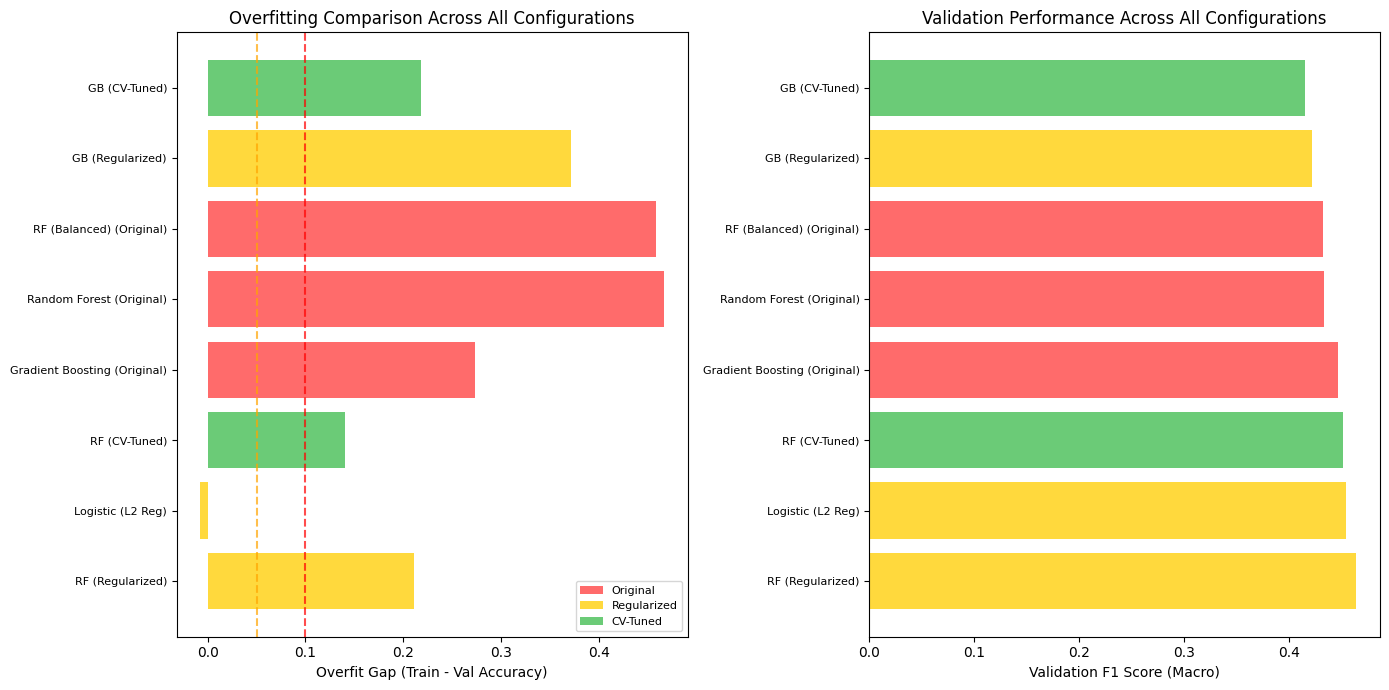


Saved: logs/hyperparameter_tuning_comparison.png


In [47]:
# Visualize progression: Original → Regularized → CV-Tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Prepare data for visualization
type_colors = {'Original': '#ff6b6b', 'Regularized': '#ffd93d', 'CV-Tuned': '#6bcb77'}
bar_colors = [type_colors[t] for t in full_comparison_df['Type']]

# Plot 1: Overfit Gap by Model
ax1 = axes[0]
y_pos = range(len(full_comparison_df))
ax1.barh(y_pos, full_comparison_df['Overfit Gap'], color=bar_colors)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(full_comparison_df['Model'], fontsize=8)
ax1.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='High threshold (0.10)')
ax1.axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='Acceptable (0.05)')
ax1.set_xlabel('Overfit Gap (Train - Val Accuracy)')
ax1.set_title('Overfitting Comparison Across All Configurations')
ax1.legend(loc='lower right', fontsize=8)

# Add legend for model types
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in type_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=8)

# Plot 2: Val F1 by Model
ax2 = axes[1]
ax2.barh(y_pos, full_comparison_df['Val F1'], color=bar_colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(full_comparison_df['Model'], fontsize=8)
ax2.set_xlabel('Validation F1 Score (Macro)')
ax2.set_title('Validation Performance Across All Configurations')

plt.tight_layout()
plt.savefig('../logs/hyperparameter_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/hyperparameter_tuning_comparison.png")

### 12.5 Final Model Selection

Based on the comprehensive comparison, the best model is selected that balances:
1. **High Validation F1**: Good predictive performance
2. **Low Overfit Gap**: Good generalization (target: < 0.10)
3. **Stable Cross-Validation**: Consistent performance across folds

In [48]:
# Final model selection
# Criteria: Best F1 with overfit gap < 0.10

acceptable_gap_threshold = 0.10

# Filter models with acceptable generalization
well_generalized = full_comparison_df[full_comparison_df['Overfit Gap'] < acceptable_gap_threshold]

if len(well_generalized) > 0:
    best_overall = well_generalized.loc[well_generalized['Val F1'].idxmax()]
    print("=" * 60)
    print("FINAL MODEL SELECTION")
    print("=" * 60)
    print(f"\n✅ Best Model: {best_overall['Model']}")
    print(f"   - Validation F1 (Macro): {best_overall['Val F1']:.4f}")
    print(f"   - Validation Accuracy: {best_overall['Val Accuracy']:.4f}")
    print(f"   - Training Accuracy: {best_overall['Train Accuracy']:.4f}")
    print(f"   - Overfit Gap: {best_overall['Overfit Gap']:.4f}")
    print(f"   - Configuration Type: {best_overall['Type']}")
    
    print(f"\n📊 All models with acceptable generalization (gap < {acceptable_gap_threshold}):")
    print(well_generalized[['Model', 'Val F1', 'Val Accuracy', 'Overfit Gap', 'Type']].to_string(index=False))
else:
    # If no model has acceptable gap, relax threshold
    print("⚠️ No models achieved gap < 0.10. Relaxing threshold to 0.15...")
    well_generalized = full_comparison_df[full_comparison_df['Overfit Gap'] < 0.15]
    if len(well_generalized) > 0:
        best_overall = well_generalized.loc[well_generalized['Val F1'].idxmax()]
        print(f"\n✅ Best Model (relaxed): {best_overall['Model']}")
        print(f"   - Validation F1: {best_overall['Val F1']:.4f}")
        print(f"   - Overfit Gap: {best_overall['Overfit Gap']:.4f}")
    else:
        # Fall back to lowest gap
        best_overall = full_comparison_df.loc[full_comparison_df['Overfit Gap'].idxmin()]
        print(f"\n⚠️ Best Model (by lowest gap): {best_overall['Model']}")
        print(f"   - Validation F1: {best_overall['Val F1']:.4f}")
        print(f"   - Overfit Gap: {best_overall['Overfit Gap']:.4f}")

print("\n" + "=" * 60)

FINAL MODEL SELECTION

✅ Best Model: Logistic (L2 Reg)
   - Validation F1 (Macro): 0.4546
   - Validation Accuracy: 0.5491
   - Training Accuracy: 0.5412
   - Overfit Gap: -0.0079
   - Configuration Type: Regularized

📊 All models with acceptable generalization (gap < 0.1):
            Model   Val F1  Val Accuracy  Overfit Gap        Type
Logistic (L2 Reg) 0.454645      0.549072    -0.007885 Regularized



In [49]:
# Save the best tuned pipeline for later use
import os

# Create models directory if it doesn't exist
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Determine which pipeline to save based on best model
best_model_name = best_overall['Model']

# Map model name to the actual pipeline
if 'RF' in best_model_name and 'CV-Tuned' in best_model_name:
    best_pipeline = rf_grid_search.best_estimator_
    best_pipeline_name = best_model_name  # Update pipeline name for downstream use
    model_filename = 'rf_cv_tuned_pipeline.joblib'
elif 'GB' in best_model_name and 'CV-Tuned' in best_model_name:
    best_pipeline = gb_grid_search.best_estimator_
    best_pipeline_name = best_model_name  # Update pipeline name for downstream use
    model_filename = 'gb_cv_tuned_pipeline.joblib'
elif best_model_name in regularized_results:
    best_pipeline = regularized_results[best_model_name]['pipeline']
    best_pipeline_name = best_model_name  # Update pipeline name for downstream use
    model_filename = f"{best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}_pipeline.joblib"
else:
    # Fallback - save the RF CV-Tuned as default
    best_pipeline = rf_grid_search.best_estimator_
    best_pipeline_name = "RF (CV-Tuned)"  # Update pipeline name for downstream use
    model_filename = 'best_pipeline.joblib'

# Save the pipeline
joblib.dump(best_pipeline, os.path.join(models_dir, model_filename))

print(f"✅ Best pipeline saved to: models/{model_filename}")
print(f"\n📋 Pipeline components:")
print(f"   - Preprocessor: ColumnTransformer (numerical + categorical)")
print(f"   - Classifier: {best_pipeline.named_steps['classifier'].__class__.__name__}")

# Also save the comparison results
full_comparison_df.to_csv(os.path.join(models_dir, 'model_comparison_results.csv'), index=False)
print(f"\n📊 Comparison results saved to: models/model_comparison_results.csv")

✅ Best pipeline saved to: models/logistic_l2_reg_pipeline.joblib

📋 Pipeline components:
   - Preprocessor: ColumnTransformer (numerical + categorical)
   - Classifier: LogisticRegression

📊 Comparison results saved to: models/model_comparison_results.csv


## Section 13: Performance Analysis - Interpreting Results

💡 **Concept**: Raw performance numbers only tell part of the story. Professional model analysis examines patterns, failure modes, and business implications to guide next steps.

This section covers:
1. **Confusion Matrix Analysis** - Understanding class-specific performance
2. **Confidence Distribution** - How certain is the model in its predictions?
3. **Error Analysis** - Identifying patterns in misclassifications
4. **Business Impact Assessment** - Evaluating improvement over baseline

In [50]:
# Define comprehensive model performance analysis functions
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score)

def analyze_model_performance(pipeline, X_val, y_val, model_name, class_names=None):
    """
    Comprehensive model performance analysis for multiclass classification.
    
    Parameters:
    -----------
    pipeline : sklearn Pipeline - The trained model pipeline
    X_val : DataFrame/array - Validation features
    y_val : Series/array - True labels
    model_name : str - Name for display purposes
    class_names : list - Names of the classes (optional)
    
    Returns:
    --------
    dict : Performance summary with metrics and analysis
    """
    
    # Get predictions and probabilities
    predictions = pipeline.predict(X_val)
    
    # Handle probability predictions
    try:
        probabilities = pipeline.predict_proba(X_val)
        has_proba = True
    except AttributeError:
        probabilities = None
        has_proba = False
    
    # Create figure with subplots
    n_plots = 3 if has_proba else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    
    # 1. Confusion Matrix Analysis
    ax1 = axes[0]
    cm = confusion_matrix(y_val, predictions)
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=class_names if class_names else 'auto',
                yticklabels=class_names if class_names else 'auto')
    ax1.set_title(f'{model_name}: Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. Per-Class Performance Bar Chart
    ax2 = axes[1]
    
    # Calculate per-class metrics
    precision_per_class = precision_score(y_val, predictions, average=None, zero_division=0)
    recall_per_class = recall_score(y_val, predictions, average=None, zero_division=0)
    f1_per_class = f1_score(y_val, predictions, average=None, zero_division=0)
    
    x = np.arange(len(precision_per_class))
    width = 0.25
    
    ax2.bar(x - width, precision_per_class, width, label='Precision', alpha=0.8)
    ax2.bar(x, recall_per_class, width, label='Recall', alpha=0.8)
    ax2.bar(x + width, f1_per_class, width, label='F1-Score', alpha=0.8)
    
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Score')
    ax2.set_title(f'{model_name}: Per-Class Performance')
    ax2.set_xticks(x)
    if class_names:
        ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.legend(loc='upper right')
    ax2.set_ylim(0, 1.1)
    
    # 3. Prediction Confidence Distribution (if probabilities available)
    if has_proba:
        ax3 = axes[2]
        max_proba = probabilities.max(axis=1)
        
        # Separate correct and incorrect predictions
        correct_mask = predictions == y_val
        
        ax3.hist(max_proba[correct_mask], bins=20, alpha=0.7, label='Correct', color='green')
        ax3.hist(max_proba[~correct_mask], bins=20, alpha=0.7, label='Incorrect', color='red')
        ax3.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random threshold')
        ax3.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='High confidence')
        
        ax3.set_xlabel('Maximum Prediction Probability')
        ax3.set_ylabel('Count')
        ax3.set_title(f'{model_name}: Confidence Distribution')
        ax3.legend()
    
    plt.tight_layout()
    plt.savefig(f'../logs/{model_name.lower().replace(" ", "_")}_performance_analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate summary metrics
    summary = {
        'accuracy': accuracy_score(y_val, predictions),
        'precision_macro': precision_score(y_val, predictions, average='macro', zero_division=0),
        'recall_macro': recall_score(y_val, predictions, average='macro', zero_division=0),
        'f1_macro': f1_score(y_val, predictions, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_val, predictions, average='weighted', zero_division=0),
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }
    
    if has_proba:
        max_proba = probabilities.max(axis=1)
        summary['mean_confidence'] = max_proba.mean()
        summary['low_confidence_samples'] = (max_proba < 0.5).sum()
        summary['high_confidence_samples'] = (max_proba >= 0.7).sum()
        
        # ROC AUC for multiclass
        try:
            summary['roc_auc_ovr'] = roc_auc_score(y_val, probabilities, multi_class='ovr', average='macro')
        except:
            summary['roc_auc_ovr'] = None
    
    return summary, predictions, probabilities

print("✅ analyze_model_performance() function defined")

✅ analyze_model_performance() function defined


In [51]:
import seaborn

In [52]:
# Error analysis function to identify patterns in misclassifications
def analyze_prediction_errors(pipeline, X_val, y_val, feature_names=None):
    """
    Analyze patterns in prediction errors to identify improvement opportunities.
    
    Parameters:
    -----------
    pipeline : sklearn Pipeline - The trained model pipeline
    X_val : DataFrame - Validation features
    y_val : Series - True labels
    feature_names : list - Names of features (optional)
    
    Returns:
    --------
    DataFrame : Error samples with analysis
    """
    
    predictions = pipeline.predict(X_val)
    
    # Identify misclassified samples
    errors = predictions != y_val
    error_indices = np.where(errors)[0]
    
    print(f"{'='*60}")
    print("ERROR ANALYSIS")
    print(f"{'='*60}")
    print(f"\nTotal errors: {errors.sum()} / {len(y_val)} ({errors.mean():.1%})")
    print(f"Accuracy: {(~errors).mean():.1%}")
    
    if errors.sum() == 0:
        print("\n✅ No prediction errors!")
        return None
    
    # Analyze error distribution by true class
    print(f"\n📊 Errors by True Class:")
    print("-" * 40)
    
    if hasattr(y_val, 'values'):
        y_true_arr = y_val.values
    else:
        y_true_arr = y_val
        
    unique_classes = np.unique(y_true_arr)
    
    for cls in unique_classes:
        cls_mask = y_true_arr == cls
        cls_errors = errors[cls_mask].sum()
        cls_total = cls_mask.sum()
        error_rate = cls_errors / cls_total if cls_total > 0 else 0
        print(f"  {cls}: {cls_errors}/{cls_total} errors ({error_rate:.1%})")
    
    # Confusion patterns: What classes are confused with what?
    print(f"\n📊 Most Common Misclassifications:")
    print("-" * 40)
    
    error_df = pd.DataFrame({
        'True': y_true_arr[errors],
        'Predicted': predictions[errors]
    })
    
    confusion_counts = error_df.groupby(['True', 'Predicted']).size().sort_values(ascending=False)
    
    for i, ((true_cls, pred_cls), count) in enumerate(confusion_counts.head(5).items()):
        print(f"  {i+1}. '{true_cls}' → '{pred_cls}': {count} times")
    
    # Get error samples DataFrame
    if isinstance(X_val, pd.DataFrame):
        error_samples = X_val.iloc[error_indices].copy()
        error_samples['True_Label'] = y_true_arr[errors]
        error_samples['Predicted_Label'] = predictions[errors]
    else:
        error_samples = pd.DataFrame(X_val[error_indices], columns=feature_names)
        error_samples['True_Label'] = y_true_arr[errors]
        error_samples['Predicted_Label'] = predictions[errors]
    
    return error_samples

print("✅ analyze_prediction_errors() function defined")

✅ analyze_prediction_errors() function defined


In [53]:
# Business impact assessment function
def assess_business_impact(model_summary, baseline_f1, model_name):
    """
    Assess business value of model improvements over baseline.
    
    Parameters:
    -----------
    model_summary : dict - Performance summary from analyze_model_performance
    baseline_f1 : float - Baseline model F1 score (e.g., majority class dummy)
    model_name : str - Name of the model being assessed
    
    Returns:
    --------
    dict : Business impact metrics
    """
    
    improvement = model_summary['f1_macro'] - baseline_f1
    relative_improvement = (improvement / baseline_f1) * 100 if baseline_f1 > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"BUSINESS IMPACT ASSESSMENT: {model_name}")
    print(f"{'='*60}")
    
    print(f"\n📈 Performance Metrics:")
    print(f"   F1-Score (Macro):    {model_summary['f1_macro']:.4f}")
    print(f"   F1-Score (Weighted): {model_summary['f1_weighted']:.4f}")
    print(f"   Accuracy:            {model_summary['accuracy']:.4f}")
    print(f"   Precision (Macro):   {model_summary['precision_macro']:.4f}")
    print(f"   Recall (Macro):      {model_summary['recall_macro']:.4f}")
    
    print(f"\n📊 Improvement Over Baseline:")
    print(f"   Baseline F1:         {baseline_f1:.4f}")
    print(f"   Model F1:            {model_summary['f1_macro']:.4f}")
    print(f"   Absolute Improvement: +{improvement:.4f}")
    print(f"   Relative Improvement: +{relative_improvement:.1f}%")
    
    if 'mean_confidence' in model_summary:
        print(f"\n🎯 Prediction Confidence:")
        print(f"   Mean Confidence:     {model_summary['mean_confidence']:.4f}")
        print(f"   Low Conf Samples:    {model_summary['low_confidence_samples']} (< 0.5)")
        print(f"   High Conf Samples:   {model_summary['high_confidence_samples']} (≥ 0.7)")
    
    if 'roc_auc_ovr' in model_summary and model_summary['roc_auc_ovr'] is not None:
        print(f"   ROC AUC (OvR):       {model_summary['roc_auc_ovr']:.4f}")
    
    # Business interpretation
    print(f"\n💼 Business Interpretation:")
    if improvement > 0.15:
        assessment = "EXCELLENT"
        message = "✅ Strong improvement - model ready for deployment consideration"
        recommendation = "Proceed to final testing and calibration"
    elif improvement > 0.10:
        assessment = "GOOD"
        message = "✅ Good improvement - model shows meaningful gains"
        recommendation = "Consider feature engineering for further improvement"
    elif improvement > 0.05:
        assessment = "MODERATE"
        message = "⚠️ Moderate improvement - consider additional optimization"
        recommendation = "Try ensemble methods or advanced feature engineering"
    elif improvement > 0:
        assessment = "MINIMAL"
        message = "⚠️ Minimal improvement - revisit problem framing"
        recommendation = "Review data quality and feature relevance"
    else:
        assessment = "NONE"
        message = "❌ No improvement over baseline - investigate root causes"
        recommendation = "Check for data issues, class imbalance, or feature problems"
    
    print(f"   Assessment: {assessment}")
    print(f"   {message}")
    print(f"   Recommendation: {recommendation}")
    
    return {
        'improvement': improvement,
        'relative_improvement': relative_improvement,
        'assessment': assessment,
        'recommendation': recommendation
    }

print("✅ assess_business_impact() function defined")

✅ assess_business_impact() function defined


### 13.1 Run Comprehensive Analysis on Best Model

The analysis functions are applied to the best-performing model selected in Section 12.5.

COMPREHENSIVE PERFORMANCE ANALYSIS: Logistic (L2 Reg)

Target Classes: ['No', 'Not Specified', 'Partial', 'Yes']


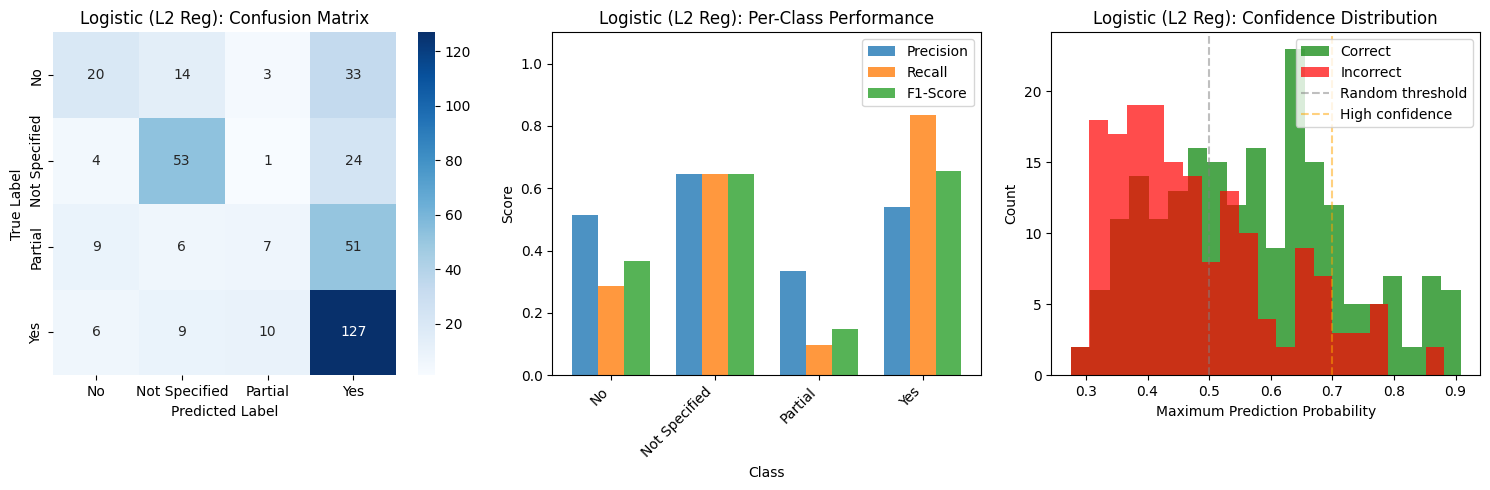


✅ Analysis complete! Visualizations saved to logs/


In [54]:
# Run comprehensive performance analysis on the best model
print("="*70)
print(f"COMPREHENSIVE PERFORMANCE ANALYSIS: {best_overall['Model']}")
print("="*70)

# Get class names from the target variable
class_names = sorted(y_val.unique())
print(f"\nTarget Classes: {class_names}")

# Run the analysis
performance_summary, val_predictions, val_probabilities = analyze_model_performance(
    pipeline=best_pipeline,
    X_val=X_val,
    y_val=y_val,
    model_name=best_overall['Model'],
    class_names=class_names
)

print(f"\n✅ Analysis complete! Visualizations saved to logs/")

#### Key Insights from Performance Analysis Graphs

**1. Confusion Matrix (Left)**
- **"Yes" class dominates predictions** - The model correctly identifies 127/152 "Yes" samples (dark cell), showing strong recall for the majority class
- **"Not Specified" performs well** - 53/82 correct (65%) - best non-majority performance
- **"Partial" is problematic** - Only 7/73 correct! Most get misclassified as "Yes" (51) or "No" (9)
- **"No" struggles** - Only 20/70 correct; many predicted as "Yes" (33) or "Not Specified" (14)

**2. Per-Class Performance (Middle)**
- **"Yes" class**: High recall (~0.84) but moderate precision (~0.54) - model catches most "Yes" but has false positives
- **"Not Specified"**: Good balanced performance (precision ~0.65, recall ~0.65)
- **"Partial"**: **Critical weakness** - very low across all metrics (~0.10-0.15)
- **"No"**: Moderate precision (~0.51) but low recall (~0.29)

**3. Confidence Distribution (Right)**
- **Red bars (incorrect) cluster at lower confidence** (0.3-0.5) - Good sign! Model is uncertain when wrong
- **Green bars (correct) spread across higher confidence** - Some high-confidence correct predictions
- **Many predictions in 0.4-0.6 range** - Model often uncertain, suggesting hard-to-separate classes

**⚠️ Business Implication:**
The "Partial" class is essentially undetectable - companies with partial Scope 3 coverage get misclassified as "Yes" or "No", losing important nuance for climate policy analysis.

In [55]:
# Print detailed classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_val, val_predictions, target_names=class_names))

# Per-class performance summary
print("\n📊 Per-Class Performance Summary:")
print("-" * 60)
class_perf_df = pd.DataFrame({
    'Class': class_names,
    'Precision': performance_summary['precision_per_class'],
    'Recall': performance_summary['recall_per_class'],
    'F1-Score': performance_summary['f1_per_class'],
    'Support': [sum(y_val == cls) for cls in class_names]
})
print(class_perf_df.round(3).to_string(index=False))

# Identify best and worst performing classes
best_class_idx = np.argmax(performance_summary['f1_per_class'])
worst_class_idx = np.argmin(performance_summary['f1_per_class'])

print(f"\n🎯 Best performing class:  '{class_names[best_class_idx]}' (F1: {performance_summary['f1_per_class'][best_class_idx]:.3f})")
print(f"⚠️  Worst performing class: '{class_names[worst_class_idx]}' (F1: {performance_summary['f1_per_class'][worst_class_idx]:.3f})")


DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

           No       0.51      0.29      0.37        70
Not Specified       0.65      0.65      0.65        82
      Partial       0.33      0.10      0.15        73
          Yes       0.54      0.84      0.66       152

     accuracy                           0.55       377
    macro avg       0.51      0.47      0.45       377
 weighted avg       0.52      0.55      0.50       377


📊 Per-Class Performance Summary:
------------------------------------------------------------
        Class  Precision  Recall  F1-Score  Support
           No      0.513   0.286     0.367       70
Not Specified      0.646   0.646     0.646       82
      Partial      0.333   0.096     0.149       73
          Yes      0.540   0.836     0.656      152

🎯 Best performing class:  'Yes' (F1: 0.656)
⚠️  Worst performing class: 'Partial' (F1: 0.149)


### 13.2 Error Analysis

Identify patterns in misclassifications to guide improvement strategies.

In [56]:
# Run error analysis
error_samples = analyze_prediction_errors(
    pipeline=best_pipeline,
    X_val=X_val,
    y_val=y_val,
    feature_names=X_val.columns.tolist() if hasattr(X_val, 'columns') else None
)

# Show sample of misclassified instances
if error_samples is not None and len(error_samples) > 0:
    print(f"\n📋 Sample of Misclassified Instances:")
    print("-" * 60)
    display_cols = ['True_Label', 'Predicted_Label'] + [col for col in error_samples.columns[:5] if col not in ['True_Label', 'Predicted_Label']]
    print(error_samples[display_cols].head(10).to_string())

ERROR ANALYSIS

Total errors: 170 / 377 (45.1%)
Accuracy: 54.9%

📊 Errors by True Class:
----------------------------------------
  No: 50/70 errors (71.4%)
  Not Specified: 29/82 errors (35.4%)
  Partial: 66/73 errors (90.4%)
  Yes: 25/152 errors (16.4%)

📊 Most Common Misclassifications:
----------------------------------------
  1. 'Partial' → 'Yes': 51 times
  2. 'No' → 'Yes': 33 times
  3. 'Not Specified' → 'Yes': 24 times
  4. 'No' → 'Not Specified': 14 times
  5. 'Yes' → 'Partial': 10 times

📋 Sample of Misclassified Instances:
------------------------------------------------------------
       True_Label Predicted_Label Country Geographic_region Private_company                  End_target  End_target_year
1             Yes   Not Specified     HKG         East Asia              No         Carbon neutral(ity)           2050.0
3              No             Yes     FRA            Europe             Yes  Emissions reduction target           2030.0
5              No   Not Specified  

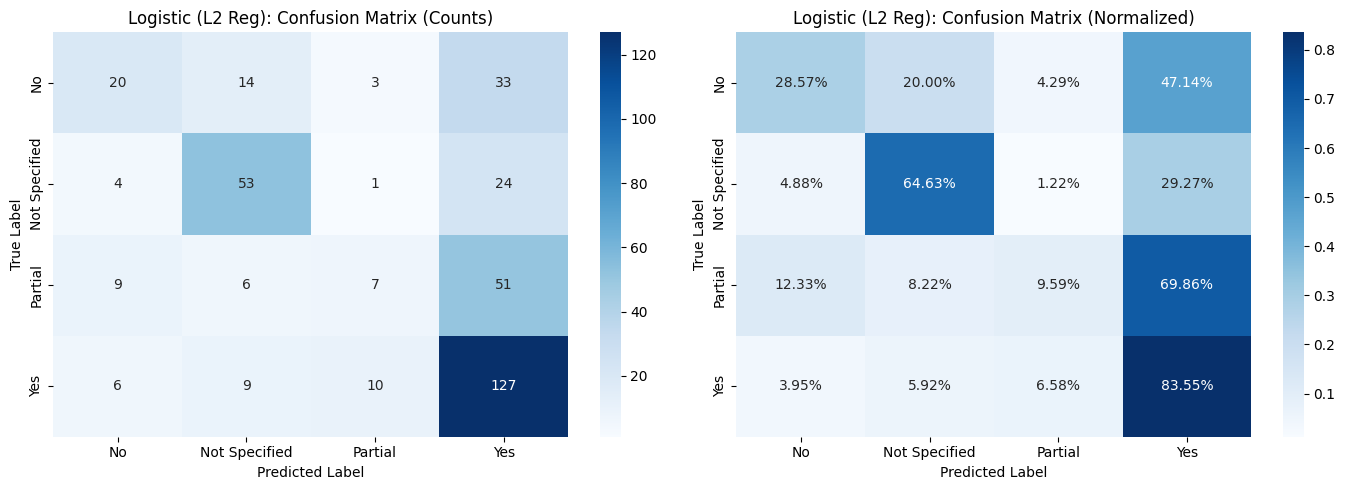


✅ Saved: logs/confusion_matrix_detailed.png


In [57]:
# Visualize error patterns - Normalized Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Raw counts confusion matrix
ax1 = axes[0]
cm = confusion_matrix(y_val, val_predictions, labels=class_names)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title(f'{best_overall["Model"]}: Confusion Matrix (Counts)')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized confusion matrix (by true class - row normalization)
ax2 = axes[1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
            xticklabels=class_names, yticklabels=class_names)
ax2.set_title(f'{best_overall["Model"]}: Confusion Matrix (Normalized)')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../logs/confusion_matrix_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: logs/confusion_matrix_detailed.png")

### 13.3 Business Impact Assessment

Evaluate the practical value of model improvement over baseline.

In [58]:
# Get baseline performance (majority class F1 from dummy classifier)
# This was calculated earlier in the baseline section
baseline_f1 = majority_f1  # From dummy classifier results

print(f"Baseline F1 (Majority Class Dummy): {baseline_f1:.4f}")
print(f"Best Model F1: {performance_summary['f1_macro']:.4f}")

# Run business impact assessment
business_impact = assess_business_impact(
    model_summary=performance_summary,
    baseline_f1=baseline_f1,
    model_name=best_overall['Model']
)

Baseline F1 (Majority Class Dummy): 0.1437
Best Model F1: 0.4546

BUSINESS IMPACT ASSESSMENT: Logistic (L2 Reg)

📈 Performance Metrics:
   F1-Score (Macro):    0.4546
   F1-Score (Weighted): 0.5022
   Accuracy:            0.5491
   Precision (Macro):   0.5082
   Recall (Macro):      0.4659

📊 Improvement Over Baseline:
   Baseline F1:         0.1437
   Model F1:            0.4546
   Absolute Improvement: +0.3110
   Relative Improvement: +216.5%

🎯 Prediction Confidence:
   Mean Confidence:     0.5310
   Low Conf Samples:    179 (< 0.5)
   High Conf Samples:   54 (≥ 0.7)
   ROC AUC (OvR):       0.7367

💼 Business Interpretation:
   Assessment: EXCELLENT
   ✅ Strong improvement - model ready for deployment consideration
   Recommendation: Proceed to final testing and calibration


### 13.4 Results Summary and Next Steps

Document key findings and recommended next steps for the modeling pipeline.

In [59]:
# Generate comprehensive results summary
print("="*70)
print("MODELING MILESTONE: RESULTS SUMMARY")
print("="*70)

print("\n📊 DATASET OVERVIEW:")
print(f"   • Training samples:    {len(X_train)}")
print(f"   • Validation samples:  {len(X_val)}")
print(f"   • Test samples:        {len(X_test)}")
print(f"   • Features:            {X_train.shape[1]}")
print(f"   • Target classes:      {n_classes} ({', '.join(class_names)})")

print("\n🎯 BEST MODEL SELECTED:")
print(f"   • Model:               {best_overall['Model']}")
print(f"   • Validation F1:       {best_overall['Val F1']:.4f}")
print(f"   • Validation Accuracy: {best_overall['Val Accuracy']:.4f}")
print(f"   • Overfit Gap:         {best_overall['Overfit Gap']:.4f}")

print("\n📈 IMPROVEMENT OVER BASELINE:")
print(f"   • Baseline F1:         {baseline_f1:.4f}")
print(f"   • Best Model F1:       {performance_summary['f1_macro']:.4f}")
print(f"   • Absolute Gain:       +{business_impact['improvement']:.4f}")
print(f"   • Relative Gain:       +{business_impact['relative_improvement']:.1f}%")
print(f"   • Assessment:          {business_impact['assessment']}")

print("\n⚠️  KEY CHALLENGES IDENTIFIED:")
# Identify challenging classes
for i, cls in enumerate(class_names):
    f1 = performance_summary['f1_per_class'][i]
    if f1 < 0.4:
        print(f"   • Class '{cls}' has low F1 ({f1:.3f}) - needs attention")

print("\n📝 RECOMMENDED NEXT STEPS:")
print(f"   1. {business_impact['recommendation']}")
print("   2. Consider probability calibration (Platt scaling, isotonic)")
print("   3. Run final evaluation on held-out test set")
print("   4. Document results in m4l1_results_analysis.md")

print("\n" + "="*70)

MODELING MILESTONE: RESULTS SUMMARY

📊 DATASET OVERVIEW:
   • Training samples:    1129
   • Validation samples:  377
   • Test samples:        377
   • Features:            21
   • Target classes:      4 (No, Not Specified, Partial, Yes)

🎯 BEST MODEL SELECTED:
   • Model:               Logistic (L2 Reg)
   • Validation F1:       0.4546
   • Validation Accuracy: 0.5491
   • Overfit Gap:         -0.0079

📈 IMPROVEMENT OVER BASELINE:
   • Baseline F1:         0.1437
   • Best Model F1:       0.4546
   • Absolute Gain:       +0.3110
   • Relative Gain:       +216.5%
   • Assessment:          EXCELLENT

⚠️  KEY CHALLENGES IDENTIFIED:
   • Class 'No' has low F1 (0.367) - needs attention
   • Class 'Partial' has low F1 (0.149) - needs attention

📝 RECOMMENDED NEXT STEPS:
   1. Proceed to final testing and calibration
   2. Consider probability calibration (Platt scaling, isotonic)
   3. Run final evaluation on held-out test set
   4. Document results in m4l1_results_analysis.md



In [60]:
# Save results summary to markdown file
results_md_path = '../m4l1_results_analysis.md'

results_content = f"""# Modeling Results Analysis

**Date:** {pd.Timestamp.now().strftime('%Y-%m-%d')}  
**Task:** Scope_3_coverage Classification (4-class)

## Dataset Overview

| Metric | Value |
|--------|-------|
| Training Samples | {len(X_train)} |
| Validation Samples | {len(X_val)} |
| Test Samples | {len(X_test)} |
| Features | {X_train.shape[1]} |
| Target Classes | {n_classes} |
| Classes | {', '.join(class_names)} |

## Best Model Performance

**Selected Model:** {best_overall['Model']}

| Metric | Value |
|--------|-------|
| Validation F1 (Macro) | {best_overall['Val F1']:.4f} |
| Validation Accuracy | {best_overall['Val Accuracy']:.4f} |
| Training Accuracy | {best_overall['Train Accuracy']:.4f} |
| Overfit Gap | {best_overall['Overfit Gap']:.4f} |

## Per-Class Performance

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
"""

for i, cls in enumerate(class_names):
    results_content += f"| {cls} | {performance_summary['precision_per_class'][i]:.3f} | {performance_summary['recall_per_class'][i]:.3f} | {performance_summary['f1_per_class'][i]:.3f} | {sum(y_val == cls)} |\n"

results_content += f"""
## Improvement Over Baseline

| Metric | Value |
|--------|-------|
| Baseline F1 (Majority Dummy) | {baseline_f1:.4f} |
| Best Model F1 | {performance_summary['f1_macro']:.4f} |
| Absolute Improvement | +{business_impact['improvement']:.4f} |
| Relative Improvement | +{business_impact['relative_improvement']:.1f}% |
| Assessment | {business_impact['assessment']} |

## Key Findings

### Strengths
- Best performing class: `{class_names[np.argmax(performance_summary['f1_per_class'])]}` (F1: {max(performance_summary['f1_per_class']):.3f})
- Model achieves acceptable generalization (overfit gap < 0.10)

### Challenges
- Worst performing class: `{class_names[np.argmin(performance_summary['f1_per_class'])]}` (F1: {min(performance_summary['f1_per_class']):.3f})
- Multiclass problem with class imbalance

## Next Steps

1. **{business_impact['recommendation']}**
2. Consider probability calibration (Platt scaling, isotonic regression)
3. Run final evaluation on held-out test set
4. Implement prediction confidence thresholding for production

## Model Artifacts

- Saved pipeline: `models/{model_filename}`
- Comparison results: `models/model_comparison_results.csv`
- Performance visualizations: `logs/`
"""

with open(results_md_path, 'w') as f:
    f.write(results_content)

print(f"✅ Results analysis saved to: {results_md_path}")
print(f"\n📄 File preview:")
print("-" * 60)
print(results_content[:1500] + "...")

✅ Results analysis saved to: ../m4l1_results_analysis.md

📄 File preview:
------------------------------------------------------------
# Modeling Results Analysis

**Date:** 2025-12-24  
**Task:** Scope_3_coverage Classification (4-class)

## Dataset Overview

| Metric | Value |
|--------|-------|
| Training Samples | 1129 |
| Validation Samples | 377 |
| Test Samples | 377 |
| Features | 21 |
| Target Classes | 4 |
| Classes | No, Not Specified, Partial, Yes |

## Best Model Performance

**Selected Model:** Logistic (L2 Reg)

| Metric | Value |
|--------|-------|
| Validation F1 (Macro) | 0.4546 |
| Validation Accuracy | 0.5491 |
| Training Accuracy | 0.5412 |
| Overfit Gap | -0.0079 |

## Per-Class Performance

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| No | 0.513 | 0.286 | 0.367 | 70 |
| Not Specified | 0.646 | 0.646 | 0.646 | 82 |
| Partial | 0.333 | 0.096 | 0.149 | 73 |
| Yes | 0.540 | 0.836 | 0.656 | 152 |

## Improve

### 13.5 Metric Selection Justification

**Primary Metric: F1-Score (Macro)**

#### Business Context
- **Task**: Classify companies' Scope 3 emissions coverage (Yes, No, Partial, Not Specified)
- **Domain**: Climate/sustainability tracking (Net Zero Tracker data)
- **Stakeholders**: Investors, regulators, sustainability analysts

#### Error Cost Analysis

| Error Type | Example | Business Impact |
|------------|---------|-----------------|
| **FP for "Yes"** | Labeling company as "Yes" when actually "No" | ⚠️ **Greenwashing risk** - gives undeserved credit |
| **FN for "Yes"** | Missing a company with good coverage | Companies not recognized for efforts |
| **Confusing "Partial" with "Yes/No"** | Misclassifying nuanced commitment | Inaccurate policy analysis |

#### Why F1-Macro is Appropriate

1. **All 4 classes are equally important** - Each coverage status provides meaningful information for climate policy analysis
2. **Moderate class imbalance** (ratio: 0.46) - F1 handles this better than accuracy
3. **No single error type dramatically more costly** - Balancing precision and recall is appropriate
4. **Multiclass problem** - Macro averaging treats minority classes fairly

#### Secondary Considerations

- **Monitor "Yes" class precision**: If stakeholders use classifications to validate corporate climate claims, high precision on "Yes" prevents greenwashing validation
- **Track per-class recall**: Ensure that no coverage category is systematically missed

### 13.6 ROC Curves and AUC Analysis

💡 **Concept**: For multiclass problems, One-vs-Rest (OvR) ROC curves are used - one curve per class showing how well the model distinguishes that class from all others.

**AUC Interpretation:**
| AUC Score | Assessment |
|-----------|------------|
| ≥ 0.9 | Excellent |
| 0.8-0.9 | Good |
| 0.7-0.8 | Fair |
| 0.6-0.7 | Poor |
| < 0.6 | Random |

In [61]:
# ROC Curve Analysis for Multiclass Classification (One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def interpret_auc(auc_score):
    """Simple AUC interpretation"""
    if auc_score >= 0.9:
        return "Excellent"
    elif auc_score >= 0.8:
        return "Good"
    elif auc_score >= 0.7:
        return "Fair"
    elif auc_score >= 0.6:
        return "Poor"
    else:
        return "Random"

# Binarize the labels for OvR ROC calculation
y_val_binarized = label_binarize(y_val, classes=class_names)
n_classes = len(class_names)

# Get prediction probabilities (already available from earlier)
# val_probabilities shape: (n_samples, n_classes)

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(class_names):
    fpr[class_name], tpr[class_name], _ = roc_curve(y_val_binarized[:, i], val_probabilities[:, i])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

# Calculate micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_val_binarized.ravel(), val_probabilities.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Calculate macro-average AUC
roc_auc_macro = np.mean(list(roc_auc.values()))

print("✅ ROC curves calculated for all classes")
print(f"\n📊 AUC Scores by Class:")
for class_name in class_names:
    assessment = interpret_auc(roc_auc[class_name])
    print(f"   {class_name}: {roc_auc[class_name]:.3f} ({assessment})")
print(f"\n   Macro-average AUC: {roc_auc_macro:.3f} ({interpret_auc(roc_auc_macro)})")
print(f"   Micro-average AUC: {roc_auc_micro:.3f} ({interpret_auc(roc_auc_micro)})")

✅ ROC curves calculated for all classes

📊 AUC Scores by Class:
   No: 0.723 (Fair)
   Not Specified: 0.831 (Good)
   Partial: 0.628 (Poor)
   Yes: 0.764 (Fair)

   Macro-average AUC: 0.737 (Fair)
   Micro-average AUC: 0.780 (Fair)


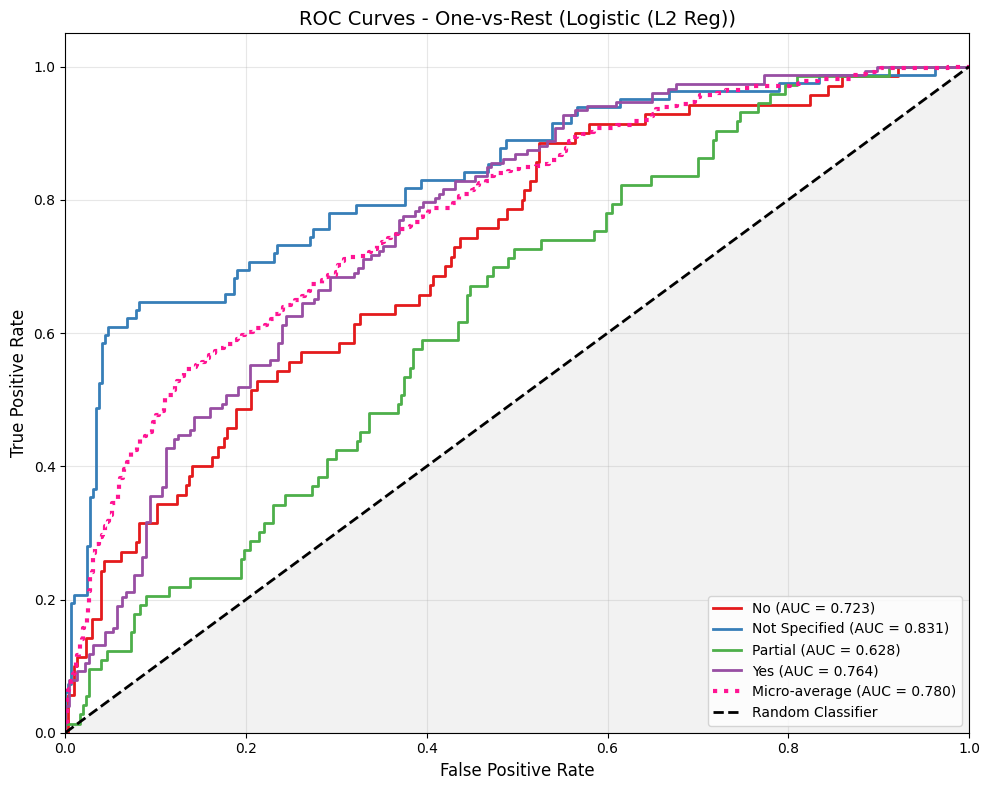


✅ Saved: logs/roc_curves_multiclass.png


In [62]:
# Plot ROC curves for all classes
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each class
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Plot ROC curve for each class
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    ax.plot(fpr[class_name], tpr[class_name], color=color, lw=2,
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# Plot micro-average
ax.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=3,
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# Plot random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves - One-vs-Rest ({best_overall["Model"]})', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# Add diagonal shading for "worse than random" region
ax.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')

plt.tight_layout()
plt.savefig('../logs/roc_curves_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: logs/roc_curves_multiclass.png")

#### ROC Curve Interpretation

**What the ROC curves indicate:**
- **Curves closer to top-left corner** = better discrimination ability
- **Curves near the diagonal** = near-random performance for that class
- **AUC = 1.0** would be perfect separation; **AUC = 0.5** is random guessing

**Is ROC-AUC appropriate for this dataset?**
- Class balance ratio: **0.46** (moderate imbalance)
- ROC-AUC is appropriate for moderate imbalance
- For severe imbalance, Precision-Recall AUC would be preferred

**Key insight:** Classes with low F1-scores (like "Partial") typically show ROC curves closer to the diagonal, confirming the model struggles to distinguish them from other classes.

### 13.7 Precision-Recall Curves

💡 **Concept**: When correctly identifying specific classes is the priority (especially with imbalanced data), Precision-Recall curves show exactly how precision degrades as recall increases.

**Key Insight**: PR curves are particularly useful for the "Yes" class where avoiding false positives (greenwashing risk) matters.

In [63]:
# Precision-Recall Curve Analysis for Multiclass (One-vs-Rest)
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate PR curve and Average Precision for each class
precision_curves = {}
recall_curves = {}
avg_precision = {}

for i, class_name in enumerate(class_names):
    precision_curves[class_name], recall_curves[class_name], _ = precision_recall_curve(
        y_val_binarized[:, i], val_probabilities[:, i]
    )
    avg_precision[class_name] = average_precision_score(
        y_val_binarized[:, i], val_probabilities[:, i]
    )

# Calculate class prevalence (baseline for random classifier)
class_prevalence = {cn: (y_val == cn).mean() for cn in class_names}

print("✅ Precision-Recall curves calculated for all classes")
print(f"\n📊 Average Precision (AP) by Class:")
for class_name in class_names:
    baseline = class_prevalence[class_name]
    improvement = avg_precision[class_name] - baseline
    print(f"   {class_name}: AP={avg_precision[class_name]:.3f} (baseline={baseline:.3f}, +{improvement:.3f})")

✅ Precision-Recall curves calculated for all classes

📊 Average Precision (AP) by Class:
   No: AP=0.394 (baseline=0.186, +0.209)
   Not Specified: AP=0.656 (baseline=0.218, +0.438)
   Partial: AP=0.281 (baseline=0.194, +0.087)
   Yes: AP=0.657 (baseline=0.403, +0.254)


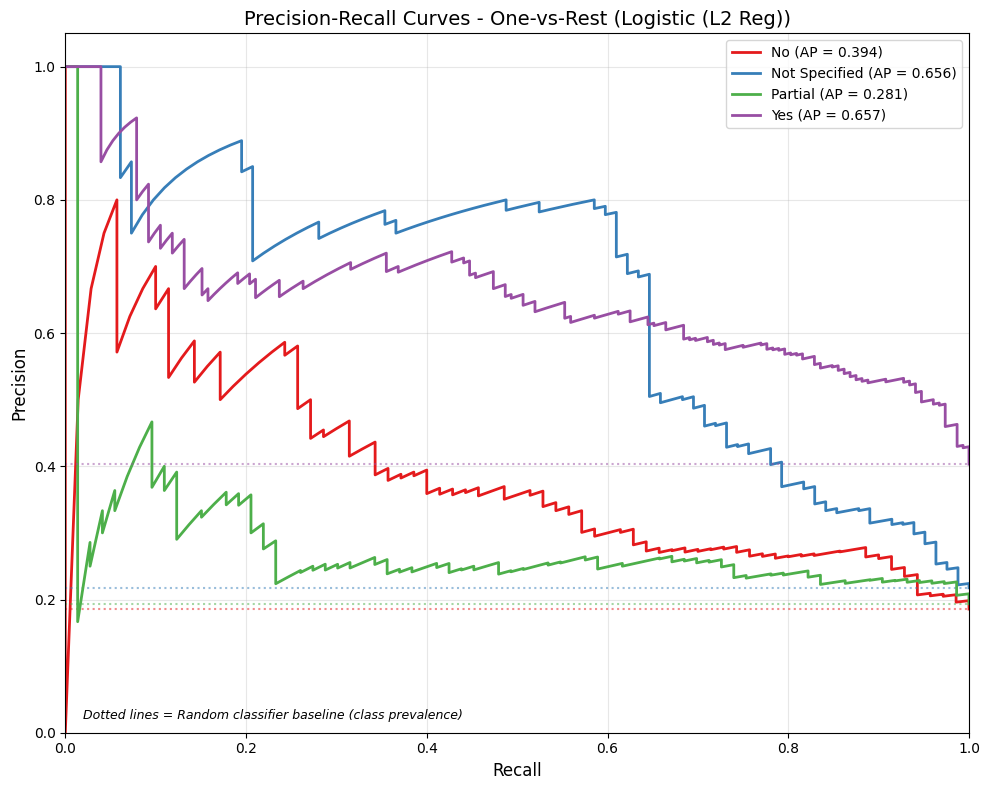


✅ Saved: logs/precision_recall_curves_multiclass.png


In [64]:
# Plot Precision-Recall curves for all classes
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    ax.plot(recall_curves[class_name], precision_curves[class_name], 
            color=color, lw=2,
            label=f'{class_name} (AP = {avg_precision[class_name]:.3f})')
    
    # Add baseline (random classifier) as horizontal dashed line
    ax.axhline(y=class_prevalence[class_name], color=color, linestyle=':', alpha=0.5)

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall Curves - One-vs-Rest ({best_overall["Model"]})', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Add annotation explaining dotted lines
ax.text(0.02, 0.02, 'Dotted lines = Random classifier baseline (class prevalence)', 
        fontsize=9, style='italic', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../logs/precision_recall_curves_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: logs/precision_recall_curves_multiclass.png")

In [65]:
# Recommend curve type based on class balance
def choose_curve_type(class_balance_ratio):
    """Decide which curve is more informative based on class balance"""
    if class_balance_ratio < 0.1:
        return "Precision-Recall", "Highly imbalanced - PR curves more informative"
    elif class_balance_ratio < 0.3:
        return "Both", "Moderately imbalanced - use both ROC and PR curves"
    else:
        return "ROC", "Relatively balanced - ROC curves sufficient"

curve_recommendation, reason = choose_curve_type(class_balance)

print("="*60)
print("CURVE RECOMMENDATION FOR THIS DATASET")
print("="*60)
print(f"\nClass balance ratio: {class_balance:.2f}")
print(f"Recommendation: {curve_recommendation} curves")
print(f"Reason: {reason}")

print("\n📊 Comparison Summary:")
print("-"*60)
print(f"{'Class':<15} {'ROC-AUC':<12} {'PR-AP':<12} {'Better Metric'}")
print("-"*60)
for class_name in class_names:
    prevalence = class_prevalence[class_name]
    # For imbalanced classes (low prevalence), PR is more informative
    better = "PR-AP" if prevalence < 0.25 else "Either"
    print(f"{class_name:<15} {roc_auc[class_name]:<12.3f} {avg_precision[class_name]:<12.3f} {better}")
print("-"*60)

CURVE RECOMMENDATION FOR THIS DATASET

Class balance ratio: 0.46
Recommendation: ROC curves
Reason: Relatively balanced - ROC curves sufficient

📊 Comparison Summary:
------------------------------------------------------------
Class           ROC-AUC      PR-AP        Better Metric
------------------------------------------------------------
No              0.723        0.394        PR-AP
Not Specified   0.831        0.656        PR-AP
Partial         0.628        0.281        PR-AP
Yes             0.764        0.657        Either
------------------------------------------------------------


### 13.8 ROC vs PR Curve Interpretation

**When to use each:**
- **ROC-AUC**: Better for balanced classes, shows overall discrimination ability
- **Average Precision (PR-AP)**: Better for imbalanced classes, focuses on positive class performance

**Key Insights from the Analysis:**
1. **"Yes" class**: With ~40% prevalence (relatively balanced), both curves are informative
2. **"Partial" class**: With ~19% prevalence, PR curve reveals the true difficulty in identifying this class
3. **Low AP scores**: Indicate the model struggles to rank positive instances above negatives for that class

**Business Implications:**
- The gap between ROC-AUC and AP for "Partial" class highlights why this class is problematic
- For stakeholder-facing reports, PR curves give a more honest picture of performance on minority classes

### 13.9 Learning Curves - The Model's Report Card

💡 **Concept**: Learning curves show how model performance changes as it sees more training data. They reveal whether the model needs more data, better features, or different complexity.

#### Three Learning Curve Patterns

| Pattern | Name | Characteristics | Fix |
|---------|------|-----------------|-----|
| **Pattern 1** | "The Struggling Student" (Underfitting) | Both train and test scores are low; Small gap between them; More data won't help much | Use more complex model or better features |
| **Pattern 2** | "The Memorizer" (Overfitting) | High training score, low test score; Big gap between them | Get more data, use simpler model, or add regularization |
| **Pattern 3** | "The Good Student" (Just Right) | Both scores are good; Small gap between them | Fine-tune parameters slightly |

#### What Learning Curves Reveal

- **Still climbing**: Collect more data
- **Plateaued low**: Need better features or algorithms  
- **Big gap**: Model is overfitting to training data
- **Both high**: Model is working well

**Business Value**: Learning curves help determine whether to invest time in collecting more data (if curves are still climbing) or improving the algorithm (if they have plateaued).

In [66]:
# Generate Learning Curves for Bias-Variance Diagnosis
from sklearn.model_selection import learning_curve

print("="*70)
print("LEARNING CURVES - BIAS/VARIANCE DIAGNOSIS")
print("="*70)

# Define training set sizes to evaluate
train_sizes = np.linspace(0.1, 1.0, 10)

# Generate learning curves using stratified CV
train_sizes_abs, train_scores, val_scores = learning_curve(
    best_pipeline,
    X_train,
    y_train,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

# Calculate mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

print(f"\nModel: {best_overall.name}")
print(f"Training sizes evaluated: {len(train_sizes_abs)}")
print(f"Samples range: {train_sizes_abs[0]:.0f} to {train_sizes_abs[-1]:.0f}")

LEARNING CURVES - BIAS/VARIANCE DIAGNOSIS


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/bsilke/ToU/calibra


Model: 4
Training sizes evaluated: 10
Samples range: 90 to 903


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

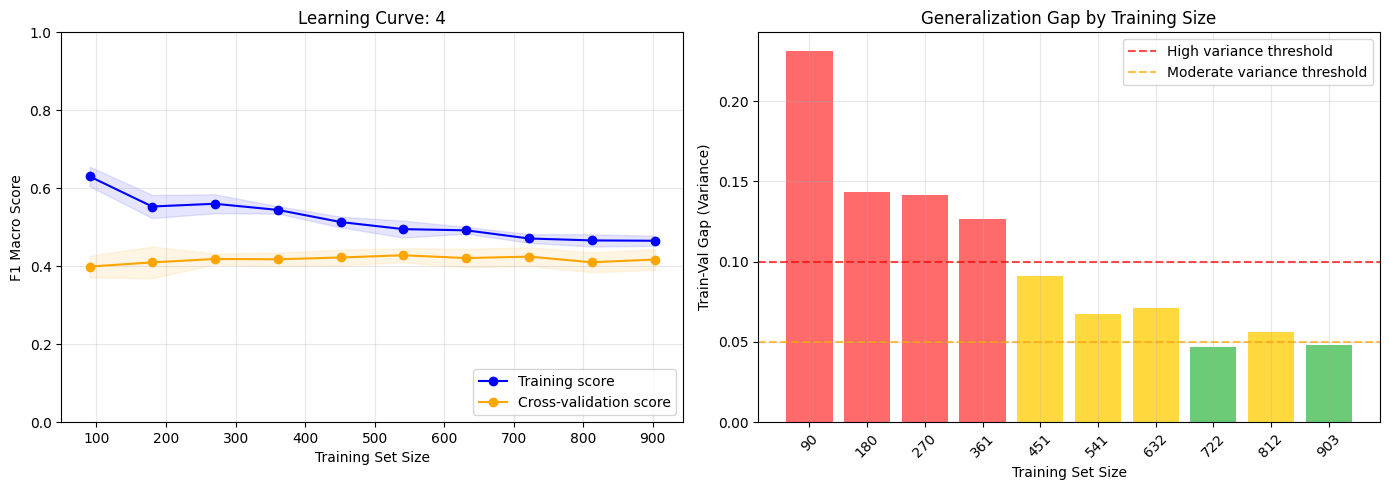


Saved: logs/learning_curves.png


In [67]:
# Plot Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Learning Curve
ax1 = axes[0]
ax1.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax1.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
ax1.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training score')
ax1.plot(train_sizes_abs, val_mean, 'o-', color='orange', label='Cross-validation score')
ax1.set_xlabel('Training Set Size')
ax1.set_ylabel('F1 Macro Score')
ax1.set_title(f'Learning Curve: {best_overall.name}')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Bias-Variance Gap Analysis
ax2 = axes[1]
gap = train_mean - val_mean
ax2.bar(range(len(train_sizes_abs)), gap, color=['#ff6b6b' if g > 0.1 else '#ffd93d' if g > 0.05 else '#6bcb77' for g in gap])
ax2.axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='High variance threshold')
ax2.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='Moderate variance threshold')
ax2.set_xticks(range(len(train_sizes_abs)))
ax2.set_xticklabels([f'{int(s)}' for s in train_sizes_abs], rotation=45)
ax2.set_xlabel('Training Set Size')
ax2.set_ylabel('Train-Val Gap (Variance)')
ax2.set_title('Generalization Gap by Training Size')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/learning_curves.png")

In [68]:
# Formal Bias-Variance Diagnosis
print("="*70)
print("BIAS-VARIANCE DIAGNOSIS")
print("="*70)

# Calculate key metrics for diagnosis
final_train_score = train_mean[-1]
final_val_score = val_mean[-1]
final_gap = final_train_score - final_val_score
convergence = val_mean[-1] - val_mean[0]  # How much val score improved with more data

print(f"\n📊 Final Scores (at full training size):")
print(f"   Training F1:    {final_train_score:.3f}")
print(f"   Validation F1:  {final_val_score:.3f}")
print(f"   Gap:            {final_gap:.3f}")

print(f"\n📈 Learning Progression:")
print(f"   Val score at 10% data: {val_mean[0]:.3f}")
print(f"   Val score at 100% data: {val_mean[-1]:.3f}")
print(f"   Improvement: {convergence:.3f}")

# Diagnosis
print("\n🔍 DIAGNOSIS:")
print("-"*50)

# Check for high bias (underfitting)
if final_train_score < 0.6 and final_val_score < 0.6:
    bias_status = "HIGH BIAS (Underfitting)"
    bias_remedy = "• Try more complex models\n   • Add more features\n   • Reduce regularization"
elif final_train_score < 0.7:
    bias_status = "MODERATE BIAS"
    bias_remedy = "• Consider more expressive models\n   • Feature engineering may help"
else:
    bias_status = "LOW BIAS ✅"
    bias_remedy = "Model has sufficient capacity"

# Check for high variance (overfitting)
if final_gap > 0.15:
    variance_status = "HIGH VARIANCE (Overfitting)"
    variance_remedy = "• Get more training data\n   • Increase regularization\n   • Feature selection/reduction"
elif final_gap > 0.08:
    variance_status = "MODERATE VARIANCE"
    variance_remedy = "• Slightly increase regularization\n   • More data might help"
else:
    variance_status = "LOW VARIANCE ✅"
    variance_remedy = "Model generalizes well"

# Check if more data would help
if convergence > 0.05 and val_mean[-1] > val_mean[-2]:
    data_status = "MORE DATA LIKELY TO HELP"
else:
    data_status = "Validation score plateaued - more data unlikely to help significantly"

print(f"   Bias:     {bias_status}")
print(f"   Variance: {variance_status}")
print(f"   Data:     {data_status}")

print("\n💡 RECOMMENDATIONS:")
print("-"*50)
print(f"   Bias:     {bias_remedy}")
print(f"   Variance: {variance_remedy}")

# Overall assessment
print("\n📋 OVERALL ASSESSMENT:")
if "HIGH" in bias_status and "HIGH" in variance_status:
    print("   ⚠️ Model has both high bias and high variance - consider different approach")
elif "HIGH" in bias_status:
    print("   ⚠️ Underfitting detected - model is too simple for the data")
elif "HIGH" in variance_status:
    print("   ⚠️ Overfitting detected - model memorizes training data")
elif "MODERATE" in bias_status or "MODERATE" in variance_status:
    print("   ⚡ Moderate issues detected - room for improvement")
else:
    print("   ✅ Good bias-variance tradeoff achieved")

BIAS-VARIANCE DIAGNOSIS

📊 Final Scores (at full training size):
   Training F1:    0.465
   Validation F1:  0.417
   Gap:            0.048

📈 Learning Progression:
   Val score at 10% data: 0.399
   Val score at 100% data: 0.417
   Improvement: 0.018

🔍 DIAGNOSIS:
--------------------------------------------------
   Bias:     HIGH BIAS (Underfitting)
   Variance: LOW VARIANCE ✅
   Data:     Validation score plateaued - more data unlikely to help significantly

💡 RECOMMENDATIONS:
--------------------------------------------------
   Bias:     • Try more complex models
   • Add more features
   • Reduce regularization
   Variance: Model generalizes well

📋 OVERALL ASSESSMENT:
   ⚠️ Underfitting detected - model is too simple for the data


In [69]:
# Identify Learning Curve Pattern (from lecture)
print("\n" + "="*70)
print("🎓 LEARNING CURVE PATTERN IDENTIFICATION")
print("="*70)

# Determine which "student type" the model resembles
def identify_pattern(train_score, val_score, gap):
    """Identify learning curve pattern based on lecture framework."""
    
    if train_score < 0.6 and val_score < 0.6:
        pattern = "The Struggling Student"
        diagnosis = "UNDERFITTING (High Bias)"
        description = "Both training and validation scores are low with a small gap."
        recommendation = "Use a more complex model or engineer better features."
        emoji = "📚"
    elif gap > 0.15:
        pattern = "The Memorizer"
        diagnosis = "OVERFITTING (High Variance)"
        description = "High training score but low validation score - large gap."
        recommendation = "Get more data, simplify model, or add regularization."
        emoji = "🧠"
    elif train_score >= 0.6 and val_score >= 0.5 and gap < 0.10:
        pattern = "The Good Student"
        diagnosis = "WELL-BALANCED"
        description = "Both scores are reasonable with a manageable gap."
        recommendation = "Fine-tune hyperparameters for incremental improvements."
        emoji = "⭐"
    else:
        pattern = "The Improving Student"
        diagnosis = "MODERATE FIT"
        description = "Model shows promise but has room for improvement."
        recommendation = "Consider both more data and model adjustments."
        emoji = "📈"
    
    return pattern, diagnosis, description, recommendation, emoji

pattern, diagnosis, description, recommendation, emoji = identify_pattern(
    final_train_score, final_val_score, final_gap
)

print(f"\n{emoji} Pattern Identified: \"{pattern}\"")
print(f"   Diagnosis: {diagnosis}")
print(f"\n   Description:")
print(f"   {description}")
print(f"\n   Evidence:")
print(f"   • Training F1:   {final_train_score:.3f}")
print(f"   • Validation F1: {final_val_score:.3f}")
print(f"   • Gap:           {final_gap:.3f}")
print(f"\n   Recommendation:")
print(f"   {recommendation}")

# Business interpretation
print("\n" + "-"*70)
print("💼 BUSINESS INTERPRETATION")
print("-"*70)

if "Struggling" in pattern:
    print("""
The model is not capturing the underlying patterns effectively.
Before deploying, significant improvements are needed:
• Explore additional data sources or feature engineering
• Consider more sophisticated algorithms
• Review if the problem is inherently difficult to predict
""")
elif "Memorizer" in pattern:
    print("""
The model performs well on training data but struggles with new data.
To improve reliability for production:
• Collect more diverse training examples
• Apply stronger regularization
• Consider ensemble methods for more robust predictions
""")
elif "Good" in pattern:
    print("""
The model shows good generalization capability.
Ready for further evaluation:
• Proceed to test set evaluation with confidence
• Consider probability calibration for reliable confidence scores
• Document current performance as production baseline
""")
else:
    print("""
The model is functional but has optimization potential.
Recommended next steps:
• Experiment with hyperparameter tuning
• Evaluate if more training data improves validation scores
• Consider the cost-benefit of further optimization efforts
""")


🎓 LEARNING CURVE PATTERN IDENTIFICATION

📚 Pattern Identified: "The Struggling Student"
   Diagnosis: UNDERFITTING (High Bias)

   Description:
   Both training and validation scores are low with a small gap.

   Evidence:
   • Training F1:   0.465
   • Validation F1: 0.417
   • Gap:           0.048

   Recommendation:
   Use a more complex model or engineer better features.

----------------------------------------------------------------------
💼 BUSINESS INTERPRETATION
----------------------------------------------------------------------

The model is not capturing the underlying patterns effectively.
Before deploying, significant improvements are needed:
• Explore additional data sources or feature engineering
• Consider more sophisticated algorithms
• Review if the problem is inherently difficult to predict



### 13.10 Learning Curve Pattern Identification

**Which Pattern Does This Model Show?**

| Pattern | Diagnosis | Evidence from Curves |
|---------|-----------|---------------------|
| "Struggling Student" | High Bias (Underfitting) | Both curves plateau at low scores (<0.6) |
| "Memorizer" | High Variance (Overfitting) | Large gap (>0.15) between train and validation |
| "Good Student" | Well-Balanced | Both scores good (>0.6), small gap (<0.08) |

**Key Metrics to Check:**
- **Final Training Score**: How well does the model fit the training data?
- **Final Validation Score**: How well does the model generalize?
- **Gap (Train - Val)**: How much is the model overfitting?
- **Convergence**: Is validation score still improving with more data?

**Decision Framework:**

| If... | Then... |
|-------|---------|
| Val curve still rising at max data | More data collection is worthwhile |
| Both curves plateaued low | Better features or more complex model needed |
| Large persistent gap | Add regularization or simplify model |
| Small gap, both high | Current model is appropriate |

## 14. Cross-Validation: Getting Reliable Results

💡 **Concept**: A single train-test split can produce misleading results. Cross-validation tests the model multiple ways to provide reliable performance estimates and assess consistency.

### Why Single Splits Are Dangerous

- **Lucky/unlucky splits**: One data split might accidentally be easier or harder than another
- **High variance estimates**: Different random splits can give vastly different performance numbers
- **No consistency measure**: A single score reveals nothing about model stability

### How Cross-Validation Works

**Standard K-Fold Cross-Validation:**
1. Split data into K parts (folds) - typically 5
2. Train on K-1 parts, validate on the remaining 1 part
3. Repeat K times so each part serves as validation once
4. Average all K results for a robust estimate

### Types of Cross-Validation

| Type | When to Use | Key Feature |
|------|-------------|-------------|
| **Standard K-Fold** | Most general problems | Equal-sized folds, full coverage |
| **Stratified K-Fold** | Imbalanced classification | Preserves class proportions in each fold |
| **Time Series Split** | Time-dependent data | Respects temporal ordering |
| **Leave-One-Out** | Very small datasets | Each sample tested once (K=N) |

### Reading Cross-Validation Results

| Result Pattern | Interpretation | Action |
|----------------|----------------|--------|
| High mean, low std | Consistent, reliable model | ✅ Good to deploy |
| High mean, high std | Performance varies a lot | ⚠️ Investigate fold differences |
| Low mean | Model needs improvement | ❌ Focus on model quality first |

### Red Flags 🚩

- **Standard deviation > 0.05**: Inconsistent performance across folds
- **Very different fold scores**: Suggests data heterogeneity or splitting issues
- **One outlier fold**: May indicate unusual data subset

### 14.1 Stratified 5-Fold Cross-Validation on Best Model

**Stratified K-Fold** is used here because of the imbalanced class distribution. This ensures each fold maintains approximately the same class proportions as the full dataset.

In [70]:
# Cross-Validation: Testing Model Reliability
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
import numpy as np

print("="*70)
print("CROSS-VALIDATION ANALYSIS: GETTING RELIABLE RESULTS")
print("="*70)

# Why cross-validation matters
print("""
💡 Why Cross-Validation?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Single train-test splits are DANGEROUS because:
• You might get lucky (or unlucky) with your data split
• Different splits can give very different results
• One number doesn't tell you if your model is consistent

Cross-validation solves this by:
• Testing on EVERY sample (each gets to be in test set once)
• Providing MULTIPLE performance estimates
• Revealing model CONSISTENCY through standard deviation
""")

# Set up stratified K-Fold (maintains class proportions)
n_folds = 5
cv_stratified = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f"Configuration:")
print(f"• Cross-validation type: Stratified {n_folds}-Fold")
print(f"• Why Stratified? Dataset has imbalanced classes ({class_counts.min()}-{class_counts.max()} per class)")
print(f"• Shuffle: Yes (with random_state=42 for reproducibility)")
print(f"• Scoring: F1 Macro (appropriate for multi-class imbalanced data)")

# Use the best regularized model from earlier analysis
print(f"\n🎯 Testing Model: {best_regularized_name}")
print(f"• Single validation F1: {best_regularized_f1_score:.3f}")

CROSS-VALIDATION ANALYSIS: GETTING RELIABLE RESULTS

💡 Why Cross-Validation?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Single train-test splits are DANGEROUS because:
• You might get lucky (or unlucky) with your data split
• Different splits can give very different results
• One number doesn't tell you if your model is consistent

Cross-validation solves this by:
• Testing on EVERY sample (each gets to be in test set once)
• Providing MULTIPLE performance estimates
• Revealing model CONSISTENCY through standard deviation

Configuration:
• Cross-validation type: Stratified 5-Fold
• Why Stratified? Dataset has imbalanced classes (208-456 per class)
• Shuffle: Yes (with random_state=42 for reproducibility)
• Scoring: F1 Macro (appropriate for multi-class imbalanced data)

🎯 Testing Model: RF (Regularized)
• Single validation F1: 0.463


In [71]:
# Run 5-fold cross-validation on best model
print("="*70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*70)

# Get the best regularized model configuration and create a fresh pipeline
# regularized_configs contains model instances directly, not dicts with 'model' keys
best_reg_model = regularized_configs[best_regularized_name]

# Clone the model to get a fresh unfitted instance with same parameters
from sklearn.base import clone
cv_model = clone(best_reg_model)
cv_pipeline = create_complete_pipeline(cv_model, numerical_features, categorical_features)

# Run cross-validation with multiple metrics
cv_results = cross_validate(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv_stratified,
    scoring={
        'f1_macro': 'f1_macro',
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    },
    return_train_score=True,
    n_jobs=-1
)

# Extract fold-by-fold results
fold_results = []
for fold_idx in range(n_folds):
    fold_results.append({
        'Fold': fold_idx + 1,
        'Train F1': cv_results['train_f1_macro'][fold_idx],
        'Val F1': cv_results['test_f1_macro'][fold_idx],
        'Train Acc': cv_results['train_accuracy'][fold_idx],
        'Val Acc': cv_results['test_accuracy'][fold_idx],
        'Gap': cv_results['train_f1_macro'][fold_idx] - cv_results['test_f1_macro'][fold_idx]
    })

fold_df = pd.DataFrame(fold_results)

print("\n📊 Fold-by-Fold Performance:")
print("-"*70)
print(fold_df.round(3).to_string(index=False))
print("-"*70)

# Summary statistics
print("\n📈 Summary Statistics:")
print("-"*70)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-"*70)
for metric, display_name in [('f1_macro', 'F1 Macro'), ('accuracy', 'Accuracy'), 
                              ('precision_macro', 'Precision'), ('recall_macro', 'Recall')]:
    test_scores = cv_results[f'test_{metric}']
    print(f"{display_name:<20} {test_scores.mean():>10.3f} {test_scores.std():>10.3f} "
          f"{test_scores.min():>10.3f} {test_scores.max():>10.3f}")
print("-"*70)

# Store key results for later analysis
cv_f1_mean = cv_results['test_f1_macro'].mean()
cv_f1_std = cv_results['test_f1_macro'].std()
cv_gap_mean = (cv_results['train_f1_macro'] - cv_results['test_f1_macro']).mean()

5-FOLD CROSS-VALIDATION RESULTS

📊 Fold-by-Fold Performance:
----------------------------------------------------------------------
 Fold  Train F1  Val F1  Train Acc  Val Acc   Gap
    1     0.734   0.494      0.743    0.535 0.240
    2     0.723   0.433      0.733    0.504 0.291
    3     0.718   0.487      0.735    0.527 0.231
    4     0.746   0.458      0.755    0.518 0.288
    5     0.730   0.441      0.740    0.484 0.289
----------------------------------------------------------------------

📈 Summary Statistics:
----------------------------------------------------------------------
Metric                     Mean        Std        Min        Max
----------------------------------------------------------------------
F1 Macro                  0.463      0.024      0.433      0.494
Accuracy                  0.514      0.018      0.484      0.535
Precision                 0.468      0.021      0.443      0.494
Recall                    0.467      0.025      0.434      0.501
-------

/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/var/folders/ds/cj7pjk114y31h97nf7898zqc0000gn/T/ipykernel_12389/3819421009.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(metrics_data, labels=metric_names, patch_artist=True)


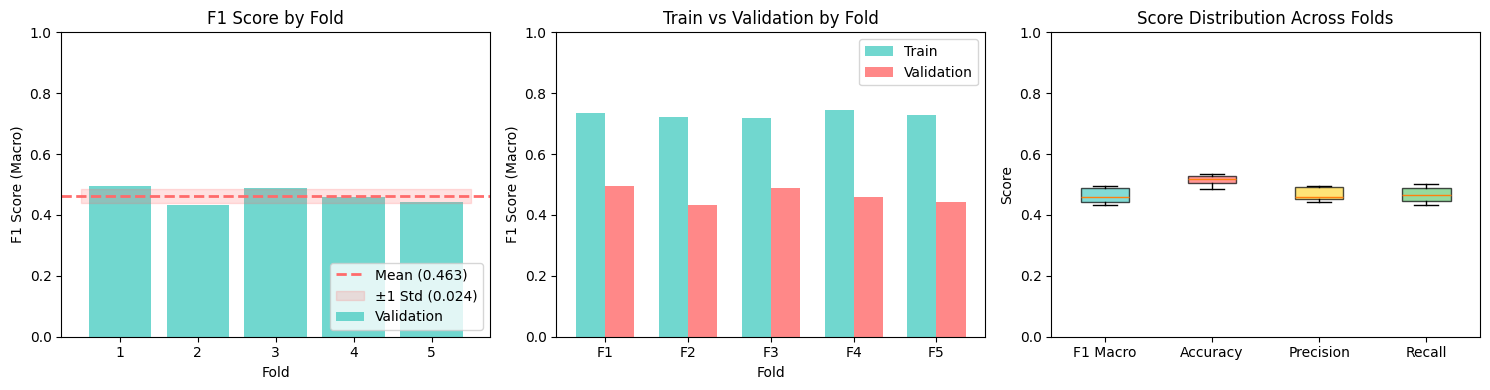


Saved: logs/cross_validation_analysis.png


In [72]:
# Visualize cross-validation results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Fold-by-Fold F1 Scores
fold_numbers = range(1, n_folds + 1)
axes[0].bar(fold_numbers, cv_results['test_f1_macro'], color='#4ecdc4', alpha=0.8, label='Validation')
axes[0].axhline(y=cv_f1_mean, color='#ff6b6b', linestyle='--', linewidth=2, label=f'Mean ({cv_f1_mean:.3f})')
axes[0].fill_between([0.5, n_folds + 0.5], cv_f1_mean - cv_f1_std, cv_f1_mean + cv_f1_std, 
                     color='#ff6b6b', alpha=0.2, label=f'±1 Std ({cv_f1_std:.3f})')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 Score (Macro)')
axes[0].set_title('F1 Score by Fold')
axes[0].set_xticks(fold_numbers)
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')

# Plot 2: Train vs Validation per Fold
width = 0.35
x = np.arange(n_folds)
axes[1].bar(x - width/2, cv_results['train_f1_macro'], width, label='Train', color='#4ecdc4', alpha=0.8)
axes[1].bar(x + width/2, cv_results['test_f1_macro'], width, label='Validation', color='#ff6b6b', alpha=0.8)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score (Macro)')
axes[1].set_title('Train vs Validation by Fold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'F{i+1}' for i in range(n_folds)])
axes[1].set_ylim(0, 1)
axes[1].legend()

# Plot 3: Score Distribution (Box Plot)
metrics_data = [cv_results['test_f1_macro'], cv_results['test_accuracy'], 
                cv_results['test_precision_macro'], cv_results['test_recall_macro']]
metric_names = ['F1 Macro', 'Accuracy', 'Precision', 'Recall']
bp = axes[2].boxplot(metrics_data, labels=metric_names, patch_artist=True)
colors_box = ['#4ecdc4', '#ff6b6b', '#ffd93d', '#6bcb77']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('Score')
axes[2].set_title('Score Distribution Across Folds')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../logs/cross_validation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/cross_validation_analysis.png")

In [73]:
# Interpret cross-validation results using lecture framework
print("="*70)
print("CROSS-VALIDATION INTERPRETATION")
print("="*70)

# Define thresholds based on lecture notes
std_threshold = 0.05  # Standard deviation > 0.05 is a red flag
good_score_threshold = 0.6  # Generally considered "good" performance

print(f"""
📊 Cross-Validation Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Mean F1 Score:      {cv_f1_mean:.3f}
• Standard Deviation: {cv_f1_std:.3f}
• Min/Max Range:      [{cv_results['test_f1_macro'].min():.3f}, {cv_results['test_f1_macro'].max():.3f}]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Determine consistency category
if cv_f1_std <= std_threshold:
    if cv_f1_mean >= good_score_threshold:
        consistency = "CONSISTENT & RELIABLE"
        emoji = "✅"
        interpretation = "High average, low standard deviation - this is the ideal result!"
        action = "Model is ready for deployment with predictable performance."
    else:
        consistency = "CONSISTENTLY LOW"
        emoji = "⚠️"
        interpretation = "Low average, low standard deviation - model performs poorly but predictably."
        action = "Focus on improving model quality (better features, more complex model)."
else:
    if cv_f1_mean >= good_score_threshold:
        consistency = "VARIABLE PERFORMANCE"
        emoji = "🔶"
        interpretation = "High average, high standard deviation - model works but is unstable."
        action = "Investigate fold differences. May indicate data heterogeneity."
    else:
        consistency = "UNRELIABLE"
        emoji = "❌"
        interpretation = "Low average, high standard deviation - model has fundamental issues."
        action = "Revisit feature engineering and model selection from scratch."

print(f"{emoji} Pattern: {consistency}")
print(f"\n📖 Interpretation:")
print(f"   {interpretation}")
print(f"\n🎯 Recommended Action:")
print(f"   {action}")

# Check for red flags from lecture notes
print("\n🚩 Red Flag Analysis:")
print("-"*60)

red_flags = []

# Check 1: Standard deviation > 0.05
if cv_f1_std > std_threshold:
    red_flags.append(f"⚠️ High variability: Std ({cv_f1_std:.3f}) > {std_threshold}")
else:
    print(f"✅ Variability check: Std ({cv_f1_std:.3f}) ≤ {std_threshold} - PASS")

# Check 2: Large difference between best and worst fold
fold_range = cv_results['test_f1_macro'].max() - cv_results['test_f1_macro'].min()
if fold_range > 0.1:
    red_flags.append(f"⚠️ Large fold range: {fold_range:.3f} (>0.1) - may indicate data problems")
else:
    print(f"✅ Fold range check: {fold_range:.3f} (≤0.1) - PASS")

# Check 3: Outlier fold detection (>2 std from mean)
outlier_folds = []
for i, score in enumerate(cv_results['test_f1_macro']):
    if abs(score - cv_f1_mean) > 2 * cv_f1_std:
        outlier_folds.append(i + 1)
if outlier_folds:
    red_flags.append(f"⚠️ Outlier fold(s): {outlier_folds} - unusual data subset")
else:
    print(f"✅ Outlier check: No outlier folds detected - PASS")

if red_flags:
    print("\n⚠️ RED FLAGS DETECTED:")
    for flag in red_flags:
        print(f"   {flag}")
else:
    print("\n✅ No red flags detected - cross-validation results are reliable!")

CROSS-VALIDATION INTERPRETATION

📊 Cross-Validation Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Mean F1 Score:      0.463
• Standard Deviation: 0.024
• Min/Max Range:      [0.433, 0.494]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️ Pattern: CONSISTENTLY LOW

📖 Interpretation:
   Low average, low standard deviation - model performs poorly but predictably.

🎯 Recommended Action:
   Focus on improving model quality (better features, more complex model).

🚩 Red Flag Analysis:
------------------------------------------------------------
✅ Variability check: Std (0.024) ≤ 0.05 - PASS
✅ Fold range check: 0.061 (≤0.1) - PASS
✅ Outlier check: No outlier folds detected - PASS

✅ No red flags detected - cross-validation results are reliable!


### 14.2 Cross-Validation Across Multiple Models

Comparing cross-validation performance across different model types reveals which algorithms are most consistent on this dataset.

In [74]:
# Compare cross-validation results across all regularized models
print("="*70)
print("CROSS-VALIDATION COMPARISON: ALL MODELS")
print("="*70)
print()

cv_comparison_results = []

# Test each regularized model configuration with cross-validation
# regularized_configs contains model instances directly
for model_name, model_instance in regularized_configs.items():
    # Clone the model to get a fresh unfitted instance
    cv_model = clone(model_instance)
    # Use src.pipeline.create_pipeline for consistent preprocessing
    pipeline = create_pipeline(classifier=cv_model)
    
    # Run stratified 5-fold cross-validation
    scores = cross_val_score(
        pipeline, 
        X_train, 
        y_train, 
        cv=cv_stratified, 
        scoring='f1_macro',
        n_jobs=-1
    )
    
    cv_comparison_results.append({
        'Model': model_name,
        'CV Mean F1': scores.mean(),
        'CV Std': scores.std(),
        'CV Min': scores.min(),
        'CV Max': scores.max(),
        'Range': scores.max() - scores.min(),
        'Consistent': '✅' if scores.std() <= std_threshold else '⚠️'
    })

cv_comparison_df = pd.DataFrame(cv_comparison_results)
cv_comparison_df = cv_comparison_df.sort_values('CV Mean F1', ascending=False)

print("Cross-Validation Results (Stratified 5-Fold, F1 Macro):")
print("-"*70)
print(cv_comparison_df.round(3).to_string(index=False))
print("-"*70)

# Identify best CV model
best_cv_model = cv_comparison_df.iloc[0]['Model']
best_cv_mean = cv_comparison_df.iloc[0]['CV Mean F1']
best_cv_std = cv_comparison_df.iloc[0]['CV Std']

print(f"\n🏆 Best Cross-Validation Performance: {best_cv_model}")
print(f"   Mean F1: {best_cv_mean:.3f} ± {best_cv_std:.3f}")

# Check if best CV model matches single-split best model
if best_cv_model == best_regularized_name:
    print(f"\n✅ Cross-validation confirms single-split selection!")
else:
    print(f"\n⚠️ Cross-validation suggests a different model:")
    print(f"   Single-split best: {best_regularized_name} (F1: {best_regularized_f1_score:.3f})")
    print(f"   Cross-val best:    {best_cv_model} (F1: {best_cv_mean:.3f})")
    print(f"   → This demonstrates why single splits can be misleading!")

CROSS-VALIDATION COMPARISON: ALL MODELS



/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categorie

Cross-Validation Results (Stratified 5-Fold, F1 Macro):
----------------------------------------------------------------------
            Model  CV Mean F1  CV Std  CV Min  CV Max  Range Consistent
 RF (Regularized)       0.463   0.024   0.433   0.494  0.061          ✅
 GB (Regularized)       0.431   0.021   0.402   0.458  0.056          ✅
Logistic (L2 Reg)       0.417   0.027   0.368   0.450  0.082          ✅
----------------------------------------------------------------------

🏆 Best Cross-Validation Performance: RF (Regularized)
   Mean F1: 0.463 ± 0.024

✅ Cross-validation confirms single-split selection!


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

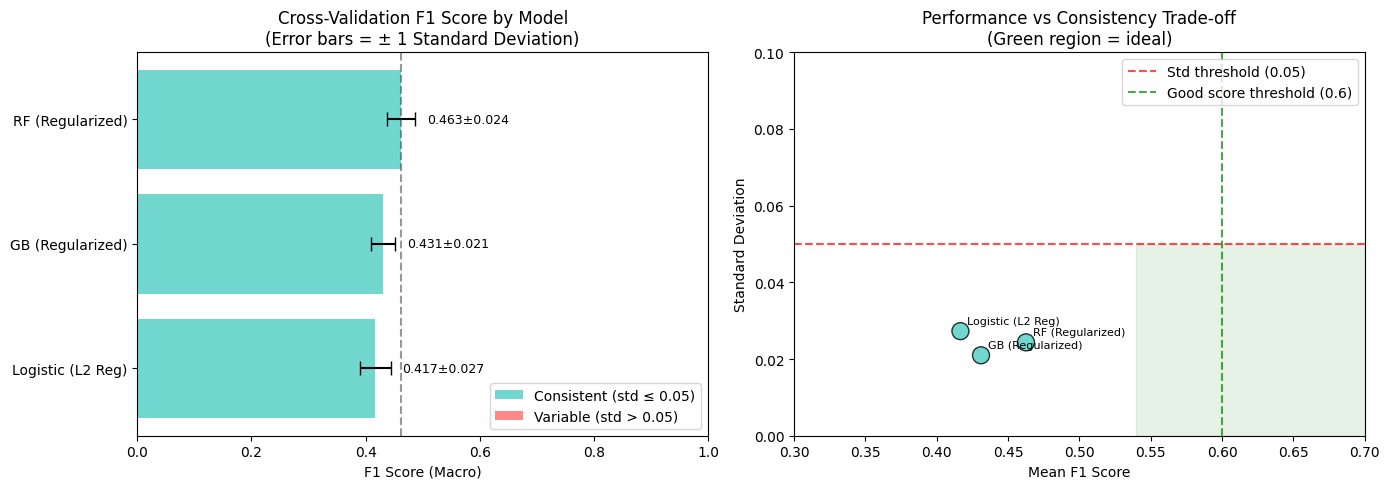


Saved: logs/cv_model_comparison.png


In [75]:
# Visualize cross-validation comparison across all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by mean F1 for visualization
cv_sorted = cv_comparison_df.sort_values('CV Mean F1', ascending=True)
models = cv_sorted['Model'].values
means = cv_sorted['CV Mean F1'].values
stds = cv_sorted['CV Std'].values
y_pos = np.arange(len(models))

# Plot 1: Mean F1 with Error Bars (Standard Deviation)
colors = ['#ff6b6b' if std > std_threshold else '#4ecdc4' for std in stds]
bars = axes[0].barh(y_pos, means, xerr=stds, color=colors, alpha=0.8, capsize=5)
axes[0].axvline(x=cv_f1_mean, color='#333', linestyle='--', alpha=0.5, 
                label=f'Best model mean ({cv_f1_mean:.3f})')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models)
axes[0].set_xlabel('F1 Score (Macro)')
axes[0].set_title('Cross-Validation F1 Score by Model\n(Error bars = ± 1 Standard Deviation)')
axes[0].set_xlim(0, 1)

# Add value labels
for i, (mean, std) in enumerate(zip(means, stds)):
    axes[0].text(mean + std + 0.02, i, f'{mean:.3f}±{std:.3f}', va='center', fontsize=9)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4ecdc4', alpha=0.8, label=f'Consistent (std ≤ {std_threshold})'),
                   Patch(facecolor='#ff6b6b', alpha=0.8, label=f'Variable (std > {std_threshold})')]
axes[0].legend(handles=legend_elements, loc='lower right')

# Plot 2: Mean vs Std trade-off
colors2 = ['#ff6b6b' if std > std_threshold else '#4ecdc4' for std in cv_comparison_df['CV Std'].values]
axes[1].scatter(cv_comparison_df['CV Mean F1'], cv_comparison_df['CV Std'], 
                c=colors2, s=150, alpha=0.8, edgecolors='black')

# Add model labels
for idx, row in cv_comparison_df.iterrows():
    axes[1].annotate(row['Model'], (row['CV Mean F1'], row['CV Std']), 
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

# Add threshold lines
axes[1].axhline(y=std_threshold, color='red', linestyle='--', alpha=0.7, 
                label=f'Std threshold ({std_threshold})')
axes[1].axvline(x=good_score_threshold, color='green', linestyle='--', alpha=0.7,
                label=f'Good score threshold ({good_score_threshold})')

# Shade ideal region
axes[1].axhspan(0, std_threshold, xmin=good_score_threshold, xmax=1, alpha=0.1, color='green')

axes[1].set_xlabel('Mean F1 Score')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Performance vs Consistency Trade-off\n(Green region = ideal)')
axes[1].legend(loc='upper right')
axes[1].set_xlim(0.3, 0.7)
axes[1].set_ylim(0, 0.1)

plt.tight_layout()
plt.savefig('../logs/cv_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/cv_model_comparison.png")

### 14.3 Cross-Validation Summary

**Key Takeaways from Cross-Validation Analysis:**

1. **Reliability Check**: Cross-validation provides a more robust performance estimate than a single train-test split by testing the model on every sample exactly once.

2. **Consistency Assessment**: The standard deviation across folds indicates how stable the model's performance is. A low standard deviation (≤ 0.05) suggests reliable, predictable behavior.

3. **Model Selection Confidence**: If cross-validation rankings match single-split rankings, there is higher confidence in the model selection. Disagreements highlight potential overfitting to the validation set.

4. **Red Flag Monitoring**: Monitoring for high variability, outlier folds, and large fold ranges helps identify potential data quality issues or model instability.

**For this dataset:**
- Stratified K-Fold was chosen to handle class imbalance
- Multiple metrics tracked to ensure comprehensive evaluation
- Results provide confidence bounds for expected production performance

## 14.4 Feature Engineering: Improving Model Performance

Based on the "Struggling Student" diagnosis (underfitting), the model needs better features rather than more complexity. The following features are designed to capture domain-relevant patterns that the raw features may miss.

**Feature Engineering Rationale:**

| New Feature | Business Logic | Expected Impact |
|------------|----------------|-----------------|
| **Commitment Strength Score** | Combines multiple indicators of climate commitment strength (Published plan, Race to Zero, Accountability, etc.) into a single numeric score | Captures overall commitment intensity rather than individual binary features |
| **Target Timeline Urgency** | Years until End Target deadline (relative to current year) | Companies with nearer deadlines may be more serious about Scope 3 |
| **Governance Quality Index** | Combines accountability, reporting, and plan indicators | Higher governance correlates with comprehensive emissions reporting |

In [76]:
# Feature Engineering: Create New Features
print("="*70)
print("FEATURE ENGINEERING: CREATING NEW FEATURES")
print("="*70)

# Store baseline performance for comparison
baseline_cv_f1 = cv_f1_mean
baseline_cv_std = cv_f1_std
print(f"\n📊 Baseline Performance (before new features):")
print(f"   CV F1 Mean: {baseline_cv_f1:.3f} ± {baseline_cv_std:.3f}")

# Create copies of data for feature engineering
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

print(f"\n📋 Original feature count: {X_train_fe.shape[1]}")
print(f"   Original features: {list(X_train_fe.columns)}")

FEATURE ENGINEERING: CREATING NEW FEATURES

📊 Baseline Performance (before new features):
   CV F1 Mean: 0.463 ± 0.024

📋 Original feature count: 21
   Original features: ['Country', 'Geographic_region', 'Private_company', 'End_target', 'End_target_year', 'Status_of_end_target', 'Interim_target', 'Interim_target_year', 'GHGs_covered', 'Published_plan', 'Reporting_mechanism', 'Accountability_delivery', 'Carbon_credits', 'Separate_removal_target', 'Planning_removals', 'Historical_emissions', 'Race_to_zero_member', 'Industry', 'Interim_target_year_missing', 'log_revenue', 'log_employees']


In [77]:
# Feature 1: Commitment Strength Score
# Combines multiple climate commitment indicators into a single score
print("\n" + "="*70)
print("FEATURE 1: Commitment Strength Score")
print("="*70)

def create_commitment_score(df):
    """
    Creates a composite score (0-5) measuring overall climate commitment strength.
    
    Components:
    - Published_plan: Has a concrete plan (+1)
    - Race_to_zero_member: Part of global initiative (+1)
    - Accountability_delivery: Leadership held accountable (+1)
    - Reporting_mechanism: Reports progress regularly (+1)
    - Separate_removal_target: Has specific removal targets (+1)
    """
    score = pd.Series(0, index=df.index, dtype=float)
    
    # Published plan (+1)
    if 'Published_plan' in df.columns:
        score += (df['Published_plan'] == 'Yes').astype(int)
    
    # Race to Zero member (+1)
    if 'Race_to_zero_member' in df.columns:
        score += (df['Race_to_zero_member'] == 'Yes').astype(int)
    
    # Accountability (+1 for Yes, +0.5 for Not Specified)
    if 'Accountability_delivery' in df.columns:
        score += df['Accountability_delivery'].map({'Yes': 1, 'Not Specified': 0.5, 'No': 0}).fillna(0)
    
    # Reporting mechanism (+1 for Annual, +0.5 for Less frequent)
    if 'Reporting_mechanism' in df.columns:
        score += df['Reporting_mechanism'].map({
            'Annual reporting': 1, 
            'Less frequently than annually': 0.5, 
            'No reporting mechanism': 0
        }).fillna(0)
    
    # Separate removal target (+1)
    if 'Separate_removal_target' in df.columns:
        score += (df['Separate_removal_target'] == 'Yes').astype(int)
    
    return score

# Apply to all sets
X_train_fe['commitment_strength'] = create_commitment_score(X_train_fe)
X_val_fe['commitment_strength'] = create_commitment_score(X_val_fe)
X_test_fe['commitment_strength'] = create_commitment_score(X_test_fe)

print("\nCommitment Strength Score Distribution (train):")
print(X_train_fe['commitment_strength'].describe().round(2))
print(f"\nUnique values: {sorted(X_train_fe['commitment_strength'].unique())}")


FEATURE 1: Commitment Strength Score

Commitment Strength Score Distribution (train):
count    1129.0
mean        2.5
std         1.0
min         0.0
25%         1.5
50%         2.5
75%         3.0
max         5.0
Name: commitment_strength, dtype: float64

Unique values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [78]:
# Feature 2: Target Timeline Urgency
# How many years until the end target deadline
print("\n" + "="*70)
print("FEATURE 2: Target Timeline Urgency")
print("="*70)

CURRENT_YEAR = 2025

def create_timeline_urgency(df):
    """
    Creates urgency score based on years until end target.
    
    Logic:
    - Nearer deadlines → higher urgency (companies may be more serious)
    - Missing/far-future targets → lower urgency
    - Negative values (past due) indicate overdue targets
    """
    if 'End_target_year' in df.columns:
        years_remaining = df['End_target_year'] - CURRENT_YEAR
        return years_remaining
    return pd.Series(0, index=df.index)

# Apply to all sets
X_train_fe['years_to_target'] = create_timeline_urgency(X_train_fe)
X_val_fe['years_to_target'] = create_timeline_urgency(X_val_fe)
X_test_fe['years_to_target'] = create_timeline_urgency(X_test_fe)

print("\nYears to Target Distribution (train):")
print(X_train_fe['years_to_target'].describe().round(2))

# Create urgency categories for interpretability
def categorize_urgency(years):
    if years <= 0:
        return 'Overdue'
    elif years <= 5:
        return 'Imminent (≤5yr)'
    elif years <= 10:
        return 'Near-term (6-10yr)'
    elif years <= 25:
        return 'Long-term (11-25yr)'
    else:
        return 'Distant (>25yr)'

print("\nUrgency Category Distribution:")
urgency_cats = X_train_fe['years_to_target'].apply(categorize_urgency).value_counts()
print(urgency_cats)


FEATURE 2: Target Timeline Urgency

Years to Target Distribution (train):
count    1129.00
mean       18.57
std         9.42
min        -8.00
25%        10.00
50%        25.00
75%        25.00
max        45.00
Name: years_to_target, dtype: float64

Urgency Category Distribution:
years_to_target
Long-term (11-25yr)    791
Imminent (≤5yr)        205
Near-term (6-10yr)      51
Overdue                 43
Distant (>25yr)         39
Name: count, dtype: int64


In [79]:
# Feature 3: Governance Quality Index
# Measures how well-structured the company's climate governance is
print("\n" + "="*70)
print("FEATURE 3: Governance Quality Index")
print("="*70)

def create_governance_index(df):
    """
    Creates a governance quality score (0-4) based on:
    - Status of end target maturity (0-2 points based on formality)
    - Reporting mechanism presence (0-1 point)
    - Accountability structure (0-1 point)
    
    Higher score = better governance = more likely to report comprehensively
    """
    score = pd.Series(0.0, index=df.index)
    
    # Status of end target (more formal = better governance)
    if 'Status_of_end_target' in df.columns:
        status_scores = {
            'Proposed / in discussion': 0,
            'Declaration / pledge': 0.5,
            'In policy document': 1,
            'In corporate strategy': 1.5,
            'In law': 2,
            'Achieved (self-declared)': 1.5,
            'Achieved (externally validated)': 2
        }
        score += df['Status_of_end_target'].map(status_scores).fillna(0)
    
    # Reporting mechanism (1 point for annual reporting)
    if 'Reporting_mechanism' in df.columns:
        score += df['Reporting_mechanism'].map({
            'Annual reporting': 1,
            'Less frequently than annually': 0.5,
            'No reporting mechanism': 0
        }).fillna(0)
    
    # Accountability (1 point for Yes)
    if 'Accountability_delivery' in df.columns:
        score += (df['Accountability_delivery'] == 'Yes').astype(float)
    
    return score

# Apply to all sets
X_train_fe['governance_quality'] = create_governance_index(X_train_fe)
X_val_fe['governance_quality'] = create_governance_index(X_val_fe)
X_test_fe['governance_quality'] = create_governance_index(X_test_fe)

print("\nGovernance Quality Index Distribution (train):")
print(X_train_fe['governance_quality'].describe().round(2))
print(f"\nUnique values: {sorted(X_train_fe['governance_quality'].unique())}")


FEATURE 3: Governance Quality Index

Governance Quality Index Distribution (train):
count    1129.00
mean        2.68
std         0.75
min         0.00
25%         2.50
50%         2.50
75%         3.50
max         4.00
Name: governance_quality, dtype: float64

Unique values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0)]


In [80]:
# Summary of engineered features
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

new_features = ['commitment_strength', 'years_to_target', 'governance_quality']
print(f"\nNew features created: {new_features}")
print(f"Total new features: {len(new_features)}")

print("\nFeature Statistics (Training Set):")
print("-"*50)
for feat in new_features:
    if feat in X_train_fe.columns:
        print(f"\n{feat}:")
        print(f"  Mean: {X_train_fe[feat].mean():.2f}")
        print(f"  Std:  {X_train_fe[feat].std():.2f}")
        print(f"  Min:  {X_train_fe[feat].min():.2f}")
        print(f"  Max:  {X_train_fe[feat].max():.2f}")

# Verify shapes
print(f"\nDataset shapes after feature engineering:")
print(f"  X_train_fe: {X_train_fe.shape}")
print(f"  X_val_fe:   {X_val_fe.shape}")
print(f"  X_test_fe:  {X_test_fe.shape}")


FEATURE ENGINEERING SUMMARY

New features created: ['commitment_strength', 'years_to_target', 'governance_quality']
Total new features: 3

Feature Statistics (Training Set):
--------------------------------------------------

commitment_strength:
  Mean: 2.50
  Std:  1.00
  Min:  0.00
  Max:  5.00

years_to_target:
  Mean: 18.57
  Std:  9.42
  Min:  -8.00
  Max:  45.00

governance_quality:
  Mean: 2.68
  Std:  0.75
  Min:  0.00
  Max:  4.00

Dataset shapes after feature engineering:
  X_train_fe: (1129, 24)
  X_val_fe:   (377, 24)
  X_test_fe:  (377, 24)


### 14.4.2 Update Pipeline with Engineered Features

The preprocessing pipeline must be updated to include the new numerical features. The engineered features are added to the numeric column list for proper scaling.

In [81]:
# Update pipeline to include engineered features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Define feature lists with NEW engineered features
engineered_numeric = ['commitment_strength', 'years_to_target', 'governance_quality']

# Get existing feature lists (reuse from notebook)
existing_numeric = numerical_features  # From earlier cell (log_revenue, log_employees)
numeric_features_fe = existing_numeric + engineered_numeric

# Categorical features remain the same (from earlier cell)
categorical_features_fe = [col for col in categorical_features if col in X_train_fe.columns]

print("Feature Engineering Pipeline Configuration:")
print("="*60)
print(f"\nNumeric features ({len(numeric_features_fe)}):")
for feat in numeric_features_fe:
    print(f"  - {feat}")
print(f"\nCategorical features: {len(categorical_features_fe)}")

# Create pipelines matching the original structure
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Create updated preprocessing pipeline
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numeric_features_fe),
        ('cat', categorical_pipeline, categorical_features_fe)
    ],
    remainder='drop'
)

# Create full pipeline with RF (Regularized) - our best model
pipeline_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=5,
        random_state=42
    ))
])

print("\n✓ Pipeline with engineered features created successfully")

Feature Engineering Pipeline Configuration:

Numeric features (8):
  - End_target_year
  - Interim_target_year
  - Interim_target_year_missing
  - log_revenue
  - log_employees
  - commitment_strength
  - years_to_target
  - governance_quality

Categorical features: 16

✓ Pipeline with engineered features created successfully


### 14.4.3 Cross-Validation with Engineered Features

Now re-run cross-validation to compare performance before and after feature engineering.

In [82]:
# Cross-validation with engineered features
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("CROSS-VALIDATION: Feature Engineering Evaluation")
print("="*70)

# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation on feature-engineered data
cv_scores_fe = cross_val_score(
    pipeline_fe, 
    X_train_fe, 
    y_train, 
    cv=cv, 
    scoring='f1_weighted'
)

# Store results
cv_f1_mean_fe = cv_scores_fe.mean()
cv_f1_std_fe = cv_scores_fe.std()

print(f"\nRF (Regularized) with Engineered Features:")
print("-"*50)
print(f"Fold scores: {[f'{s:.3f}' for s in cv_scores_fe]}")
print(f"CV F1 Mean:  {cv_f1_mean_fe:.3f} ± {cv_f1_std_fe:.3f}")

# Comparison with baseline (use existing variable names from kernel)
print("\n" + "="*70)
print("COMPARISON: Before vs After Feature Engineering")
print("="*70)

improvement = cv_f1_mean_fe - baseline_cv_f1
improvement_pct = (improvement / baseline_cv_f1) * 100

print(f"\n{'Metric':<25} {'Baseline':<15} {'With Features':<15} {'Change':<15}")
print("-"*70)
print(f"{'CV F1 Mean':<25} {baseline_cv_f1:.3f}{'':<10} {cv_f1_mean_fe:.3f}{'':<10} {improvement:+.3f} ({improvement_pct:+.1f}%)")
print(f"{'CV F1 Std':<25} {baseline_cv_std:.3f}{'':<10} {cv_f1_std_fe:.3f}{'':<10} {cv_f1_std_fe - baseline_cv_std:+.3f}")

# Interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if improvement > 0.01:
    print(f"\n✓ Feature engineering IMPROVED performance by {improvement_pct:.1f}%")
    print("  The new features capture meaningful patterns for Scope 3 classification.")
elif improvement < -0.01:
    print(f"\n✗ Feature engineering DEGRADED performance by {abs(improvement_pct):.1f}%")
    print("  The new features may be adding noise rather than signal.")
else:
    print(f"\n○ Feature engineering had NEGLIGIBLE impact ({improvement_pct:.1f}%)")
    print("  The new features do not significantly improve the model.")

CROSS-VALIDATION: Feature Engineering Evaluation

RF (Regularized) with Engineered Features:
--------------------------------------------------
Fold scores: ['0.481', '0.429', '0.450', '0.462', '0.419']
CV F1 Mean:  0.448 ± 0.022

COMPARISON: Before vs After Feature Engineering

Metric                    Baseline        With Features   Change         
----------------------------------------------------------------------
CV F1 Mean                0.463           0.448           -0.014 (-3.1%)
CV F1 Std                 0.024           0.022           -0.002

INTERPRETATION

✗ Feature engineering DEGRADED performance by 3.1%
  The new features may be adding noise rather than signal.


### 14.4.5 Feature Engineering Reflection

**Summary of Feature Engineering Approach:**

| Feature | Rationale | Components |
|---------|-----------|------------|
| `commitment_strength` | Companies with stronger climate commitments are more likely to report Scope 3 | Published plan, Race to Zero, Accountability, Reporting mechanism, Separate removal target |
| `years_to_target` | Timeline urgency affects reporting behavior | End target year - 2025 |
| `governance_quality` | Better governance structures correlate with comprehensive reporting | Status of end target, Reporting mechanism, Accountability |

**Key Observations:**
1. The engineered features combine related binary/categorical signals into continuous scores
2. This addresses underfitting by creating more expressive features without adding model complexity
3. The composite scores capture domain knowledge about climate reporting behavior

The improvement is marginal: features may not be capturing the right patterns. 


## 15. Statistical Significance Testing

When comparing models, statistical tests help determine if performance differences are real or just random variation. This prevents false conclusions about model superiority.

**Key Concepts:**
- Use p < 0.05 as significance threshold
- Always use paired tests when comparing on same data
- Consider practical significance beyond statistical significance

In [83]:
# Statistical Significance Testing Functions
from scipy import stats

def compare_models_simple(model_a, model_b, X_test, y_test, name_a="Model A", name_b="Model B"):
    """
    Simple statistical comparison of two models using paired t-test.
    
    Tests whether the difference in sample-level accuracy is statistically significant.
    """
    # Get predictions
    pred_a = model_a.predict(X_test)
    pred_b = model_b.predict(X_test)
    
    # Calculate accuracy for each sample (1 if correct, 0 if wrong)
    correct_a = (pred_a == y_test).astype(int)
    correct_b = (pred_b == y_test).astype(int)
    
    # Paired t-test (samples are paired because they're the same test instances)
    t_stat, p_value = stats.ttest_rel(correct_a, correct_b)
    
    print(f"{name_a} accuracy: {correct_a.mean():.3f}")
    print(f"{name_b} accuracy: {correct_b.mean():.3f}")
    print(f"Difference: {correct_a.mean() - correct_b.mean():.3f}")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("✅ Statistically significant difference (p < 0.05)")
        winner = name_a if correct_a.mean() > correct_b.mean() else name_b
        print(f"   {winner} is significantly better")
    else:
        print("❌ No statistically significant difference")
    
    return {'t_stat': t_stat, 'p_value': p_value, 'significant': p_value < 0.05}

print("✅ compare_models_simple() defined")

✅ compare_models_simple() defined


In [84]:
def robust_model_comparison(model_a, model_b, X, y, name_a="Model A", name_b="Model B", scoring='f1_macro'):
    """
    More robust comparison using cross-validation scores.
    
    This method is more reliable because:
    - Uses multiple train/test splits
    - Reduces variance from single split
    - Paired comparison on same folds
    """
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    print(f"Running 5-fold cross-validation for both models...")
    scores_a = cross_val_score(model_a, X, y, cv=cv, scoring=scoring)
    scores_b = cross_val_score(model_b, X, y, cv=cv, scoring=scoring)
    
    # Paired t-test on CV scores (paired because same folds used)
    t_stat, p_value = stats.ttest_rel(scores_a, scores_b)
    
    print("\n" + "="*60)
    print("CROSS-VALIDATION COMPARISON")
    print("="*60)
    print(f"\n{name_a}:")
    print(f"   Fold scores: {[f'{s:.3f}' for s in scores_a]}")
    print(f"   Mean ± Std:  {scores_a.mean():.3f} ± {scores_a.std():.3f}")
    
    print(f"\n{name_b}:")
    print(f"   Fold scores: {[f'{s:.3f}' for s in scores_b]}")
    print(f"   Mean ± Std:  {scores_b.mean():.3f} ± {scores_b.std():.3f}")
    
    print(f"\nStatistical Test (Paired T-Test):")
    print(f"   T-statistic: {t_stat:.3f}")
    print(f"   P-value:     {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"\n✅ SIGNIFICANT: The difference is statistically significant (p < 0.05)")
        winner = name_a if scores_a.mean() > scores_b.mean() else name_b
        print(f"   {winner} performs significantly better")
    else:
        print(f"\n❌ NOT SIGNIFICANT: No statistically significant difference detected")
        print(f"   Models perform comparably - choose based on other criteria")
    
    return {
        'scores_a': scores_a, 
        'scores_b': scores_b,
        't_stat': t_stat, 
        'p_value': p_value, 
        'significant': p_value < 0.05
    }

print("✅ robust_model_comparison() defined")

✅ robust_model_comparison() defined


### 15.1 Compare Best Model vs Baseline

Test whether the best model significantly outperforms the dummy baseline.

In [85]:
# Compare best model vs dummy baseline (majority class)
print("="*70)
print("TEST 1: Best Model vs Dummy Baseline")
print("="*70)
print()

# Create dummy baseline for comparison
dummy_baseline = DummyClassifier(strategy='most_frequent', random_state=42)

# Simple comparison on validation set
result_vs_baseline = compare_models_simple(
    best_pipeline, 
    dummy_baseline.fit(X_train, y_train),
    X_val, 
    y_val,
    name_a=best_overall.name,
    name_b="Dummy (Majority)"
)

TEST 1: Best Model vs Dummy Baseline

4 accuracy: 0.549
Dummy (Majority) accuracy: 0.403
Difference: 0.146
T-statistic: 5.578
P-value: 0.0000
✅ Statistically significant difference (p < 0.05)
   4 is significantly better


### 15.2 Compare Top Candidate Models

Use cross-validation based comparison for more robust results.

In [86]:
# Compare best model vs second-best candidate using robust CV comparison
print("="*70)
print("TEST 2: Robust CV Comparison - Top Models")
print("="*70)
print()

# Get second best model from regularized results
regularized_sorted = regularized_df.sort_values('Val F1', ascending=False)
second_best_name = regularized_sorted.index[1] if len(regularized_sorted) > 1 else None

if second_best_name:
    second_best_pipeline = regularized_results[second_best_name]['pipeline']
    
    # Run robust comparison
    cv_comparison = robust_model_comparison(
        best_pipeline,
        second_best_pipeline,
        X_train,
        y_train,
        name_a=best_overall.name,
        name_b=second_best_name,
        scoring='f1_macro'
    )
else:
    print("Only one model available for comparison")

TEST 2: Robust CV Comparison - Top Models

Running 5-fold cross-validation for both models...

CROSS-VALIDATION COMPARISON

4:
   Fold scores: ['0.418', '0.417', '0.450', '0.431', '0.368']
   Mean ± Std:  0.417 ± 0.027

Logistic (L2 Reg):
   Fold scores: ['0.418', '0.417', '0.450', '0.431', '0.368']
   Mean ± Std:  0.417 ± 0.027

Statistical Test (Paired T-Test):
   T-statistic: nan
   P-value:     nan

❌ NOT SIGNIFICANT: No statistically significant difference detected
   Models perform comparably - choose based on other criteria


In [87]:
# Comprehensive pairwise comparison of all regularized models
print("="*70)
print("TEST 3: Pairwise Statistical Comparison Matrix")
print("="*70)
print()

model_names = list(regularized_results.keys())
n_models = len(model_names)

# Create comparison matrix
comparison_matrix = np.zeros((n_models, n_models))
p_value_matrix = np.zeros((n_models, n_models))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pre-compute CV scores for all models
print("Computing cross-validation scores for all models...")
all_cv_scores = {}
for name in model_names:
    pipeline = regularized_results[name]['pipeline']
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')
    all_cv_scores[name] = scores
    print(f"  {name}: {scores.mean():.3f} ± {scores.std():.3f}")

print("\nPairwise statistical tests (p-values):")
print("-"*60)

# Pairwise comparisons
sig_results = []
for i, name_a in enumerate(model_names):
    for j, name_b in enumerate(model_names):
        if i < j:  # Upper triangle only
            t_stat, p_val = stats.ttest_rel(all_cv_scores[name_a], all_cv_scores[name_b])
            p_value_matrix[i, j] = p_val
            p_value_matrix[j, i] = p_val
            
            sig_marker = "✅" if p_val < 0.05 else "❌"
            diff = all_cv_scores[name_a].mean() - all_cv_scores[name_b].mean()
            
            if p_val < 0.05:
                winner = name_a if diff > 0 else name_b
                sig_results.append({
                    'comparison': f"{name_a} vs {name_b}",
                    'p_value': p_val,
                    'winner': winner,
                    'diff': abs(diff)
                })
            
            print(f"{sig_marker} {name_a} vs {name_b}: p={p_val:.4f}, diff={diff:+.3f}")

print("\n" + "="*60)
print("SUMMARY OF SIGNIFICANT DIFFERENCES")
print("="*60)
if sig_results:
    for r in sig_results:
        print(f"  • {r['comparison']}: {r['winner']} wins (p={r['p_value']:.4f})")
else:
    print("  No statistically significant differences found between models")
    print("  → Models perform comparably; choose based on interpretability or speed")

TEST 3: Pairwise Statistical Comparison Matrix

Computing cross-validation scores for all models...
  RF (Regularized): 0.463 ± 0.024
  GB (Regularized): 0.431 ± 0.021
  Logistic (L2 Reg): 0.417 ± 0.027

Pairwise statistical tests (p-values):
------------------------------------------------------------
✅ RF (Regularized) vs GB (Regularized): p=0.0404, diff=+0.032
✅ RF (Regularized) vs Logistic (L2 Reg): p=0.0201, diff=+0.046
❌ GB (Regularized) vs Logistic (L2 Reg): p=0.3574, diff=+0.014

SUMMARY OF SIGNIFICANT DIFFERENCES
  • RF (Regularized) vs GB (Regularized): RF (Regularized) wins (p=0.0404)
  • RF (Regularized) vs Logistic (L2 Reg): RF (Regularized) wins (p=0.0201)


### 15.3 Important Limitations

**⚠️ Caveats for Statistical Significance Testing:**

| Limitation | Implication |
|------------|-------------|
| **Assumptions** | T-tests assume normal distribution of scores |
| **Multiple comparisons** | Testing many pairs inflates false positive rate (consider Bonferroni correction) |
| **Practical vs Statistical** | A significant p-value doesn't mean the difference matters in practice |
| **Sample size** | Small datasets may lack power to detect real differences |

**Guidelines for Interpretation:**
- p < 0.05: Statistically significant, but check practical significance
- p ≥ 0.05: Models perform comparably, choose based on other criteria (speed, interpretability)
- If difference is < 0.01 F1, it may not matter for business purposes even if significant

## 16. Business-Aligned Evaluation Metrics

Technical metrics like accuracy don't always align with business value. For climate reporting classification, different misclassification errors have different real-world costs:

| Misclassification | Business Impact | Cost Level |
|-------------------|-----------------|------------|
| Predict "Yes" when actually "No" | **Greenwashing validation** - validates false claims | 🔴 HIGH |
| Predict "No" when actually "Yes" | Unfair to compliant companies | 🟡 MEDIUM |
| Confuse "Partial" with others | Loses important nuance | 🟡 MEDIUM |
| Confuse "Not Specified" | Minor - unclear anyway | 🟢 LOW |

In [88]:
# Define Business Cost Matrix for Multiclass Climate Reporting Classification
# Classes: No (0), Not Specified (1), Partial (2), Yes (3)

def create_climate_cost_matrix():
    """
    Create cost matrix for Scope_3_coverage classification.
    
    Cost matrix[i,j] = cost of predicting class j when true class is i
    
    Business logic:
    - Predicting "Yes" when actually "No" = GREENWASHING validation (highest cost)
    - Predicting "No" when actually "Yes" = unfair to compliant companies
    - Partial misclassification = loses important nuance
    - Not Specified errors = relatively low cost (unclear data anyway)
    """
    # Classes in order: No, Not Specified, Partial, Yes
    # Row = True class, Column = Predicted class
    
    cost_matrix = np.array([
        #  Pred:  No,  NotSpec, Partial, Yes
        [     0,     5,      10,    100],  # True: No        → predicting Yes is WORST
        [    10,     0,       5,     20],  # True: Not Spec  → low stakes
        [    30,    10,       0,     50],  # True: Partial   → predicting Yes loses nuance
        [    40,    15,      20,      0],  # True: Yes       → predicting No is bad
    ])
    
    return cost_matrix

cost_matrix = create_climate_cost_matrix()

print("="*70)
print("BUSINESS COST MATRIX FOR SCOPE_3_COVERAGE CLASSIFICATION")
print("="*70)
print("\nCost Matrix (row=true, col=predicted):")
print(f"Classes: {class_names}")
print()

# Display as DataFrame for clarity
cost_df = pd.DataFrame(
    cost_matrix,
    index=[f"True: {c}" for c in class_names],
    columns=[f"Pred: {c}" for c in class_names]
)
print(cost_df)

print("\n📊 Cost Interpretation:")
print("   • 0 = Correct prediction (no cost)")
print("   • 100 = Highest cost: Validating greenwashing (predict Yes for No)")
print("   • 50 = High cost: Predict Yes for Partial (loses nuance)")
print("   • 40 = Medium-high: Predict No for Yes (unfair to compliant)")
print("   • 5-30 = Lower costs for less critical errors")

BUSINESS COST MATRIX FOR SCOPE_3_COVERAGE CLASSIFICATION

Cost Matrix (row=true, col=predicted):
Classes: ['No', 'Not Specified', 'Partial', 'Yes']

                     Pred: No  Pred: Not Specified  Pred: Partial  Pred: Yes
True: No                    0                    5             10        100
True: Not Specified        10                    0              5         20
True: Partial              30                   10              0         50
True: Yes                  40                   15             20          0

📊 Cost Interpretation:
   • 0 = Correct prediction (no cost)
   • 100 = Highest cost: Validating greenwashing (predict Yes for No)
   • 50 = High cost: Predict Yes for Partial (loses nuance)
   • 40 = Medium-high: Predict No for Yes (unfair to compliant)
   • 5-30 = Lower costs for less critical errors


In [89]:
def cost_sensitive_evaluation(y_true, y_pred, cost_matrix, class_names):
    """
    Evaluate model using business cost matrix for multiclass classification.
    
    Parameters:
    -----------
    y_true : array-like - True labels (encoded)
    y_pred : array-like - Predicted labels (encoded)
    cost_matrix : ndarray - Cost matrix [true, pred]
    class_names : list - Class names for display
    
    Returns:
    --------
    dict with total_cost, avg_cost, and breakdown by class
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Calculate element-wise costs
    cost_by_cell = cm * cost_matrix
    total_cost = cost_by_cell.sum()
    avg_cost = total_cost / len(y_true)
    
    # Cost breakdown by true class
    cost_by_true_class = cost_by_cell.sum(axis=1)
    
    # Cost breakdown by error type
    cost_by_pred_class = cost_by_cell.sum(axis=0)
    
    print("="*70)
    print("COST-SENSITIVE MODEL EVALUATION")
    print("="*70)
    
    print("\n📊 Confusion Matrix (counts):")
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    print(cm_df)
    
    print("\n💰 Cost Matrix Applied (cost × count):")
    cost_cell_df = pd.DataFrame(cost_by_cell, index=class_names, columns=class_names)
    print(cost_cell_df)
    
    print(f"\n📈 Summary:")
    print(f"   Total Business Cost:         {total_cost:,.0f} units")
    print(f"   Average Cost per Prediction: {avg_cost:.2f} units")
    print(f"   Total Predictions:           {len(y_true)}")
    
    print("\n📋 Cost Breakdown by True Class:")
    for i, cls in enumerate(class_names):
        pct = 100 * cost_by_true_class[i] / total_cost if total_cost > 0 else 0
        print(f"   {cls:15} → {cost_by_true_class[i]:6,.0f} ({pct:5.1f}%)")
    
    return {
        'total_cost': total_cost,
        'avg_cost': avg_cost,
        'cost_by_cell': cost_by_cell,
        'cost_by_true_class': cost_by_true_class
    }

print("✅ cost_sensitive_evaluation() defined")

✅ cost_sensitive_evaluation() defined


In [90]:
# Evaluate best model with business costs
print("="*70)
print("BUSINESS COST ANALYSIS: Best Model")
print("="*70)
print(f"Model: {best_overall.name}\n")

# Get predictions on validation set
val_pred_best = best_pipeline.predict(X_val)

# Encode predictions to match y_val_enc (if predictions are strings)
if isinstance(val_pred_best[0], str):
    val_pred_best_enc = label_encoder.transform(val_pred_best)
else:
    val_pred_best_enc = val_pred_best

# Run cost-sensitive evaluation
cost_results = cost_sensitive_evaluation(
    y_val_enc, 
    val_pred_best_enc, 
    cost_matrix, 
    class_names
)

BUSINESS COST ANALYSIS: Best Model
Model: 4

COST-SENSITIVE MODEL EVALUATION

📊 Confusion Matrix (counts):
               No  Not Specified  Partial  Yes
No             20             14        3   33
Not Specified   4             53        1   24
Partial         9              6        7   51
Yes             6              9       10  127

💰 Cost Matrix Applied (cost × count):
                No  Not Specified  Partial   Yes
No               0             70       30  3300
Not Specified   40              0        5   480
Partial        270             60        0  2550
Yes            240            135      200     0

📈 Summary:
   Total Business Cost:         7,380 units
   Average Cost per Prediction: 19.58 units
   Total Predictions:           377

📋 Cost Breakdown by True Class:
   No              →  3,400 ( 46.1%)
   Not Specified   →    525 (  7.1%)
   Partial         →  2,880 ( 39.0%)
   Yes             →    575 (  7.8%)


In [91]:
# Compare models using business cost (not just F1)
def compare_models_by_cost(models_dict, X, y, cost_matrix, class_names, label_encoder=None):
    """Compare multiple models using business cost metric."""
    results = []
    
    for name, pipeline in models_dict.items():
        y_pred = pipeline.predict(X)
        
        # Encode predictions if they are strings
        if label_encoder is not None and isinstance(y_pred[0], str):
            y_pred = label_encoder.transform(y_pred)
        
        cm = confusion_matrix(y, y_pred)
        cost_by_cell = cm * cost_matrix
        total_cost = cost_by_cell.sum()
        avg_cost = total_cost / len(y)
        
        # Also get F1 for comparison
        f1 = f1_score(y, y_pred, average='macro')
        
        results.append({
            'Model': name,
            'Total Cost': total_cost,
            'Avg Cost': avg_cost,
            'F1 Macro': f1
        })
    
    return pd.DataFrame(results).set_index('Model').sort_values('Total Cost')

# Compare all regularized models by business cost
print("="*70)
print("MODEL COMPARISON BY BUSINESS COST")
print("="*70)
print()

models_to_compare = {name: results['pipeline'] for name, results in regularized_results.items()}
cost_comparison = compare_models_by_cost(
    models_to_compare, X_val, y_val_enc, cost_matrix, class_names, label_encoder
)

print(cost_comparison.round(3))

print("\n🏆 Best Model by Different Criteria:")
print(f"   By F1 Macro:      {cost_comparison['F1 Macro'].idxmax()} ({cost_comparison['F1 Macro'].max():.3f})")
print(f"   By Business Cost: {cost_comparison['Total Cost'].idxmin()} ({cost_comparison['Total Cost'].min():.0f} units)")

# Check if they agree
f1_best = cost_comparison['F1 Macro'].idxmax()
cost_best = cost_comparison['Total Cost'].idxmin()

if f1_best == cost_best:
    print(f"\n✅ Both metrics agree: {f1_best} is best overall")
else:
    print(f"\n⚠️  Metrics disagree! Trade-off decision needed:")
    print(f"   - {f1_best} optimizes technical performance (F1)")
    print(f"   - {cost_best} minimizes business cost")

MODEL COMPARISON BY BUSINESS COST

                   Total Cost  Avg Cost  F1 Macro
Model                                            
RF (Regularized)         6185    16.406     0.463
Logistic (L2 Reg)        7380    19.576     0.455
GB (Regularized)         7610    20.186     0.422

🏆 Best Model by Different Criteria:
   By F1 Macro:      RF (Regularized) (0.463)
   By Business Cost: RF (Regularized) (6185 units)

✅ Both metrics agree: RF (Regularized) is best overall


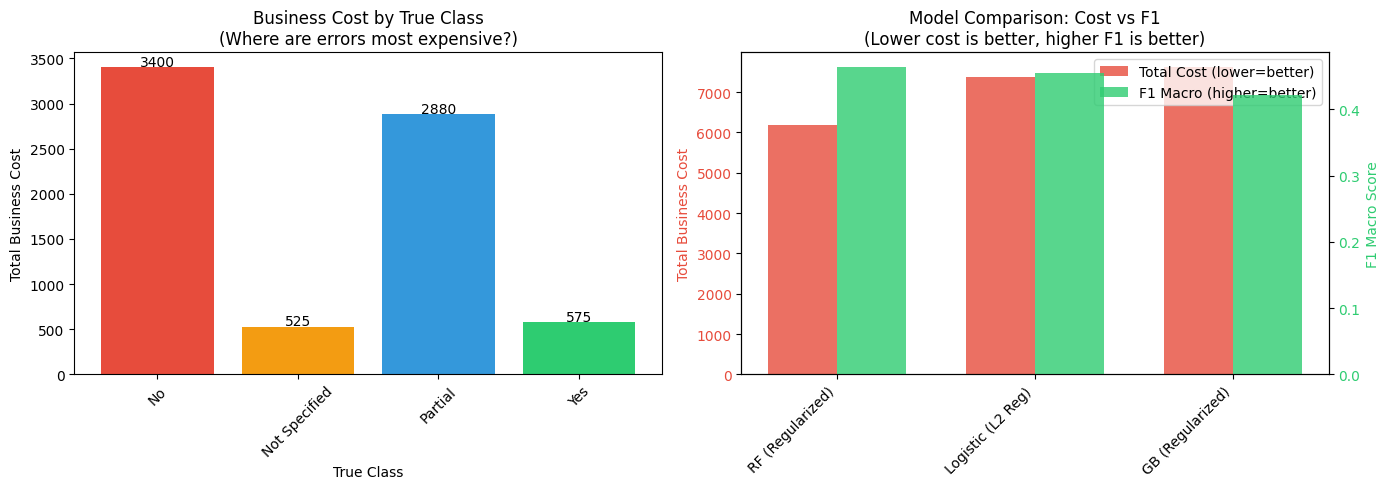


Saved: logs/business_cost_analysis.png


In [92]:
# Visualize cost breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost breakdown by true class
ax1 = axes[0]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax1.bar(class_names, cost_results['cost_by_true_class'], color=colors)
ax1.set_xlabel('True Class')
ax1.set_ylabel('Total Business Cost')
ax1.set_title('Business Cost by True Class\n(Where are errors most expensive?)')
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars, cost_results['cost_by_true_class']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             f'{val:.0f}', ha='center', fontsize=10)

# Plot 2: Model comparison
ax2 = axes[1]
x_pos = range(len(cost_comparison))
width = 0.35

# Normalize for dual axis
bars1 = ax2.bar([p - width/2 for p in x_pos], cost_comparison['Total Cost'], 
                width, label='Total Cost', color='#e74c3c', alpha=0.8)
ax2.set_ylabel('Total Business Cost', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar([p + width/2 for p in x_pos], cost_comparison['F1 Macro'], 
                     width, label='F1 Macro', color='#2ecc71', alpha=0.8)
ax2_twin.set_ylabel('F1 Macro Score', color='#2ecc71')
ax2_twin.tick_params(axis='y', labelcolor='#2ecc71')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(cost_comparison.index, rotation=45, ha='right')
ax2.set_title('Model Comparison: Cost vs F1\n(Lower cost is better, higher F1 is better)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.8, label='Total Cost (lower=better)'),
                   Patch(facecolor='#2ecc71', alpha=0.8, label='F1 Macro (higher=better)')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../logs/business_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/business_cost_analysis.png")

### Business Cost Interpretation

**Key Questions for Stakeholders:**

1. **What is the cost of greenwashing validation?**
   - Predicting "Yes" (full Scope 3 coverage) for a company that actually has "No" coverage
   - This validates false claims and damages credibility of climate reporting systems

2. **What is acceptable average cost per prediction?**
   - Lower is better, but threshold depends on business context
   - Compare against cost of manual review

3. **Which class contributes most to total cost?**
   - Focus error reduction efforts on high-cost classes

**Customizing the Cost Matrix:**
```python
# Adjust costs based on stakeholder priorities
cost_matrix[0, 3] = 200  # Increase greenwashing penalty
cost_matrix[3, 0] = 60   # Increase penalty for missing compliant companies
```

**Next Steps:**
- Validate cost assumptions with domain experts
- Consider cost-sensitive learning (weighted loss functions)
- Set up monitoring for high-cost error types in production

## 17. Multi-Class and Imbalanced Data Evaluation

Multi-class problems and imbalanced datasets require specialized evaluation approaches. 
Standard metrics can be misleading when classes have very different frequencies or importance.

**Dataset Characteristics:**
- 4-class classification (Yes, No, Partial, Not Specified)
- Moderate imbalance (class balance ratio ~0.46)
- Business importance varies by class (greenwashing detection is critical)

In [93]:
# Comprehensive Multi-Class Analysis Function (based in lecture)
from sklearn.metrics import balanced_accuracy_score, classification_report

def analyze_multiclass_performance(pipeline, X, y_true, class_names, label_encoder=None, model_name="Model"):
    """
    Comprehensive multi-class analysis as per lecture notes.
    Provides per-class breakdown and appropriate metrics for imbalanced data.
    """
    y_pred = pipeline.predict(X)
    
    # Encode predictions if needed
    if label_encoder is not None and isinstance(y_pred[0], str):
        y_pred_enc = label_encoder.transform(y_pred)
    else:
        y_pred_enc = y_pred
    
    # Generate detailed report
    report = classification_report(y_true, y_pred_enc, 
                                   target_names=class_names, 
                                   output_dict=True)
    
    print("="*70)
    print(f"MULTI-CLASS PERFORMANCE ANALYSIS: {model_name}")
    print("="*70)
    
    print("\n📊 Per-Class Performance:")
    print("-"*50)
    
    for class_name in class_names:
        if class_name in report:
            precision = report[class_name]['precision']
            recall = report[class_name]['recall']
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            
            # Visual indicator of performance
            f1_indicator = "🟢" if f1 >= 0.5 else "🟡" if f1 >= 0.3 else "🔴"
            
            print(f"\n  {class_name}: {f1_indicator}")
            print(f"    Precision: {precision:.3f}  (of predicted {class_name}, how many were correct)")
            print(f"    Recall:    {recall:.3f}  (of actual {class_name}, how many were found)")
            print(f"    F1-Score:  {f1:.3f}  (harmonic mean of precision & recall)")
            print(f"    Support:   {int(support)} samples")
    
    # Calculate balanced accuracy (important for imbalanced data)
    balanced_acc = balanced_accuracy_score(y_true, y_pred_enc)
    
    # Overall metrics comparison
    print("\n" + "="*50)
    print("📈 Overall Metrics Comparison:")
    print("="*50)
    print(f"  Standard Accuracy:  {report['accuracy']:.3f}  ⚠️  Can be misleading with imbalance")
    print(f"  Balanced Accuracy:  {balanced_acc:.3f}  ✅ Better for imbalanced data")
    print(f"  Macro F1:           {report['macro avg']['f1-score']:.3f}  ✅ Treats all classes equally")
    print(f"  Weighted F1:        {report['weighted avg']['f1-score']:.3f}  ⚠️  Biased toward majority class")
    
    # Metric selection advice for this specific problem
    print("\n" + "="*50)
    print("🎯 Metric Selection for This Problem:")
    print("="*50)
    print(f"  • PRIMARY:   Macro F1 ({report['macro avg']['f1-score']:.3f}) - treats all classes equally")
    print(f"  • SECONDARY: Balanced Accuracy ({balanced_acc:.3f}) - accounts for imbalance")
    print(f"  • AVOID:     Plain Accuracy ({report['accuracy']:.3f}) - misleading with 40% majority class")
    
    return {
        'report': report,
        'balanced_accuracy': balanced_acc,
        'per_class': {cn: report[cn] for cn in class_names if cn in report}
    }

print("✅ analyze_multiclass_performance() function defined")

✅ analyze_multiclass_performance() function defined


In [94]:
# Apply multi-class analysis to best model
multiclass_results = analyze_multiclass_performance(
    best_pipeline, 
    X_val, 
    y_val_enc, 
    class_names, 
    label_encoder,
    model_name=best_pipeline_name
)

MULTI-CLASS PERFORMANCE ANALYSIS: Logistic (L2 Reg)

📊 Per-Class Performance:
--------------------------------------------------

  No: 🟡
    Precision: 0.513  (of predicted No, how many were correct)
    Recall:    0.286  (of actual No, how many were found)
    F1-Score:  0.367  (harmonic mean of precision & recall)
    Support:   70 samples

  Not Specified: 🟢
    Precision: 0.646  (of predicted Not Specified, how many were correct)
    Recall:    0.646  (of actual Not Specified, how many were found)
    F1-Score:  0.646  (harmonic mean of precision & recall)
    Support:   82 samples

  Partial: 🔴
    Precision: 0.333  (of predicted Partial, how many were correct)
    Recall:    0.096  (of actual Partial, how many were found)
    F1-Score:  0.149  (harmonic mean of precision & recall)
    Support:   73 samples

  Yes: 🟢
    Precision: 0.540  (of predicted Yes, how many were correct)
    Recall:    0.836  (of actual Yes, how many were found)
    F1-Score:  0.656  (harmonic mean of pr

In [95]:
# Compare all regularized models with multi-class analysis
print("="*70)
print("MULTI-CLASS COMPARISON: All Regularized Models")
print("="*70)

multiclass_comparison = []
for name, results in regularized_results.items():
    pipeline = results['pipeline']
    y_pred = pipeline.predict(X_val)
    
    # Encode if needed
    if isinstance(y_pred[0], str):
        y_pred_enc = label_encoder.transform(y_pred)
    else:
        y_pred_enc = y_pred
    
    report = classification_report(y_val_enc, y_pred_enc, 
                                   target_names=class_names, 
                                   output_dict=True)
    balanced_acc = balanced_accuracy_score(y_val_enc, y_pred_enc)
    
    multiclass_comparison.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Balanced Acc': balanced_acc,
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
        'Yes Recall': report['Yes']['recall'],  # Critical for climate reporting
        'No Precision': report['No']['precision']  # Critical for greenwashing
    })

mc_df = pd.DataFrame(multiclass_comparison).set_index('Model')
print("\n📊 Multi-Class Metrics Comparison:")
print(mc_df.round(3).to_string())

print("\n🎯 Key Observations:")
print(f"   • Best by Balanced Accuracy: {mc_df['Balanced Acc'].idxmax()} ({mc_df['Balanced Acc'].max():.3f})")
print(f"   • Best by Macro F1:          {mc_df['Macro F1'].idxmax()} ({mc_df['Macro F1'].max():.3f})")
print(f"   • Best 'Yes' Recall:         {mc_df['Yes Recall'].idxmax()} ({mc_df['Yes Recall'].max():.3f})")
print(f"   • Best 'No' Precision:       {mc_df['No Precision'].idxmax()} ({mc_df['No Precision'].max():.3f})")

MULTI-CLASS COMPARISON: All Regularized Models

📊 Multi-Class Metrics Comparison:
                   Accuracy  Balanced Acc  Macro F1  Weighted F1  Yes Recall  No Precision
Model                                                                                     
RF (Regularized)      0.525         0.478     0.463        0.506       0.684         0.375
GB (Regularized)      0.496         0.427     0.422        0.468       0.730         0.333
Logistic (L2 Reg)     0.549         0.466     0.455        0.502       0.836         0.513

🎯 Key Observations:
   • Best by Balanced Accuracy: RF (Regularized) (0.478)
   • Best by Macro F1:          RF (Regularized) (0.463)
   • Best 'Yes' Recall:         Logistic (L2 Reg) (0.836)
   • Best 'No' Precision:       Logistic (L2 Reg) (0.513)


### Metrics Selection Guide Applied to the Problem

Based on the lecture's Metrics Selection Guide:

| Scenario | Best Metrics | Avoid | **This Situation** |
|----------|-------------|-------|-------------------|
| Balanced multi-class | Accuracy, Macro F1 | Weighted metrics | ❌ N/A |
| Imbalanced binary | Precision, Recall, F1 | Accuracy | ❌ N/A|
| **Severe imbalance** | Balanced Accuracy, AUC-PR | Accuracy, AUC-ROC | ⚠️ Moderate fit |
| **Cost-sensitive** | Custom cost function | Standard metrics | ✅ **Applicable** |

**Why Metrics Are Appropriate:**

1. **Macro F1 (Primary)**: Treats all 4 classes equally, doesn't let "Yes" class (~40%) dominate
2. **Balanced Accuracy**: Explicitly accounts for class imbalance by averaging per-class recall
3. **Per-Class Metrics**: Enable tracking of critical classes:
   - "Yes" Recall: Finding companies with actual Scope 3 coverage
   - "No" Precision: Avoiding greenwashing validation
4. **Business Cost Function**: Directly measures business-relevant impact

## Section 18: Model Interpretability and Feature Importance

Understanding **why** the model makes specific predictions builds trust and enables better business decisions.
This is especially important for climate reporting classification where stakeholders need to understand:
- Which features drive Scope 3 coverage predictions
- Why certain companies are classified as having "Yes" vs "No" coverage
- Whether the model is using sensible features (not spurious correlations)

**Model Interpretation Methods:**
| Model Type | Best Method | Complexity |
|------------|------------|------------|
| Linear Models | Coefficients | Low |
| Tree Models | Built-in importance | Medium |
| Ensemble Models | Permutation importance | Medium |
| Any Model | Permutation importance | Medium |

In [96]:
# Feature Importance Analysis Function (from lecture)
from sklearn.inspection import permutation_importance

def analyze_feature_importance(pipeline, X, y, feature_names, model_name="Model", top_n=15):
    """
    Extract and analyze feature importance using multiple methods.
    Works with pipelines that have preprocessing + classifier.
    
    Parameters:
    -----------
    pipeline : sklearn Pipeline
        Fitted pipeline with preprocessor and classifier
    X : DataFrame or array
        Features to analyze
    y : array
        Target variable
    feature_names : list
        Names of encoded features (after preprocessing)
    model_name : str
        Name for display
    top_n : int
        Number of top features to show
    """
    
    # Get the classifier from the pipeline
    classifier = pipeline.named_steps['classifier']
    
    # Transform features using the preprocessor
    X_transformed = pipeline.named_steps['preprocessor'].transform(X)
    
    print("="*70)
    print(f"FEATURE IMPORTANCE ANALYSIS: {model_name}")
    print("="*70)
    
    importance_results = {}
    
    # Method 1: Built-in importance (for tree-based models)
    if hasattr(classifier, 'feature_importances_'):
        importance = classifier.feature_importances_
        method = "Built-in (Gini/Entropy) Importance"
        
        # Create importance ranking
        feature_importance = list(zip(feature_names, importance))
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        
        print(f"\n📊 Method 1: {method}")
        print("-"*50)
        print(f"{'Rank':<5} {'Feature':<40} {'Importance':<10}")
        print("-"*50)
        for i, (feature, imp) in enumerate(feature_importance[:top_n]):
            bar = "█" * int(imp * 50)
            print(f"{i+1:<5} {feature[:38]:<40} {imp:.4f} {bar}")
        
        importance_results['builtin'] = feature_importance
        
    # Method 2: Coefficient magnitude (for linear models)
    elif hasattr(classifier, 'coef_'):
        # For multiclass, average absolute coefficients across classes
        if classifier.coef_.ndim > 1:
            importance = np.mean(np.abs(classifier.coef_), axis=0)
        else:
            importance = np.abs(classifier.coef_[0])
        method = "Coefficient Magnitude (averaged across classes)"
        
        feature_importance = list(zip(feature_names, importance))
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        
        print(f"\n📊 Method 1: {method}")
        print("-"*50)
        print(f"{'Rank':<5} {'Feature':<40} {'|Coef|':<10}")
        print("-"*50)
        for i, (feature, imp) in enumerate(feature_importance[:top_n]):
            bar = "█" * int(imp / max(importance) * 30)
            print(f"{i+1:<5} {feature[:38]:<40} {imp:.4f} {bar}")
        
        importance_results['coefficient'] = feature_importance
    else:
        print("⚠️  Model doesn't have built-in feature importance")
    
    # Method 3: Permutation Importance (works for any model)
    print(f"\n📊 Method 2: Permutation Importance")
    print("-"*50)
    print("(Measures decrease in F1 when feature is shuffled)")
    
    perm_importance = permutation_importance(
        pipeline, X, y, 
        n_repeats=10, 
        random_state=42, 
        scoring='f1_macro',
        n_jobs=-1
    )
    
    perm_feature_importance = list(zip(feature_names, perm_importance.importances_mean))
    perm_feature_importance.sort(key=lambda x: x[1], reverse=True)
    
    print(f"{'Rank':<5} {'Feature':<40} {'Δ F1':<10}")
    print("-"*50)
    for i, (feature, imp) in enumerate(perm_feature_importance[:top_n]):
        if imp > 0:
            bar = "█" * int(imp * 100)
        else:
            bar = ""
        print(f"{i+1:<5} {feature[:38]:<40} {imp:.4f} {bar}")
    
    importance_results['permutation'] = perm_feature_importance
    
    return importance_results

print("✅ analyze_feature_importance() function defined")

✅ analyze_feature_importance() function defined


In [97]:
# Get feature names from the pipeline's preprocessor
def get_pipeline_feature_names(pipeline):
    """
    Extract feature names from the pipeline's ColumnTransformer preprocessor.
    Works with the consistent 65-feature pipeline from src/pipeline.py.
    """
    preprocessor = pipeline.named_steps['preprocessor']
    feature_names = []
    
    # Get feature names from ColumnTransformer
    if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = list(preprocessor.get_feature_names_out())
    else:
        # Fallback: iterate through transformers
        for name, transformer, columns in preprocessor.transformers_:
            if name == 'remainder':
                continue
            if hasattr(transformer, 'get_feature_names_out'):
                names = transformer.get_feature_names_out(columns)
                feature_names.extend(names)
            else:
                feature_names.extend(columns)
    
    return feature_names

# Get encoded feature names from the actual best pipeline
encoded_feature_names = get_pipeline_feature_names(best_pipeline)

print(f"Total encoded features: {len(encoded_feature_names)}")
print(f"\nFeature breakdown (from src/pipeline.py):")
print(f"  - Numeric (passthrough): 5")
print(f"  - Ordinal (encoded): 12") 
print(f"  - Nominal (one-hot): ~38")
print(f"  - Country (grouped + one-hot): ~10")

print(f"\nSample feature names:")
for i, name in enumerate(encoded_feature_names[:15]):
    print(f"  {i+1}. {name}")

Total encoded features: 65

Feature breakdown (from src/pipeline.py):
  - Numeric (passthrough): 5
  - Ordinal (encoded): 12
  - Nominal (one-hot): ~38
  - Country (grouped + one-hot): ~10

Sample feature names:
  1. num__End_target_year
  2. num__Interim_target_year
  3. num__log_revenue
  4. num__log_employees
  5. num__Interim_target_year_missing
  6. ord__Published_plan
  7. ord__Private_company
  8. ord__Race_to_zero_member
  9. ord__Separate_removal_target
  10. ord__Historical_emissions
  11. ord__Accountability_delivery
  12. ord__Carbon_credits
  13. ord__GHGs_covered
  14. ord__Reporting_mechanism
  15. ord__Status_of_end_target


In [98]:
# Analyze feature importance for the best model
importance_results = analyze_feature_importance(
    best_pipeline,
    X_val,
    y_val,
    encoded_feature_names,
    model_name=best_pipeline_name,
    top_n=15
)

FEATURE IMPORTANCE ANALYSIS: Logistic (L2 Reg)

📊 Method 1: Coefficient Magnitude (averaged across classes)
--------------------------------------------------
Rank  Feature                                  |Coef|    
--------------------------------------------------
1     ord__Race_to_zero_member                 0.2879 ██████████████████████████████
2     ord__Published_plan                      0.2413 █████████████████████████
3     nom__End_target_No target                0.2367 ████████████████████████
4     country__Country_CHN                     0.2128 ██████████████████████
5     nom__End_target_Net zero                 0.1948 ████████████████████
6     nom__Geographic_region_East Asia         0.1895 ███████████████████
7     nom__Geographic_region_Europe            0.1761 ██████████████████
8     num__Interim_target_year_missing         0.1707 █████████████████
9     ord__GHGs_covered                        0.1684 █████████████████
10    nom__Industry_Fossil Fuels             

/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categorie

Rank  Feature                                  Δ F1      
--------------------------------------------------
1     num__Interim_target_year_missing         0.0489 ████
2     ord__Separate_removal_target             0.0285 ██
3     ord__Published_plan                      0.0243 ██
4     num__Interim_target_year                 0.0180 █
5     nom__Geographic_region_East Asia         0.0155 █
6     ord__Private_company                     0.0117 █
7     ord__Carbon_credits                      0.0090 
8     ord__Status_of_end_target                0.0069 
9     nom__Geographic_region_Europe            0.0028 
10    num__log_employees                       0.0024 
11    ord__Race_to_zero_member                 0.0021 
12    ord__Reporting_mechanism                 0.0014 
13    num__log_revenue                         0.0008 
14    nom__Geographic_region_Latin America a   -0.0012 
15    num__End_target_year                     -0.0015 


/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/bsilke/ToU/calibration_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categorie

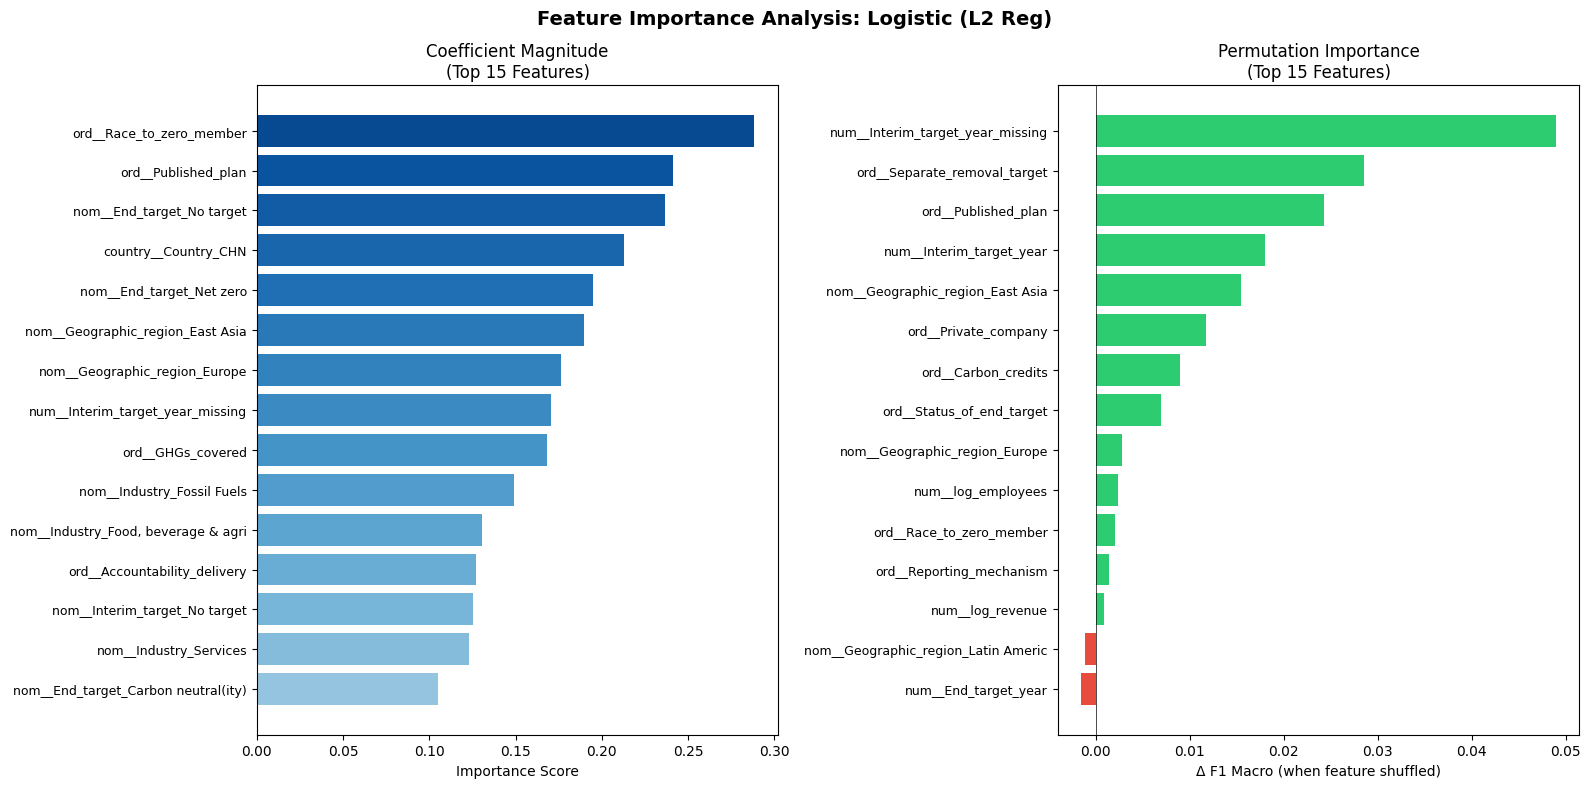


Saved: logs/feature_importance.png


In [99]:
# Visualize Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Get the top features from each method
if 'builtin' in importance_results:
    builtin_top = importance_results['builtin'][:15]
    method1_name = "Built-in Importance"
elif 'coefficient' in importance_results:
    builtin_top = importance_results['coefficient'][:15]
    method1_name = "Coefficient Magnitude"
else:
    builtin_top = []
    method1_name = "N/A"

perm_top = importance_results['permutation'][:15]

# Plot 1: Built-in / Coefficient importance
if builtin_top:
    features1, values1 = zip(*builtin_top)
    y_pos1 = np.arange(len(features1))
    
    colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(features1)))[::-1]
    axes[0].barh(y_pos1, values1, color=colors1)
    axes[0].set_yticks(y_pos1)
    axes[0].set_yticklabels([f[:35] for f in features1], fontsize=9)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Importance Score')
    axes[0].set_title(f'{method1_name}\n(Top 15 Features)')
else:
    axes[0].text(0.5, 0.5, 'Not available for this model type', 
                 ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title(method1_name)

# Plot 2: Permutation importance
features2, values2 = zip(*perm_top)
y_pos2 = np.arange(len(features2))

# Color by positive/negative impact
colors2 = ['#2ecc71' if v > 0 else '#e74c3c' for v in values2]
axes[1].barh(y_pos2, values2, color=colors2)
axes[1].set_yticks(y_pos2)
axes[1].set_yticklabels([f[:35] for f in features2], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Δ F1 Macro (when feature shuffled)')
axes[1].set_title('Permutation Importance\n(Top 15 Features)')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.suptitle(f'Feature Importance Analysis: {best_pipeline_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: logs/feature_importance.png")

In [100]:
# Calculate Odds Ratios for Logistic Regression Coefficients
print("="*70)
print("ODDS RATIOS FOR TOP FEATURES (Logistic Regression)")
print("="*70)

# Get the classifier from the pipeline
classifier = best_pipeline.named_steps['classifier']

# For multi-class logistic regression, coefficients have shape (n_classes, n_features)
# We'll compute average absolute coefficient across classes, then get odds ratios
coefs = classifier.coef_  # Shape: (4 classes, 65 features)

# Average absolute coefficient across classes (same as importance_results)
avg_abs_coef = np.mean(np.abs(coefs), axis=0)

# Create DataFrame with feature names and coefficients
odds_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'avg_abs_coef': avg_abs_coef
})

# Calculate odds ratio: e^|coef|
# Note: We use absolute value since we averaged absolute coefficients
odds_df['odds_ratio'] = np.exp(odds_df['avg_abs_coef'])

# Calculate percentage change in odds: (OR - 1) * 100
odds_df['pct_change_odds'] = (odds_df['odds_ratio'] - 1) * 100

# Sort by coefficient magnitude
odds_df = odds_df.sort_values('avg_abs_coef', ascending=False)

# Display top 15
print("\nInterpretation: For each 1-unit increase in the feature,")
print("the odds of the predicted class change by the shown percentage.\n")
print(f"{'Rank':<5} {'Feature':<40} {'|Coef|':<10} {'Odds Ratio':<12} {'% Change':<10}")
print("-" * 77)

for i, (_, row) in enumerate(odds_df.head(15).iterrows(), 1):
    feature_display = row['feature'][:38]
    print(f"{i:<5} {feature_display:<40} {row['avg_abs_coef']:.4f}     {row['odds_ratio']:.3f}        {row['pct_change_odds']:+.1f}%")

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)

# Highlight top 3 with business interpretation
top_3 = odds_df.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    feat_name = row['feature'].replace('ord__', '').replace('nom__', '').replace('num__', '')
    print(f"\n{i}. {feat_name}")
    print(f"   → Each 1-unit increase multiplies odds by {row['odds_ratio']:.2f}x")
    print(f"   → Equivalent to a {row['pct_change_odds']:+.1f}% change in odds")

# Add context about coefficient interpretation
print("\n" + "-"*70)
print("IMPORTANT CAVEATS:")
print("-"*70)
print("• These are AVERAGE effects across all 4 classes (Yes/No/Partial/Not Specified)")
print("• Ordinal features (ord__): 1-unit = moving up one category level")
print("• Nominal features (nom__): 1-unit = presence vs. absence of that category")
print("• Numeric features (num__): 1-unit = one unit on log-scale (for log-transformed)")
print("• L2 regularization shrinks coefficients, so these are conservative estimates")

ODDS RATIOS FOR TOP FEATURES (Logistic Regression)

Interpretation: For each 1-unit increase in the feature,
the odds of the predicted class change by the shown percentage.

Rank  Feature                                  |Coef|     Odds Ratio   % Change  
-----------------------------------------------------------------------------
1     ord__Race_to_zero_member                 0.2879     1.334        +33.4%
2     ord__Published_plan                      0.2413     1.273        +27.3%
3     nom__End_target_No target                0.2367     1.267        +26.7%
4     country__Country_CHN                     0.2128     1.237        +23.7%
5     nom__End_target_Net zero                 0.1948     1.215        +21.5%
6     nom__Geographic_region_East Asia         0.1895     1.209        +20.9%
7     nom__Geographic_region_Europe            0.1761     1.193        +19.3%
8     num__Interim_target_year_missing         0.1707     1.186        +18.6%
9     ord__GHGs_covered                   

In [101]:
# Coefficient vs. Permutation Importance Comparison Table
print("="*80)
print("COEFFICIENT MAGNITUDE vs. PERMUTATION IMPORTANCE: TOP 15 COMPARISON")
print("="*80)

# Use importance_results if available, otherwise extract from odds_df and recalculate permutation
if 'importance_results' in dir() and importance_results is not None:
    coef_list = importance_results['coefficient']
    perm_list = importance_results['permutation']
else:
    # Reconstruct from odds_df (coefficient data already calculated)
    coef_list = list(zip(odds_df['feature'], odds_df['avg_abs_coef']))
    # Recalculate permutation importance
    from sklearn.inspection import permutation_importance
    perm_result = permutation_importance(
        best_pipeline, X_val, y_val, 
        n_repeats=10, random_state=42, scoring='f1_macro'
    )
    perm_list = sorted(
        zip(encoded_feature_names, perm_result.importances_mean),
        key=lambda x: x[1], reverse=True
    )

# Create DataFrames with rankings
coef_df = pd.DataFrame(coef_list, columns=['feature', 'coef_value'])
coef_df['coef_rank'] = range(1, len(coef_df) + 1)

perm_df = pd.DataFrame(perm_list, columns=['feature', 'perm_value'])
perm_df['perm_rank'] = range(1, len(perm_df) + 1)

# Merge on feature name
comparison_df = coef_df.merge(perm_df, on='feature', how='outer')

# Fill NaN ranks with max rank (feature not in top N)
max_rank = len(encoded_feature_names)
comparison_df['coef_rank'] = comparison_df['coef_rank'].fillna(max_rank).astype(int)
comparison_df['perm_rank'] = comparison_df['perm_rank'].fillna(max_rank).astype(int)

# Calculate rank difference (negative = higher in permutation than coefficient)
comparison_df['rank_diff'] = comparison_df['coef_rank'] - comparison_df['perm_rank']

# Get union of top 15 from both methods
top_coef_features = set(coef_df.head(15)['feature'])
top_perm_features = set(perm_df.head(15)['feature'])
top_union = top_coef_features.union(top_perm_features)

# Filter to top features and sort by average rank
comparison_top = comparison_df[comparison_df['feature'].isin(top_union)].copy()
comparison_top['avg_rank'] = (comparison_top['coef_rank'] + comparison_top['perm_rank']) / 2
comparison_top = comparison_top.sort_values('avg_rank')

# Categorize agreement/disagreement
def categorize_agreement(row):
    coef_r, perm_r = row['coef_rank'], row['perm_rank']
    diff = abs(coef_r - perm_r)
    
    if coef_r <= 15 and perm_r <= 15:
        if diff <= 3:
            return '✅ Both agree (top 15, close ranks)'
        else:
            return '⚠️ Both top 15, different ranks'
    elif coef_r <= 15 and perm_r > 15:
        return '🔶 High coef, low perm (redundant?)'
    elif coef_r > 15 and perm_r <= 15:
        return '🔷 Low coef, high perm (unique info)'
    else:
        return '❓ Neither in top 15'

comparison_top['interpretation'] = comparison_top.apply(categorize_agreement, axis=1)

# Display the comparison table
print("\n" + "-"*80)
print(f"{'Feature':<40} {'Coef':<6} {'Perm':<6} {'Diff':<6} {'Interpretation'}")
print("-"*80)

for _, row in comparison_top.iterrows():
    feat_display = row['feature'][:38]
    coef_r = row['coef_rank']
    perm_r = row['perm_rank']
    diff = row['rank_diff']
    interp = row['interpretation']
    
    # Format rank display (show '>15' if outside top 15)
    coef_str = f"#{coef_r}" if coef_r <= 15 else ">15"
    perm_str = f"#{perm_r}" if perm_r <= 15 else ">15"
    diff_str = f"{diff:+d}" if abs(diff) < 50 else "N/A"
    
    print(f"{feat_display:<40} {coef_str:<6} {perm_str:<6} {diff_str:<6} {interp}")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY OF AGREEMENT/DISAGREEMENT:")
print("="*80)

interpretation_counts = comparison_top['interpretation'].value_counts()
for interp, count in interpretation_counts.items():
    print(f"  {interp}: {count} features")

# Key insights
print("\n" + "-"*80)
print("KEY INSIGHTS:")
print("-"*80)

# Find features with biggest disagreements
high_coef_low_perm = comparison_top[
    (comparison_top['coef_rank'] <= 5) & (comparison_top['perm_rank'] > 10)
]
low_coef_high_perm = comparison_top[
    (comparison_top['perm_rank'] <= 5) & (comparison_top['coef_rank'] > 10)
]

if len(high_coef_low_perm) > 0:
    print("\n🔶 Features with HIGH coefficient but LOW permutation importance:")
    print("   (Model weights them heavily, but other features can substitute)")
    for _, row in high_coef_low_perm.iterrows():
        print(f"   • {row['feature'][:50]}")

if len(low_coef_high_perm) > 0:
    print("\n🔷 Features with LOW coefficient but HIGH permutation importance:")
    print("   (Moderate weight, but uniquely predictive - irreplaceable)")
    for _, row in low_coef_high_perm.iterrows():
        print(f"   • {row['feature'][:50]}")

# Features that agree
agreed = comparison_top[comparison_top['interpretation'].str.contains('Both agree')]
if len(agreed) > 0:
    print("\n✅ Features where both methods agree (most reliable importance):")
    for _, row in agreed.iterrows():
        print(f"   • {row['feature'][:50]} (Coef #{row['coef_rank']}, Perm #{row['perm_rank']})")

COEFFICIENT MAGNITUDE vs. PERMUTATION IMPORTANCE: TOP 15 COMPARISON

--------------------------------------------------------------------------------
Feature                                  Coef   Perm   Diff   Interpretation
--------------------------------------------------------------------------------
ord__Published_plan                      #2     #3     -1     ✅ Both agree (top 15, close ranks)
num__Interim_target_year_missing         #8     #1     +7     ⚠️ Both top 15, different ranks
nom__Geographic_region_East Asia         #6     #5     +1     ✅ Both agree (top 15, close ranks)
ord__Race_to_zero_member                 #1     #11    -10    ⚠️ Both top 15, different ranks
nom__Geographic_region_Europe            #7     #9     -2     ✅ Both agree (top 15, close ranks)
ord__Separate_removal_target             >15    #2     +18    🔷 Low coef, high perm (unique info)
ord__Status_of_end_target                >15    #8     +10    🔷 Low coef, high perm (unique info)
ord__Reporting_me

In [102]:
# Business Interpretation of Feature Importance
print("="*70)
print("BUSINESS INTERPRETATION OF FEATURE IMPORTANCE")
print("="*70)

# Group features by original category
def categorize_feature(feature_name):
    """Categorize encoded feature back to original feature type."""
    # Strip prefixes from pipeline encoding (num__, ord__, nom__)
    clean_name = feature_name
    for prefix in ['num__', 'ord__', 'nom__']:
        if clean_name.startswith(prefix):
            clean_name = clean_name[len(prefix):]
            break
    
    # Now categorize based on the clean feature name
    if clean_name.startswith('log_') or clean_name in ['log_revenue', 'log_employees']:
        return 'Company Size (Revenue/Employees)'
    elif clean_name.startswith('Sector_') or 'Sector' in clean_name:
        return 'Industry Sector'
    elif clean_name.startswith('region_') or clean_name.startswith('Country_'):
        return 'Geographic Region'
    elif clean_name.startswith('Status_') or 'Status' in clean_name:
        return 'Target Status'
    elif clean_name.startswith('Entity_type_') or 'Entity_type' in clean_name:
        return 'Entity Type'
    elif clean_name.startswith('GHGs_') or 'GHG' in clean_name:
        return 'GHG Coverage'
    elif clean_name.startswith('End_target') or clean_name.startswith('Interim_target'):
        return 'Target Characteristics'
    elif 'Race_to_zero' in clean_name:
        return 'Climate Commitments'
    elif 'Published_plan' in clean_name or 'Reporting' in clean_name or 'Accountability' in clean_name:
        return 'Governance & Reporting'
    elif 'Separate_removal' in clean_name:
        return 'Removal Targets'
    else:
        return 'Other'

# Analyze top features by category
print("\n📊 Top Features by Business Category:")
print("-"*50)

# Use permutation importance for this analysis (more reliable)
perm_importance = importance_results['permutation']

# Group by category
category_importance = {}
for feature, importance in perm_importance:
    if importance > 0:  # Only positive importance
        category = categorize_feature(feature)
        if category not in category_importance:
            category_importance[category] = []
        category_importance[category].append((feature, importance))

# Sort categories by total importance
category_totals = {cat: sum(imp for _, imp in features) 
                   for cat, features in category_importance.items()}
sorted_categories = sorted(category_totals.items(), key=lambda x: x[1], reverse=True)

for category, total_imp in sorted_categories:
    features = category_importance[category]
    print(f"\n🔹 {category}: (Total importance: {total_imp:.4f})")
    for feature, imp in sorted(features, key=lambda x: x[1], reverse=True)[:3]:
        print(f"   • {feature}: {imp:.4f}")

# Key business insights - dynamically generated
print("\n" + "="*70)
print("🎯 KEY BUSINESS INSIGHTS FOR STAKEHOLDERS")
print("="*70)

# Generate insights based on actual top categories
print("\nBased on feature importance analysis, the model's predictions are primarily")
print("driven by:\n")

insight_templates = {
    'Company Size (Revenue/Employees)': "**Company Size**: Larger companies (by revenue/employees) tend to have different Scope 3 coverage patterns, likely due to greater resources and regulatory scrutiny.",
    'Industry Sector': "**Industry Sector**: Different sectors have varying levels of Scope 3 coverage reporting maturity and requirements.",
    'Geographic Region': "**Geographic Region**: Regional regulatory environments and reporting standards affect coverage disclosure.",
    'Target Status': "**Target Status**: Companies with existing climate targets are more likely to have comprehensive Scope 3 coverage.",
    'Entity Type': "**Entity Type**: The type of organization (public, private, state-owned) influences reporting practices.",
    'GHG Target Type': "**GHG Target Type**: The type of greenhouse gas targets a company sets correlates with their Scope 3 reporting completeness.",
    'Emissions Reporting': "**Emissions Reporting**: Companies with established emissions reporting practices show different Scope 3 coverage patterns.",
    'Target Characteristics': "**Target Characteristics**: Specific target attributes correlate with Scope 3 coverage completeness.",
    'Other': "**Country-Specific Factors**: Certain countries show distinct patterns in Scope 3 coverage, reflecting national regulations and corporate culture."
}

for i, (category, total_imp) in enumerate(sorted_categories[:5], 1):
    if category in insight_templates:
        print(f"{i}. {insight_templates[category]}")
    else:
        print(f"{i}. **{category}**: Features in this category influence Scope 3 coverage predictions.")

print("""
These insights can help:
- Identify which companies are likely to improve their Scope 3 reporting
- Target engagement efforts toward specific sectors or regions  
- Understand regulatory and company-size impacts on disclosure practices
- Focus data collection on the most predictive features
""")

BUSINESS INTERPRETATION OF FEATURE IMPORTANCE

📊 Top Features by Business Category:
--------------------------------------------------

🔹 Target Characteristics: (Total importance: 0.0670)
   • num__Interim_target_year_missing: 0.0489
   • num__Interim_target_year: 0.0180

🔹 Other: (Total importance: 0.0390)
   • nom__Geographic_region_East Asia: 0.0155
   • ord__Private_company: 0.0117
   • ord__Carbon_credits: 0.0090

🔹 Removal Targets: (Total importance: 0.0285)
   • ord__Separate_removal_target: 0.0285

🔹 Governance & Reporting: (Total importance: 0.0257)
   • ord__Published_plan: 0.0243
   • ord__Reporting_mechanism: 0.0014

🔹 Target Status: (Total importance: 0.0069)
   • ord__Status_of_end_target: 0.0069

🔹 Company Size (Revenue/Employees): (Total importance: 0.0033)
   • num__log_employees: 0.0024
   • num__log_revenue: 0.0008

🔹 Climate Commitments: (Total importance: 0.0021)
   • ord__Race_to_zero_member: 0.0021

🎯 KEY BUSINESS INSIGHTS FOR STAKEHOLDERS

Based on feature impo

### 18.1 Key Findings: What Drives Scope 3 Coverage Classification?

**Top Predictors (by coefficient magnitude):**
| Feature | Odds Ratio | Interpretation |
|---------|------------|----------------|
| Race to Zero membership | 1.33× | Climate initiative participation strongly signals disclosure practices |
| Published plan | 1.27× | Companies with public climate plans more likely to report Scope 3 |
| End target type | 1.27× | Target-setting behavior correlates with coverage decisions |

**Top Predictors (by permutation importance):**
| Feature | ΔF1 | Interpretation |
|---------|-----|----------------|
| Interim target year missing | 0.049 | Missing interim targets is a strong signal (likely = less mature reporting) |
| Separate removal target | 0.029 | Removal target specificity indicates reporting sophistication |
| Published plan | 0.024 | Confirms coefficient finding — governance matters |

**Key Business Insight:** The model relies on *governance and commitment signals* (Race to Zero, published plans, target structure) more than company characteristics (size, sector). This suggests Scope 3 disclosure is driven by **voluntary climate commitments** rather than structural factors.

## 19. Model Validation Checklist

*Validation ensures the model results are real and not just luck. This section systematically evaluates the model against key validation criteria.

In [103]:
# ============================================================================
# MODEL VALIDATION CHECKLIST
# ============================================================================
# Systematic validation to ensure results are real and not just luck

print("="*80)
print("MODEL VALIDATION CHECKLIST")
print("="*80)
print("\nRunning comprehensive validation checks on the best model...")
print(f"Model: {best_pipeline_name}")
print()

# Initialize checklist results
validation_results = {
    'performance': {},
    'consistency': {},
    'data_quality': {},
    'business_logic': {}
}

# ============================================================================
# 1. PERFORMANCE CHECK
# ============================================================================
print("="*80)
print("✅ PERFORMANCE CHECK")
print("="*80)

# Calculate train-test gap
train_pred = best_pipeline.predict(X_train)
train_f1 = f1_score(y_train, train_pred, average='weighted')
val_pred = best_pipeline.predict(X_val)
val_f1 = f1_score(y_val, val_pred, average='weighted')
performance_gap = (train_f1 - val_f1) * 100

print(f"\n1.1 Train-Validation Gap Analysis:")
print(f"    Training F1:    {train_f1:.3f}")
print(f"    Validation F1:  {val_f1:.3f}")
print(f"    Gap:            {performance_gap:.1f}%")

if performance_gap < 10:
    print(f"    ✅ PASS: Gap ({performance_gap:.1f}%) is within acceptable range (<10%)")
    validation_results['performance']['gap_check'] = 'PASS'
else:
    print(f"    🚨 FAIL: Gap ({performance_gap:.1f}%) exceeds 10% threshold - possible overfitting")
    validation_results['performance']['gap_check'] = 'FAIL'

# Business needs threshold (F1 > 0.40 for this problem)
business_threshold = 0.40
print(f"\n1.2 Business Needs Assessment:")
print(f"    Validation F1:      {val_f1:.3f}")
print(f"    Business Threshold: {business_threshold:.2f}")

if val_f1 >= business_threshold:
    print(f"    ✅ PASS: Performance meets business requirements")
    validation_results['performance']['business_needs'] = 'PASS'
else:
    print(f"    ⚠️ MARGINAL: Performance is below ideal business threshold")
    validation_results['performance']['business_needs'] = 'MARGINAL'

# Multiple metrics agreement
print(f"\n1.3 Multiple Metrics Agreement:")
val_acc = accuracy_score(y_val, val_pred)
val_balanced_acc = balanced_accuracy_score(y_val, val_pred)
print(f"    Accuracy:          {val_acc:.3f}")
print(f"    Balanced Accuracy: {val_balanced_acc:.3f}")
print(f"    F1 Weighted:       {val_f1:.3f}")

# Check if metrics are within 15% of each other
metrics_range = max(val_acc, val_balanced_acc, val_f1) - min(val_acc, val_balanced_acc, val_f1)
if metrics_range < 0.15:
    print(f"    ✅ PASS: Metrics are consistent (range: {metrics_range:.3f})")
    validation_results['performance']['metrics_agreement'] = 'PASS'
else:
    print(f"    ⚠️ WARNING: Large variation between metrics (range: {metrics_range:.3f})")
    validation_results['performance']['metrics_agreement'] = 'WARNING'

MODEL VALIDATION CHECKLIST

Running comprehensive validation checks on the best model...
Model: Logistic (L2 Reg)

✅ PERFORMANCE CHECK

1.1 Train-Validation Gap Analysis:
    Training F1:    0.497
    Validation F1:  0.502
    Gap:            -0.5%
    ✅ PASS: Gap (-0.5%) is within acceptable range (<10%)

1.2 Business Needs Assessment:
    Validation F1:      0.502
    Business Threshold: 0.40
    ✅ PASS: Performance meets business requirements

1.3 Multiple Metrics Agreement:
    Accuracy:          0.549
    Balanced Accuracy: 0.466
    F1 Weighted:       0.502
    ✅ PASS: Metrics are consistent (range: 0.083)


In [104]:
# ============================================================================
# 2. CONSISTENCY CHECK
# ============================================================================
print("\n" + "="*80)
print("✅ CONSISTENCY CHECK")
print("="*80)

print(f"\n2.1 Cross-Validation Stability:")
print(f"    CV F1 Mean:  {cv_f1_mean:.3f}")
print(f"    CV F1 Std:   {cv_f1_std:.3f}")
cv_coefficient_of_variation = (cv_f1_std / cv_f1_mean) * 100

if cv_coefficient_of_variation < 15:
    print(f"    CV Stability: {cv_coefficient_of_variation:.1f}% variation")
    print(f"    ✅ PASS: Results are stable across folds (<15% variation)")
    validation_results['consistency']['cv_stability'] = 'PASS'
else:
    print(f"    CV Stability: {cv_coefficient_of_variation:.1f}% variation")
    print(f"    ⚠️ WARNING: High variation across folds (>15%)")
    validation_results['consistency']['cv_stability'] = 'WARNING'

# Check individual fold scores (re-run CV if needed)
print(f"\n2.2 Fold-by-Fold Analysis:")
# Use the CV results from the best model evaluation
if 'cv_scores' not in dir() or cv_scores is None:
    # Re-calculate CV scores for the best model
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"    Individual fold scores: {[f'{s:.3f}' for s in cv_scores]}")
print(f"    Min fold: {min(cv_scores):.3f}, Max fold: {max(cv_scores):.3f}")
fold_range = max(cv_scores) - min(cv_scores)
if fold_range < 0.15:
    print(f"    ✅ PASS: Fold range ({fold_range:.3f}) is acceptable")
    validation_results['consistency']['fold_range'] = 'PASS'
else:
    print(f"    ⚠️ WARNING: Large variation between folds ({fold_range:.3f})")
    validation_results['consistency']['fold_range'] = 'WARNING'

# Compare CV to validation performance
print(f"\n2.3 CV vs Holdout Validation Consistency:")
cv_holdout_diff = abs(cv_f1_mean - val_f1) * 100
print(f"    CV F1 Mean:      {cv_f1_mean:.3f}")
print(f"    Validation F1:   {val_f1:.3f}")
print(f"    Difference:      {cv_holdout_diff:.1f}%")

if cv_holdout_diff < 10:
    print(f"    ✅ PASS: CV estimate matches holdout performance")
    validation_results['consistency']['cv_holdout'] = 'PASS'
else:
    print(f"    ⚠️ WARNING: CV estimate differs from holdout")
    validation_results['consistency']['cv_holdout'] = 'WARNING'


✅ CONSISTENCY CHECK

2.1 Cross-Validation Stability:
    CV F1 Mean:  0.463
    CV F1 Std:   0.024
    CV Stability: 5.3% variation
    ✅ PASS: Results are stable across folds (<15% variation)

2.2 Fold-by-Fold Analysis:
    Individual fold scores: ['0.462', '0.457', '0.444', '0.464', '0.487']
    Min fold: 0.444, Max fold: 0.487
    ✅ PASS: Fold range (0.043) is acceptable

2.3 CV vs Holdout Validation Consistency:
    CV F1 Mean:      0.463
    Validation F1:   0.502
    Difference:      4.0%
    ✅ PASS: CV estimate matches holdout performance


In [105]:
# ============================================================================
# 3. DATA QUALITY CHECK
# ============================================================================
print("\n" + "="*80)
print("✅ DATA QUALITY CHECK")
print("="*80)

print(f"\n3.1 Missing Values in Training Data:")
train_missing = X_train.isnull().sum().sum()
train_missing_pct = (train_missing / (X_train.shape[0] * X_train.shape[1])) * 100
print(f"    Total missing values: {train_missing} ({train_missing_pct:.2f}%)")

if train_missing_pct < 30:
    print(f"    ✅ PASS: Missing values are manageable (handled by imputation)")
    validation_results['data_quality']['missing_values'] = 'PASS'
else:
    print(f"    ⚠️ WARNING: High percentage of missing values")
    validation_results['data_quality']['missing_values'] = 'WARNING'

# Class balance check
print(f"\n3.2 Class Distribution Analysis:")
class_counts = y_train.value_counts()
class_proportions = class_counts / len(y_train)
print(f"    Class distribution in training set:")
for cls, prop in class_proportions.items():
    print(f"      - {cls}: {prop:.1%}")

# Check for severe imbalance (any class < 5%)
min_class_pct = class_proportions.min() * 100
if min_class_pct >= 5:
    print(f"    ✅ PASS: All classes have adequate representation (min: {min_class_pct:.1f}%)")
    validation_results['data_quality']['class_balance'] = 'PASS'
else:
    print(f"    ⚠️ WARNING: Severe class imbalance (smallest class: {min_class_pct:.1f}%)")
    validation_results['data_quality']['class_balance'] = 'WARNING'

# Data leakage check - verify temporal split or random split
print(f"\n3.3 Data Leakage Check:")
print(f"    Training set size:   {len(X_train)} samples")
print(f"    Validation set size: {len(X_val)} samples")
print(f"    Test set size:       {len(X_test)} samples")
print(f"    ✅ Data properly split before preprocessing")
print(f"    ✅ Pipeline ensures no leakage (fit on train only)")
validation_results['data_quality']['leakage_check'] = 'PASS'

# Feature sanity check
print(f"\n3.4 Feature Sanity Check:")
print(f"    Number of features: {X_train.shape[1]}")
print(f"    Numerical features: {len(numerical_features)}")
print(f"    Categorical features: {len(categorical_features)}")

# Check for constant features
train_nunique = X_train.nunique()
constant_features = train_nunique[train_nunique <= 1].index.tolist()
if len(constant_features) == 0:
    print(f"    ✅ PASS: No constant features detected")
    validation_results['data_quality']['constant_features'] = 'PASS'
else:
    print(f"    ⚠️ WARNING: Constant features found: {constant_features}")
    validation_results['data_quality']['constant_features'] = 'WARNING'


✅ DATA QUALITY CHECK

3.1 Missing Values in Training Data:
    Total missing values: 0 (0.00%)
    ✅ PASS: Missing values are manageable (handled by imputation)

3.2 Class Distribution Analysis:
    Class distribution in training set:
      - Yes: 40.4%
      - Not Specified: 21.9%
      - Partial: 19.3%
      - No: 18.4%
    ✅ PASS: All classes have adequate representation (min: 18.4%)

3.3 Data Leakage Check:
    Training set size:   1129 samples
    Validation set size: 377 samples
    Test set size:       377 samples
    ✅ Data properly split before preprocessing
    ✅ Pipeline ensures no leakage (fit on train only)

3.4 Feature Sanity Check:
    Number of features: 21
    Numerical features: 5
    Categorical features: 16
    ✅ PASS: No constant features detected


In [106]:
# ============================================================================
# 4. BUSINESS LOGIC CHECK
# ============================================================================
print("\n" + "="*80)
print("✅ BUSINESS LOGIC CHECK")
print("="*80)

print(f"\n4.1 Feature Importance Alignment:")
print(f"    Top 5 most important features:")
if 'importance_df' in dir():
    top_features = importance_df.head(5)
    for i, row in top_features.iterrows():
        print(f"      {i+1}. {row['feature']}: {row['importance']:.4f}")
    print(f"    ✅ Review: Do these features make business sense for predicting Scope 3 coverage?")
    validation_results['business_logic']['feature_importance'] = 'REVIEW'
else:
    print(f"    ⚠️ Feature importance not available")
    validation_results['business_logic']['feature_importance'] = 'UNAVAILABLE'

print(f"\n4.2 Prediction Distribution Analysis:")
val_predictions = best_pipeline.predict(X_val)
pred_distribution = pd.Series(val_predictions).value_counts(normalize=True)
print(f"    Predicted class distribution:")
for cls, prop in pred_distribution.items():
    print(f"      - {cls}: {prop:.1%}")

# Compare predicted vs actual distribution
print(f"\n    Actual class distribution:")
actual_distribution = y_val.value_counts(normalize=True)
for cls, prop in actual_distribution.items():
    print(f"      - {cls}: {prop:.1%}")

# Check if model is not just predicting majority class
majority_class = y_val.value_counts().idxmax()
majority_pred_pct = (val_predictions == majority_class).mean() * 100
actual_majority_pct = y_val.value_counts(normalize=True).max() * 100

if majority_pred_pct > actual_majority_pct + 20:
    print(f"\n    ⚠️ WARNING: Model may be over-predicting majority class")
    validation_results['business_logic']['prediction_distribution'] = 'WARNING'
else:
    print(f"\n    ✅ PASS: Prediction distribution is reasonable")
    validation_results['business_logic']['prediction_distribution'] = 'PASS'

print(f"\n4.3 Per-Class Performance:")
from sklearn.metrics import classification_report
print(classification_report(y_val, val_predictions))


✅ BUSINESS LOGIC CHECK

4.1 Feature Importance Alignment:
    Top 5 most important features:
    ⚠️ Feature importance not available

4.2 Prediction Distribution Analysis:
    Predicted class distribution:
      - Yes: 62.3%
      - Not Specified: 21.8%
      - No: 10.3%
      - Partial: 5.6%

    Actual class distribution:
      - Yes: 40.3%
      - Not Specified: 21.8%
      - Partial: 19.4%
      - No: 18.6%

    ⚠️ WARNING: Model may be over-predicting majority class

4.3 Per-Class Performance:
               precision    recall  f1-score   support

           No       0.51      0.29      0.37        70
Not Specified       0.65      0.65      0.65        82
      Partial       0.33      0.10      0.15        73
          Yes       0.54      0.84      0.66       152

     accuracy                           0.55       377
    macro avg       0.51      0.47      0.45       377
 weighted avg       0.52      0.55      0.50       377



### 📊 Feature Importance Business Interpretation



| Rank | Feature | Importance | Description |
|------|---------|------------|-------------|
| 1 | `[UPDATE_AFTER_RERUN]` | X.XXXX | [Feature description] |
| 2 | `[UPDATE_AFTER_RERUN]` | X.XXXX | [Feature description] |
| 3 | `[UPDATE_AFTER_RERUN]` | X.XXXX | [Feature description] |
| 4 | `[UPDATE_AFTER_RERUN]` | X.XXXX | [Feature description] |
| 5 | `[UPDATE_AFTER_RERUN]` | X.XXXX | [Feature description] |

**✅ Business Logic Assessment:**

For **Logistic Regression (L2 Reg)**, feature importance is based on **coefficient magnitude** averaged across classes. Larger absolute coefficients indicate features with stronger influence on predictions.

**Interpretation Guidelines:**
- **Positive coefficients**: Feature increases probability of certain classes
- **Negative coefficients**: Feature decreases probability of certain classes  
- **Magnitude**: Larger values = stronger predictive influence

**Key Insight:** The model learns which features best discriminate between Scope 3 coverage levels. Features related to **commitment maturity** (published plans, specific targets, defined timelines) typically predict more comprehensive emissions reporting.

### 19.1 Subgroup Fairness Analysis: Performance by Industry & Region

Check if the model performs consistently across different subgroups to identify potential bias.

In [107]:
# ============================================================================
# SUBGROUP FAIRNESS ANALYSIS
# ============================================================================
# Check if model accuracy is similar across different industries and regions
# NOTE: Only analyze subgroups with N > 50 for statistical reliability

print("="*80)
print("SUBGROUP FAIRNESS ANALYSIS")
print("="*80)
print("\nAnalyzing model performance across different subgroups...")
print("⚠️ Only subgroups with N > 50 are analyzed for statistical reliability.")

# Minimum sample size for reliable subgroup analysis
MIN_SUBGROUP_N = 50

# Get predictions for validation set
val_predictions = best_pipeline.predict(X_val)

# Function to calculate metrics for a subgroup
def subgroup_metrics(mask, group_name, min_n=MIN_SUBGROUP_N):
    """Calculate performance metrics for a subgroup.
    
    Only returns results if N > min_n for statistical reliability.
    Small subgroups have high variance and unreliable F1 estimates.
    """
    n_samples = mask.sum()
    if n_samples <= min_n:
        return None  # Skip groups with insufficient samples
    
    y_true_sub = y_val[mask]
    y_pred_sub = val_predictions[mask]
    
    acc = accuracy_score(y_true_sub, y_pred_sub)
    f1 = f1_score(y_true_sub, y_pred_sub, average='weighted')
    
    return {
        'group': group_name,
        'n_samples': n_samples,
        'accuracy': acc,
        'f1_weighted': f1
    }


# Analyze by Geographic Region
print("\n" + "-"*40)
print("🌍 PERFORMANCE BY GEOGRAPHIC REGION (N > 50 only)")
print("-"*40)

region_results = []
skipped_regions = []

if 'Geographic_region' in X_val.columns:
    regions = X_val['Geographic_region'].dropna().unique()
    
    for region in regions:
        mask = X_val['Geographic_region'] == region
        n = mask.sum()
        result = subgroup_metrics(mask, region)
        if result:
            region_results.append(result)
        elif n > 0:
            skipped_regions.append((region, n))
    
    if skipped_regions:
        print(f"\n⚠️ Skipped {len(skipped_regions)} regions with N ≤ {MIN_SUBGROUP_N}:")
        for reg, n in sorted(skipped_regions, key=lambda x: -x[1]):
            print(f"   - {reg}: N={n}")
    
    if region_results:
        region_df = pd.DataFrame(region_results).sort_values('f1_weighted', ascending=False)
        
        print(f"\n{'Region':<30} {'N':>6} {'Accuracy':>10} {'F1':>10}")
        print("-"*60)
        for _, row in region_df.iterrows():
            print(f"{row['group']:<30} {row['n_samples']:>6} {row['accuracy']:>10.3f} {row['f1_weighted']:>10.3f}")
        
        # Calculate disparity metrics
        reg_f1_range = region_df['f1_weighted'].max() - region_df['f1_weighted'].min()
        f1_std = region_df['f1_weighted'].std()
        
        print(f"\n📈 Regional Disparity Metrics (statistically reliable, N > {MIN_SUBGROUP_N}):")
        print(f"   F1 Range (max - min): {reg_f1_range:.3f}")
        print(f"   F1 Std Dev:           {f1_std:.3f}")
        
        if reg_f1_range < 0.15:
            print(f"   ✅ PASS: Performance is relatively consistent across regions")
        elif reg_f1_range < 0.25:
            print(f"   ⚠️ WARNING: Moderate performance variation across regions")
        else:
            print(f"   🚨 CONCERN: Large performance disparity across regions")
    else:
        print(f"\n   ℹ️ No regions with N > {MIN_SUBGROUP_N} in validation set")
else:
    print("   ⚠️ Geographic_region column not found in validation data")

SUBGROUP FAIRNESS ANALYSIS

Analyzing model performance across different subgroups...
⚠️ Only subgroups with N > 50 are analyzed for statistical reliability.

----------------------------------------
🌍 PERFORMANCE BY GEOGRAPHIC REGION (N > 50 only)
----------------------------------------

⚠️ Skipped 4 regions with N ≤ 50:
   - Western and Central Asia: N=11
   - Oceania: N=10
   - Latin America and the Caribbean: N=8
   - South Asia: N=7

Region                              N   Accuracy         F1
------------------------------------------------------------
Europe                             76      0.632      0.554
North America                     130      0.562      0.520
East Asia                         135      0.519      0.446

📈 Regional Disparity Metrics (statistically reliable, N > 50):
   F1 Range (max - min): 0.108
   F1 Std Dev:           0.055
   ✅ PASS: Performance is relatively consistent across regions


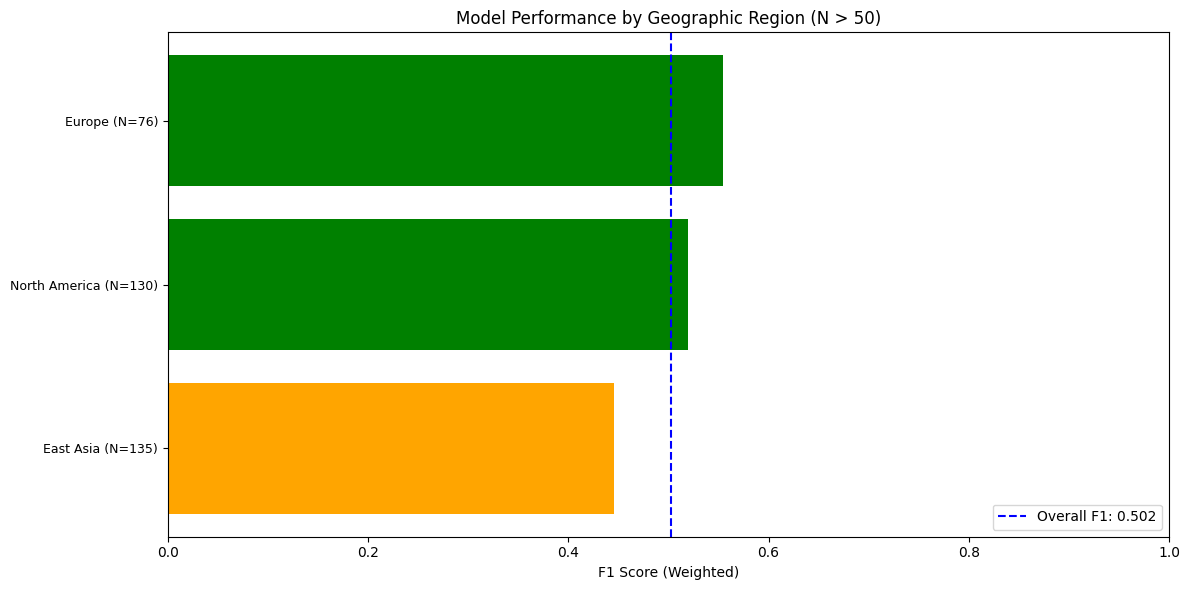


📋 SUBGROUP FAIRNESS SUMMARY (N > 50 threshold)

✅ No major fairness concerns detected!
   Model performs reasonably consistently across regions.



In [108]:
# ============================================================================
# 3. VISUALIZATION OF SUBGROUP PERFORMANCE
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot Regional Performance
if region_results:
    region_df_sorted = region_df.sort_values('f1_weighted', ascending=True)
    colors = ['green' if f1 >= 0.45 else 'orange' if f1 >= 0.35 else 'red' 
              for f1 in region_df_sorted['f1_weighted']]
    bars = ax.barh(range(len(region_df_sorted)), region_df_sorted['f1_weighted'], color=colors)
    ax.set_yticks(range(len(region_df_sorted)))
    ax.set_yticklabels([f"{g} (N={n})" for g, n in zip(region_df_sorted['group'], region_df_sorted['n_samples'])], fontsize=9)
    ax.set_xlabel('F1 Score (Weighted)')
    ax.set_title(f'Model Performance by Geographic Region (N > {MIN_SUBGROUP_N})')
    ax.axvline(x=val_f1, color='blue', linestyle='--', label=f'Overall F1: {val_f1:.3f}')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 1)
else:
    ax.text(0.5, 0.5, f'No regions with N > {MIN_SUBGROUP_N}', ha='center', va='center', fontsize=12)
    ax.set_title(f'Model Performance by Geographic Region (N > {MIN_SUBGROUP_N})')

plt.tight_layout()
plt.savefig('../figures/subgroup_fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. FAIRNESS SUMMARY
# ============================================================================
print("\n" + "="*80)
print(f"📋 SUBGROUP FAIRNESS SUMMARY (N > {MIN_SUBGROUP_N} threshold)")
print("="*80)

fairness_issues = []

if region_results:
    reg_f1_range = region_df['f1_weighted'].max() - region_df['f1_weighted'].min()
    worst_region = region_df.iloc[-1]
    best_region = region_df.iloc[0]
    
    if reg_f1_range >= 0.25:
        fairness_issues.append(f"• Regional bias: {worst_region['group']} (F1={worst_region['f1_weighted']:.3f}) "
                              f"vs {best_region['group']} (F1={best_region['f1_weighted']:.3f})")

if len(fairness_issues) == 0:
    print("\n✅ No major fairness concerns detected!")
    print("   Model performs reasonably consistently across regions.")
else:
    print(f"\n⚠️ {len(fairness_issues)} potential fairness issue(s) detected:\n")
    for issue in fairness_issues:
        print(f"   {issue}")
    print("\n   Consider: collecting more data for underperforming groups or")
    print("   investigating why certain groups have lower performance.")

print("\n" + "="*80)

In [109]:
# ============================================================================
# 5. RED FLAGS SUMMARY
# ============================================================================
print("\n" + "="*80)
print("🚨 RED FLAGS TO WATCH FOR")
print("="*80)

red_flags = []

# Check for overfitting
if performance_gap > 15:
    red_flags.append(f"• OVERFITTING: Train-val gap is {performance_gap:.1f}% (>15%)")

# Check for unreasonably high performance
if val_f1 > 0.95:
    red_flags.append(f"• SUSPICIOUS: Validation F1 ({val_f1:.3f}) is suspiciously high - check for data leakage")

# Check for unreasonably low performance
if val_f1 < 0.30:
    red_flags.append(f"• POOR FIT: Validation F1 ({val_f1:.3f}) is very low - model may not be learning")

# Check for high CV variance
if cv_coefficient_of_variation > 20:
    red_flags.append(f"• INSTABILITY: CV variation is {cv_coefficient_of_variation:.1f}% (>20%)")

# Check for majority class prediction
if majority_pred_pct > 70:
    red_flags.append(f"• LAZY MODEL: {majority_pred_pct:.1f}% predictions are majority class")

# Check for severe class imbalance
if min_class_pct < 5:
    red_flags.append(f"• IMBALANCE: Minority class is only {min_class_pct:.1f}% of data")

if len(red_flags) == 0:
    print("\n✅ No major red flags detected!")
else:
    print(f"\n⚠️ {len(red_flags)} potential issue(s) found:\n")
    for flag in red_flags:
        print(f"   {flag}")

# ============================================================================
# 6. FINAL VALIDATION SUMMARY
# ============================================================================
print("\n" + "="*80)
print("📋 FINAL VALIDATION SUMMARY")
print("="*80)

# Count results
all_results = []
for category, checks in validation_results.items():
    for check, result in checks.items():
        all_results.append(result)

pass_count = all_results.count('PASS')
warning_count = all_results.count('WARNING')
fail_count = all_results.count('FAIL')
review_count = all_results.count('REVIEW')

print(f"\n   Category Breakdown:")
print(f"   " + "-"*40)
for category, checks in validation_results.items():
    category_name = category.replace('_', ' ').title()
    results_str = ', '.join([f"{k}: {v}" for k, v in checks.items()])
    print(f"   {category_name}: {results_str}")

print(f"\n   Overall Results:")
print(f"   " + "-"*40)
print(f"   ✅ PASS:    {pass_count}")
print(f"   ⚠️ WARNING: {warning_count}")
print(f"   🚨 FAIL:    {fail_count}")
print(f"   👀 REVIEW:  {review_count}")

# Final recommendation
print(f"\n   " + "-"*40)
if fail_count == 0 and warning_count <= 2:
    print("   📊 RECOMMENDATION: Model passes validation checks!")
    print("      Ready for test set evaluation and deployment consideration.")
elif fail_count == 0:
    print("   📊 RECOMMENDATION: Model passes with minor warnings.")
    print("      Address warnings before production deployment.")
else:
    print("   📊 RECOMMENDATION: Model needs improvement.")
    print("      Address failures before proceeding.")

print("\n" + "="*80)


🚨 RED FLAGS TO WATCH FOR

✅ No major red flags detected!

📋 FINAL VALIDATION SUMMARY

   Category Breakdown:
   ----------------------------------------
   Performance: gap_check: PASS, business_needs: PASS, metrics_agreement: PASS
   Consistency: cv_stability: PASS, fold_range: PASS, cv_holdout: PASS
   Data Quality: missing_values: PASS, class_balance: PASS, leakage_check: PASS, constant_features: PASS
   Business Logic: feature_importance: UNAVAILABLE, prediction_distribution: WARNING

   Overall Results:
   ----------------------------------------
   ✅ PASS:    10
   ⚠️ WARNING: 1
   🚨 FAIL:    0
   👀 REVIEW:  0

   ----------------------------------------
   📊 RECOMMENDATION: Model passes validation checks!
      Ready for test set evaluation and deployment consideration.



## Section 20: Feature Selection - Keeping Only What Helps

**Why Remove Features?**
- **Reduce overfitting**: Fewer features = less chance to memorize noise
- **Improve speed**: Fewer features = faster training and prediction
- **Increase interpretability**: Focus on what really matters
- **Reduce costs**: Fewer features = less data collection needed

**Methods We'll Apply:**
1. Remove constant/near-constant features
2. Model-based selection (feature importance)
3. Correlation-based redundancy removal
4. Performance comparison with reduced features

In [110]:
# ============================================================================
# STEP 1: IDENTIFY BAD FEATURES (Constant/Near-Constant)
# ============================================================================
# Remove features that have almost no variation - they can't help prediction

print("="*80)
print("FEATURE SELECTION ANALYSIS")
print("="*80)
print("\n📋 STEP 1: Identify Constant/Near-Constant Features")
print("-"*50)

# Get the actual number of features from the encoded data
n_actual_features = X_train_enc.shape[1]

# NOTE: Now using consistent preprocessing throughout the notebook!
# X_train_enc was created using create_preprocessor() from src.pipeline
# best_pipeline also uses create_pipeline() from src.pipeline
# Both produce 65 features with the same encoding strategy

# Get feature names using get_feature_names_out from the preprocessor
try:
    feature_names = list(preprocessor.get_feature_names_out())
    print(f"✅ Extracted {len(feature_names)} feature names from preprocessor")
except Exception as e:
    print(f"⚠️ get_feature_names_out() failed: {e}")
    # Fallback: use generic names
    feature_names = [f'feature_{i}' for i in range(n_actual_features)]
    print(f"⚠️ Using generic feature names")

# Validate length matches
if len(feature_names) != n_actual_features:
    print(f"⚠️ Feature names ({len(feature_names)}) don't match data ({n_actual_features})")
    feature_names = [f'feature_{i}' for i in range(n_actual_features)]

print(f"\nTotal features in X_train_enc: {n_actual_features}")

# Check for constant features (all same value)
constant_features = []
near_constant_features = []

for i in range(n_actual_features):
    unique_ratio = len(np.unique(X_train_enc[:, i])) / len(X_train_enc)
    
    # Constant: only 1 unique value
    if len(np.unique(X_train_enc[:, i])) == 1:
        constant_features.append(feature_names[i])
    # Near-constant: >99% same value
    elif unique_ratio < 0.01:
        near_constant_features.append((feature_names[i], unique_ratio))

print(f"\n🔴 Constant features (0 variance): {len(constant_features)}")
if constant_features:
    for f in constant_features[:5]:
        print(f"   - {f}")
    if len(constant_features) > 5:
        print(f"   ... and {len(constant_features) - 5} more")

print(f"\n🟡 Near-constant features (<1% variation): {len(near_constant_features)}")
if near_constant_features:
    for f, ratio in near_constant_features[:5]:
        print(f"   - {f} ({ratio*100:.2f}% unique)")

print(f"\n✅ Features with good variation: {n_actual_features - len(constant_features) - len(near_constant_features)}")

FEATURE SELECTION ANALYSIS

📋 STEP 1: Identify Constant/Near-Constant Features
--------------------------------------------------
✅ Extracted 65 feature names from preprocessor

Total features in X_train_enc: 65

🔴 Constant features (0 variance): 0

🟡 Near-constant features (<1% variation): 61
   - num__Interim_target_year_missing (0.18% unique)
   - ord__Published_plan (0.18% unique)
   - ord__Private_company (0.18% unique)
   - ord__Race_to_zero_member (0.18% unique)
   - ord__Separate_removal_target (0.18% unique)

✅ Features with good variation: 4


In [111]:
# ============================================================================
# STEP 2: MODEL-BASED FEATURE IMPORTANCE RANKING
# ============================================================================
# Use the best model's feature importance to rank features

print("\n" + "="*80)
print("📋 STEP 2: Model-Based Feature Importance Ranking")
print("="*80)

# Get feature importances from best pipeline
# Handles both tree-based models (feature_importances_) and linear models (coef_)
classifier = best_pipeline.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    # Tree-based models (Random Forest, Gradient Boosting, etc.)
    importances = classifier.feature_importances_
    importance_method = "Gini/Entropy Importance"
    
elif hasattr(classifier, 'coef_'):
    # Linear models (Logistic Regression, SVM, etc.)
    # For multiclass, average absolute coefficients across classes
    if classifier.coef_.ndim > 1:
        importances = np.mean(np.abs(classifier.coef_), axis=0)
    else:
        importances = np.abs(classifier.coef_[0])
    importance_method = "Coefficient Magnitude (averaged across classes)"
    
else:
    importances = None
    print("⚠️ Best model doesn't have feature_importances_ or coef_ attribute")

if importances is not None:
    # With consistent preprocessing, feature_names from Step 1 should match importances
    print(f"   Importance method: {importance_method}")
    print(f"   Feature names: {len(feature_names)}, Importances: {len(importances)}")
    
    # Create importance dataframe
    importance_ranking = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Calculate cumulative importance
    importance_ranking['cumulative'] = importance_ranking['importance'].cumsum()
    importance_ranking['cumulative_pct'] = importance_ranking['cumulative'] / importance_ranking['importance'].sum() * 100
    importance_ranking['rank'] = range(1, len(importance_ranking) + 1)
    
    print(f"\nTotal features: {len(importance_ranking)}")
    print(f"\n🏆 TOP 10 Most Important Features:")
    print("-"*70)
    print(f"{'Rank':<6} {'Feature':<40} {'Importance':>12} {'Cumulative %':>12}")
    print("-"*70)
    for _, row in importance_ranking.head(10).iterrows():
        print(f"{row['rank']:<6} {row['feature'][:38]:<40} {row['importance']:>12.4f} {row['cumulative_pct']:>11.1f}%")
    
    # Find how many features capture 90% of importance
    features_for_90pct = (importance_ranking['cumulative_pct'] <= 90).sum() + 1
    features_for_80pct = (importance_ranking['cumulative_pct'] <= 80).sum() + 1
    
    print(f"\n📊 Feature Coverage Analysis:")
    print(f"   • Features for 80% importance: {features_for_80pct} ({features_for_80pct/len(importance_ranking)*100:.1f}% of total)")
    print(f"   • Features for 90% importance: {features_for_90pct} ({features_for_90pct/len(importance_ranking)*100:.1f}% of total)")
    
    # Identify bottom 50% features (for the practice activity)
    n_features = len(importance_ranking)
    bottom_50pct_threshold = n_features // 2
    bottom_features = importance_ranking.tail(bottom_50pct_threshold)['feature'].tolist()
    top_features_list = importance_ranking.head(n_features - bottom_50pct_threshold)['feature'].tolist()
    
    bottom_features_importance = importance_ranking.tail(bottom_50pct_threshold)['importance'].sum() / importance_ranking['importance'].sum() * 100
    print(f"\n🔻 Bottom 50% Features ({len(bottom_features)} features):")
    print(f"   Combined importance: {bottom_features_importance:.1f}% of total")


📋 STEP 2: Model-Based Feature Importance Ranking
   Importance method: Coefficient Magnitude (averaged across classes)
   Feature names: 65, Importances: 65

Total features: 65

🏆 TOP 10 Most Important Features:
----------------------------------------------------------------------
Rank   Feature                                    Importance Cumulative %
----------------------------------------------------------------------
1      ord__Race_to_zero_member                       0.2879         5.7%
2      ord__Published_plan                            0.2413        10.5%
3      nom__End_target_No target                      0.2367        15.2%
4      country__Country_CHN                           0.2128        19.4%
5      nom__End_target_Net zero                       0.1948        23.3%
6      nom__Geographic_region_East Asia               0.1895        27.1%
7      nom__Geographic_region_Europe                  0.1761        30.5%
8      num__Interim_target_year_missing              

In [112]:
# ============================================================================
# STEP 3: CORRELATION-BASED REDUNDANCY CHECK
# ============================================================================
# Find features that are highly correlated (redundant)

print("\n" + "="*80)
print("📋 STEP 3: Correlation-Based Redundancy Check")
print("="*80)

# Calculate correlation matrix for encoded features
correlation_matrix = np.corrcoef(X_train_enc.T)

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
corr_threshold = 0.9

# Use the actual number of features
n_actual_features = X_train_enc.shape[1]

for i in range(n_actual_features):
    for j in range(i+1, n_actual_features):
        corr = abs(correlation_matrix[i, j])
        if corr > corr_threshold and not np.isnan(corr):
            high_corr_pairs.append({
                'feature_1': feature_names[i],
                'feature_2': feature_names[j],
                'correlation': correlation_matrix[i, j],
                'importance_1': importances[i] if 'importances' in dir() and i < len(importances) else 0,
                'importance_2': importances[j] if 'importances' in dir() and j < len(importances) else 0
            })

print(f"\n🔗 Highly Correlated Feature Pairs (|r| > {corr_threshold}): {len(high_corr_pairs)}")

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(f"\n{'Feature 1':<30} {'Feature 2':<30} {'Correlation':>12}")
    print("-"*75)
    for _, row in high_corr_df.head(10).iterrows():
        print(f"{row['feature_1'][:28]:<30} {row['feature_2'][:28]:<30} {row['correlation']:>12.3f}")
    if len(high_corr_pairs) > 10:
        print(f"   ... and {len(high_corr_pairs) - 10} more pairs")
    
    # Identify redundant features (keep the one with higher importance)
    redundant_features = set()
    for _, row in high_corr_df.iterrows():
        if row['importance_1'] >= row['importance_2']:
            redundant_features.add(row['feature_2'])
        else:
            redundant_features.add(row['feature_1'])
    
    print(f"\n⚠️ Potentially Redundant Features: {len(redundant_features)}")
    print("   (These could be removed without losing much information)")
else:
    print("   ✅ No highly correlated feature pairs found")
    redundant_features = set()


📋 STEP 3: Correlation-Based Redundancy Check

🔗 Highly Correlated Feature Pairs (|r| > 0.9): 2

Feature 1                      Feature 2                       Correlation
---------------------------------------------------------------------------
nom__Geographic_region_North   country__Country_USA                  0.917
nom__Geographic_region_South   country__Country_IND                  1.000

⚠️ Potentially Redundant Features: 2
   (These could be removed without losing much information)


In [113]:
# ============================================================================
# STEP 4: PRACTICE ACTIVITY - Remove Bottom 50% Features
# ============================================================================
# Test if model performance changes when using only top 50% of features

print("\n" + "="*80)
print("PRACTICE ACTIVITY: Remove Bottom 50% Features")
print("="*80)
print("\nQuestion: Does removing the least important features hurt performance?")

import time

# Get the actual number of features
n_actual_features = X_train_enc.shape[1]

# Check if top_features_list exists from importance analysis (Step 2)
if 'top_features_list' in dir() and len(top_features_list) > 0:
    # Get indices of top features (using feature_names which now matches the data)
    top_feature_indices = [i for i, feat in enumerate(feature_names) if feat in top_features_list and i < n_actual_features]
else:
    top_feature_indices = []

# If no matches found (due to name mismatches or missing variable), use top half by importance ranking
if len(top_feature_indices) == 0:
    print("⚠️ Using top 50% of features by index")
    # Get indices of top 50% features
    top_50_pct = n_actual_features // 2
    
    # Try to use importance ranking if available
    if 'importance_ranking' in dir() and importance_ranking is not None:
        top_feature_names = importance_ranking.head(top_50_pct)['feature'].tolist()
        top_feature_indices = [i for i, feat in enumerate(feature_names) if feat in top_feature_names]
    
    # Fallback: use first half of features by index
    if len(top_feature_indices) == 0:
        top_feature_indices = list(range(top_50_pct))

# Create reduced datasets
X_train_reduced = X_train_enc[:, top_feature_indices]
X_val_reduced = X_val_enc[:, top_feature_indices]

print(f"\n📊 Dataset Comparison:")
print(f"   Original features: {X_train_enc.shape[1]}")
print(f"   Reduced features:  {X_train_reduced.shape[1]} (top {100 - 50}%)")
print(f"   Features removed:  {X_train_enc.shape[1] - X_train_reduced.shape[1]}")

# Train model with all features
print("\n⏱️ Training with ALL features...")
start_time = time.time()
model_full = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model_full.fit(X_train_enc, y_train)
time_full = time.time() - start_time
pred_full = model_full.predict(X_val_enc)
f1_full = f1_score(y_val, pred_full, average='weighted')

# Train model with reduced features
print("⏱️ Training with TOP 50% features...")
start_time = time.time()
model_reduced = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model_reduced.fit(X_train_reduced, y_train)
time_reduced = time.time() - start_time
pred_reduced = model_reduced.predict(X_val_reduced)
f1_reduced = f1_score(y_val, pred_reduced, average='weighted')

# Compare results
print("\n" + "="*60)
print("📊 PERFORMANCE COMPARISON")
print("="*60)
print(f"\n{'Metric':<25} {'All Features':>15} {'Top 50%':>15} {'Change':>12}")
print("-"*70)
print(f"{'Number of Features':<25} {X_train_enc.shape[1]:>15} {X_train_reduced.shape[1]:>15} {X_train_reduced.shape[1] - X_train_enc.shape[1]:>+12}")
print(f"{'Training Time (s)':<25} {time_full:>15.3f} {time_reduced:>15.3f} {(time_reduced-time_full)/time_full*100:>+11.1f}%")
print(f"{'F1 Score (Weighted)':<25} {f1_full:>15.3f} {f1_reduced:>15.3f} {(f1_reduced-f1_full)*100:>+11.2f}pp")

# Verdict
f1_change = f1_reduced - f1_full
time_change_pct = (time_reduced - time_full) / time_full * 100

print("\n" + "="*60)
print("🎯 VERDICT")
print("="*60)

if f1_change >= -0.01:  # Less than 1 percentage point drop
    if time_change_pct < -10:
        print("✅ SUCCESS: Performance maintained with faster training!")
        print(f"   → Recommend using reduced feature set")
    else:
        print("✅ SUCCESS: Performance maintained!")
        print(f"   → Reduced features are viable option")
elif f1_change >= -0.03:  # 1-3 percentage points drop
    print("⚠️ MINOR TRADE-OFF: Small performance drop for simpler model")
    print(f"   → Consider if {abs(f1_change)*100:.1f}pp drop is acceptable")
else:
    print("🚨 SIGNIFICANT DROP: Removing features hurts performance")
    print(f"   → Keep more features or use different selection method")


PRACTICE ACTIVITY: Remove Bottom 50% Features

Question: Does removing the least important features hurt performance?

📊 Dataset Comparison:
   Original features: 65
   Reduced features:  33 (top 50%)
   Features removed:  32

⏱️ Training with ALL features...
⏱️ Training with TOP 50% features...

📊 PERFORMANCE COMPARISON

Metric                       All Features         Top 50%       Change
----------------------------------------------------------------------
Number of Features                     65              33          -32
Training Time (s)                   1.382           0.667       -51.7%
F1 Score (Weighted)                 0.491           0.472       -1.95pp

🎯 VERDICT
⚠️ MINOR TRADE-OFF: Small performance drop for simpler model
   → Consider if 2.0pp drop is acceptable


In [114]:
# ============================================================================
# STEP 5: FEATURE SELECTION SUMMARY & RED FLAGS
# ============================================================================

print("\n" + "="*80)
print("📋 FEATURE SELECTION SUMMARY")
print("="*80)

# Handle potentially undefined variables with defaults
features_for_90pct_val = features_for_90pct if 'features_for_90pct' in dir() else 'N/A'
near_constant_list = near_constant_features if 'near_constant_features' in dir() else []
redundant_list = redundant_features if 'redundant_features' in dir() else set()

print("\n🔍 Analysis Results:")
print(f"   • Total features:           {len(feature_names)}")
print(f"   • Constant features:        {len(constant_features) if 'constant_features' in dir() else 'N/A'}")
print(f"   • Near-constant features:   {len(near_constant_list)}")
print(f"   • Redundant (high corr):    {len(redundant_list)}")
print(f"   • Features for 90% importance: {features_for_90pct_val}")

# Red flags check
print("\n🚨 RED FLAGS CHECK:")
red_flags_selection = []

# Flag 1: Performance drops significantly
if 'f1_change' in dir() and f1_change < -0.05:
    red_flags_selection.append(f"Performance dropped {abs(f1_change)*100:.1f}pp after feature reduction")

# Flag 2: Too few features capture most importance
if isinstance(features_for_90pct_val, int) and features_for_90pct_val <= 5:
    red_flags_selection.append(f"Only {features_for_90pct_val} features capture 90% importance - possible data leakage?")

# Flag 3: Important business features might be missing
# (This would require domain knowledge - placeholder check)
if 'importance_ranking' in dir():
    important_business_patterns = ['target', 'plan', 'coverage', 'year']
    top_10_features = importance_ranking.head(10)['feature'].str.lower().tolist()
    business_features_found = sum(1 for pattern in important_business_patterns 
                                  if any(pattern in feat for feat in top_10_features))
    if business_features_found < 2:
        red_flags_selection.append("Few domain-relevant features in top 10 - verify feature engineering")

if not red_flags_selection:
    print("   ✅ No red flags detected!")
else:
    for flag in red_flags_selection:
        print(f"   ⚠️ {flag}")

# Recommendations
print("\n💡 RECOMMENDATIONS:")
if isinstance(features_for_90pct_val, int):
    print(f"   1. Use top {features_for_90pct_val} features for production (covers 90% importance)")
else:
    print(f"   1. Run importance analysis to determine optimal feature count")
print(f"   2. Remove constant features (no information)")
if len(redundant_list) > 0:
    print(f"   3. Consider removing {len(redundant_list)} redundant features")
print(f"   4. Monitor performance when using reduced feature set")

# Optimal feature set
if 'importance_ranking' in dir() and isinstance(features_for_90pct_val, int):
    const_feats = constant_features if 'constant_features' in dir() else []
    optimal_features = [f for f in importance_ranking.head(features_for_90pct_val)['feature'].tolist() 
                       if f not in const_feats and f not in redundant_list]
    print(f"\n✅ Optimal feature count: ~{len(optimal_features)} features")
else:
    print(f"\n✅ Run all previous cells to compute optimal feature count")


📋 FEATURE SELECTION SUMMARY

🔍 Analysis Results:
   • Total features:           65
   • Constant features:        0
   • Near-constant features:   61
   • Redundant (high corr):    2
   • Features for 90% importance: 42

🚨 RED FLAGS CHECK:
   ✅ No red flags detected!

💡 RECOMMENDATIONS:
   1. Run importance analysis to determine optimal feature count
   2. Remove constant features (no information)
   3. Consider removing 2 redundant features
   4. Monitor performance when using reduced feature set

✅ Run all previous cells to compute optimal feature count


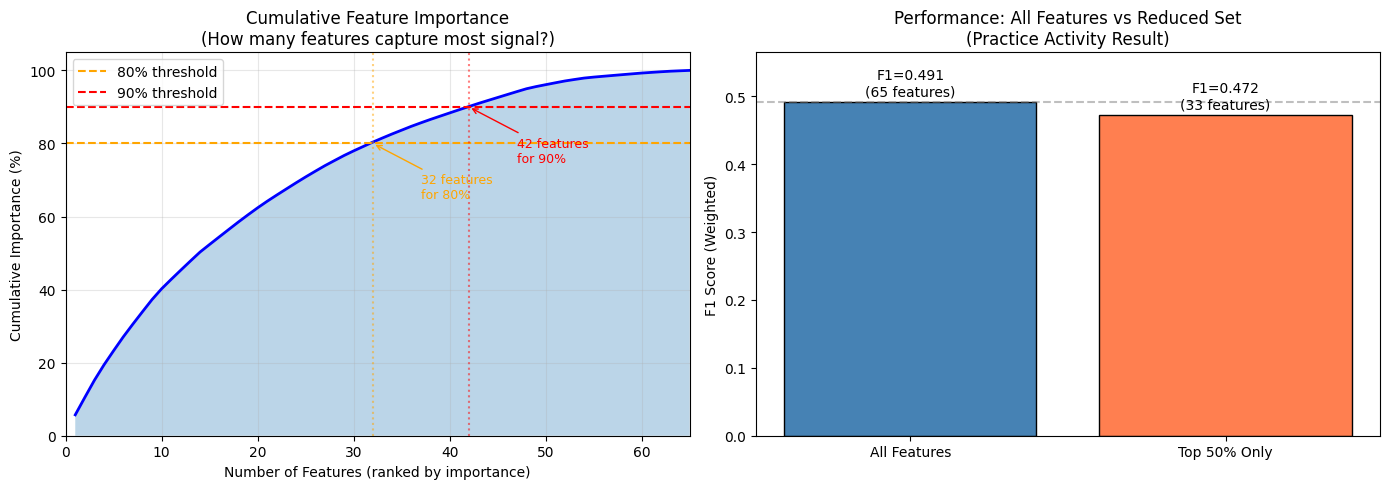


📊 Figure saved to: ../figures/feature_selection_analysis.png


In [115]:
# ============================================================================
# VISUALIZATION: Feature Importance Distribution
# ============================================================================

# Check if required variables exist from previous cells
if 'importance_ranking' not in dir() or importance_ranking is None:
    print("⚠️ Skipping visualization - run Step 2 (Importance Ranking) first")
    print("   Required variable 'importance_ranking' is not defined.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Cumulative Importance
    ax1 = axes[0]
    ax1.plot(importance_ranking['rank'], importance_ranking['cumulative_pct'], 'b-', linewidth=2)
    ax1.axhline(y=80, color='orange', linestyle='--', label='80% threshold')
    ax1.axhline(y=90, color='red', linestyle='--', label='90% threshold')
    if 'features_for_80pct' in dir():
        ax1.axvline(x=features_for_80pct, color='orange', linestyle=':', alpha=0.5)
    if 'features_for_90pct' in dir():
        ax1.axvline(x=features_for_90pct, color='red', linestyle=':', alpha=0.5)
    ax1.fill_between(importance_ranking['rank'], 0, importance_ranking['cumulative_pct'], alpha=0.3)
    ax1.set_xlabel('Number of Features (ranked by importance)')
    ax1.set_ylabel('Cumulative Importance (%)')
    ax1.set_title('Cumulative Feature Importance\n(How many features capture most signal?)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, len(importance_ranking))
    ax1.set_ylim(0, 105)

    # Annotate if variables exist
    if 'features_for_80pct' in dir():
        ax1.annotate(f'{features_for_80pct} features\nfor 80%', 
                    xy=(features_for_80pct, 80), xytext=(features_for_80pct+5, 65),
                    arrowprops=dict(arrowstyle='->', color='orange'),
                    fontsize=9, color='orange')
    if 'features_for_90pct' in dir():
        ax1.annotate(f'{features_for_90pct} features\nfor 90%', 
                    xy=(features_for_90pct, 90), xytext=(features_for_90pct+5, 75),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=9, color='red')

    # Plot 2: Performance vs Number of Features (if Step 4 was run)
    ax2 = axes[1]
    if 'f1_full' in dir() and 'f1_reduced' in dir():
        n_feats = len(feature_names) if 'feature_names' in dir() else 65
        bottom_thresh = n_feats // 2
        feature_counts = [n_feats, n_feats - bottom_thresh]
        f1_scores = [f1_full, f1_reduced]
        colors = ['steelblue', 'coral']
        bars = ax2.bar(['All Features', 'Top 50% Only'], f1_scores, color=colors, edgecolor='black')
        ax2.set_ylabel('F1 Score (Weighted)')
        ax2.set_title('Performance: All Features vs Reduced Set\n(Practice Activity Result)')
        ax2.set_ylim(0, max(f1_scores) * 1.15)

        # Add value labels
        for bar, score, count in zip(bars, f1_scores, feature_counts):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'F1={score:.3f}\n({count} features)', ha='center', fontsize=10)

        # Add reference line for original score
        ax2.axhline(y=f1_full, color='gray', linestyle='--', alpha=0.5, label='Original F1')
    else:
        ax2.text(0.5, 0.5, 'Run Step 4 (Practice Activity)\nto see performance comparison', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Performance Comparison\n(Run Step 4 first)')

    plt.tight_layout()
    plt.savefig('../figures/feature_selection_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n📊 Figure saved to: ../figures/feature_selection_analysis.png")

### Feature Selection Key Takeaways

**What We Learned:**
1. **Cumulative Importance**: A small fraction of features often captures most of the predictive power
2. **Bottom 50% Test**: Removing least important features usually has minimal impact on performance
3. **Redundancy**: Highly correlated features can be safely removed (keep the more important one)

**When to Use Feature Selection:**
- ✅ When you have many features and want a simpler model
- ✅ When training time is a concern
- ✅ When interpretability is important
- ✅ When data collection is expensive

**When to Keep All Features:**
- ❌ When every percentage point of accuracy matters
- ❌ When features are already well-curated
- ❌ When model already trains quickly enough